<a href="https://colab.research.google.com/github/SergeiVKalinin/camm_hackathon/blob/k4my4r/docs/day_19_02102026/Day_19_Higher_Dimensional_Optical_Data_Hackathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="red">**Higher-Dimensional Optical Data Visualization Challenge**</font>

## Composition → spectrum → measurement context

### The problem

Optical libraries are difficult to visualize because every sample has a composition,
a full spectrum, a measurement geometry, and sometimes an elapsed-time history. A
collection of separate plots makes comparisons slow, but forcing everything into one
crowded plot can hide the spectral evidence.

> **Can we make all of those variables easier to explore without hiding the spectra
> or compressing the experiment into a single unexplained score?**

### The approach

Like the example EELS hackathon notebook, this notebook follows one linear pattern:

1. inspect the data and its dimensions;
2. run one complete, deliberately simple worked example;
3. modify that baseline in a clearly marked challenge cell;
4. test whether a new user can answer the stated scientific question.

### Choose one challenge

1. **Challenge 1 — Quaternary System:** connect FA/Cs/Rb/DMA composition and I/Br variation to
   Top PL, Bottom PL, and absorbance.
2. **Challenge 2 — RP-Additive System:** connect 3AMP/FAPbI3 host composition and nominal MACl
   level to Top/Bottom PL over 0–380 minutes.

### Your final result

- one visualization that answers a specific scientific question;
- the full spectral evidence remains reachable or visible;
- one sentence explaining what became easier to see and one possible misinterpretation.

The worked examples are deliberately simple baselines not
the expected final answer.


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kbarakati/athena_camm_hackathon/blob/k4my4r/docs/day_19_02102026/Higher_Dimensional_Optical_Data_Hackathon.ipynb)

<h2><font color="purple">1.</font> Download and Load the Data</h2>

Run the next cells from top to bottom. One public Google Drive folder contains both
challenge folders. The download cell is safe to rerun: it reuses a verified local copy
and only downloads again when files are missing or changed.


In [1]:
# @title 1. Install and import the small analysis stack
%pip -q install "gdown==6.4.1" "pyarrow>=14" "plotly>=5.22"

from html import escape
from pathlib import Path
import hashlib
import shutil
import sys

import gdown
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from IPython.display import FileLink, HTML, Markdown, display


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.8/50.8 kB 2.0 MB/s eta 0:00:00


In [2]:
# @title 2. Download both challenge folders from Google Drive
DRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/16YfPjFdZHgW3hkC0QBLrCS9um2C6aK5q?usp=drive_link"
IN_COLAB = "google.colab" in sys.modules
DATA_ROOT = Path(
    "/content/higher_dimensional_optical_data"
    if IN_COLAB else "./.higher_dimensional_optical_data"
).resolve()
STAGING_ROOT = DATA_ROOT.with_name(DATA_ROOT.name + "_download")

REMOTE_QUATERNARY_FOLDER = "01_hochan_quaternary_data"
EXPECTED_MANIFEST_HASHES = {
    REMOTE_QUATERNARY_FOLDER: "6c4f5329411f7897b16578ec3f029f092ca05eb99a884a9a622b1ffabf24ff8e",
    "02_rp_additive_data": "0060b641f417179122562eefb6d5acee527b4927796fd4a595631b683fded38c",
}

def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def folder_errors(root):
    errors = []
    for folder_name, expected_manifest_hash in EXPECTED_MANIFEST_HASHES.items():
        folder = root / folder_name
        checksum_path = folder / "SHA256SUMS.txt"
        if not checksum_path.is_file():
            errors.append(f"missing: {folder_name}/SHA256SUMS.txt")
            continue
        if file_sha256(checksum_path) != expected_manifest_hash:
            errors.append(f"unexpected checksum manifest: {folder_name}")
            continue
        for line in checksum_path.read_text(encoding="utf-8").strip().splitlines():
            expected, relative = line.split("  ", 1)
            path = folder / relative
            if not path.is_file():
                errors.append(f"missing: {folder_name}/{relative}")
            elif file_sha256(path) != expected:
                errors.append(f"checksum mismatch: {folder_name}/{relative}")
    return errors

def locate_download_root(root):
    candidates = [root] + sorted(
        (path for path in root.rglob("*") if path.is_dir()),
        key=lambda path: len(path.parts),
    )
    matches = [
        path for path in candidates
        if (path / REMOTE_QUATERNARY_FOLDER).is_dir()
        and (path / "02_rp_additive_data").is_dir()
    ]
    if len(matches) != 1:
        raise RuntimeError(
            "Expected one downloaded parent containing both challenge folders; "
            f"found {len(matches)}."
        )
    return matches[0]

errors = folder_errors(DATA_ROOT)
if errors:
    if STAGING_ROOT.exists():
        shutil.rmtree(STAGING_ROOT)
    STAGING_ROOT.mkdir(parents=True)
    print("Downloading both challenge datasets from Google Drive ...")
    try:
        downloaded = gdown.download_folder(
            url=DRIVE_FOLDER_URL,
            output=str(STAGING_ROOT),
            quiet=False,
            use_cookies=False,
        )
        if not downloaded:
            raise RuntimeError("Google Drive returned no files.")
        downloaded_root = locate_download_root(STAGING_ROOT)
        errors = folder_errors(downloaded_root)
        if errors:
            raise RuntimeError("Downloaded data failed verification:\n- " + "\n- ".join(errors))

        if DATA_ROOT.exists():
            shutil.rmtree(DATA_ROOT)
        if downloaded_root == STAGING_ROOT:
            STAGING_ROOT.rename(DATA_ROOT)
        else:
            shutil.move(str(downloaded_root), str(DATA_ROOT))
            shutil.rmtree(STAGING_ROOT, ignore_errors=True)
    except Exception as exc:
        shutil.rmtree(STAGING_ROOT, ignore_errors=True)
        raise RuntimeError(
            "Data setup failed. Confirm that the shared parent folder and its contents "
            "are set to 'Anyone with the link - Viewer', then rerun this cell."
        ) from exc
    print("Download complete; every file passed SHA-256 verification.")
else:
    print("Verified data already present; no download needed.")

QUATERNARY_DIR = DATA_ROOT / REMOTE_QUATERNARY_FOLDER
RP_DIR = DATA_ROOT / "02_rp_additive_data"
print("Challenge 1 — Quaternary System: ready")
print("Challenge 2 — RP-Additive System: ready")


Retrieving folder contents


Retrieving folder 1lKab_j038FiNxPvNzHtnMUv_U9es1gN7 01_hochan_quaternary_data
Processing file 1Z20at8pdv7XnxWKYNDkNUDtzwHMHnrOu composition_and_recipe.csv
Processing file 1lIYfpqZTv7B1rU9QVv3zWyK7QP_xaZn6 measurement_manifest.csv
Processing file 16JOB1gy7TrfBvBp68hgJR4FcQjw_c5lZ optical_read_qc_summary.csv
Processing file 1VIJhV0YhdqfpmMIZxljMzWyOwWc1pYnz optical_spectra_long.parquet
Processing file 19Gmib_Jf0RhhJCsw_R9oxpNxfQmQG-9g README_DATA.md
Processing file 1h-cmt1usy-jDRkRNU3VqWZtR_Xo7DFOW SHA256SUMS.txt
Retrieving folder 1XCDHKsa7-_pmEmpH1EPpArxUlf54HvIH 02_rp_additive_data
Processing file 1bTvZUNQbc7FtEtNSXDBBGGoe000OPvcz composition_and_recipe.csv
Processing file 1qJ8wxyUdn_1rSESAV8bm_LJcsIBK0QJV metadata_features.parquet
Processing file 1Rz8SY732Cbf7oONnmumZcxE8Dt2a1lmt README_DATA.md
Processing file 1Rl82CZGXM248CoWYgy9KmJvBzspEg5rm SHA256SUMS.txt
Processing file 1nGx6ng2If1IlFK_l4lSGXlLzbgbWR1Lc spectra_wide.parquet


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1Z20at8pdv7XnxWKYNDkNUDtzwHMHnrOu
To: /content/higher_dimensional_optical_data_download/01_hochan_quaternary_data/composition_and_recipe.csv
100%|██████████| 20.5k/20.5k [00:00<00:00, 17.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1lIYfpqZTv7B1rU9QVv3zWyK7QP_xaZn6
To: /content/higher_dimensional_optical_data_download/01_hochan_quaternary_data/measurement_manifest.csv
100%|██████████| 692/692 [00:00<00:00, 1.78MB/s]
Downloading...
From: https://drive.google.com/uc?id=16JOB1gy7TrfBvBp68hgJR4FcQjw_c5lZ
To: /content/higher_dimensional_optical_data_download/01_hochan_quaternary_data/optical_read_qc_summary.csv
100%|██████████| 630/630 [00:00<00:00, 1.55MB/s]
Downloading...
From: https://drive.google.com/uc?id=1VIJhV0YhdqfpmMIZxljMzWyOwWc1pYnz
To: /content/higher_dimensional_optical_data_download/01_hochan_quaternary_data/

Download complete; every file passed SHA-256 verification.
Challenge 1 — Quaternary System: ready
Challenge 2 — RP-Additive System: ready



Download completed


In [3]:
# @title 3. Load the prepared tables
QUATERNARY_COMPOSITION_PATH = QUATERNARY_DIR / "composition_and_recipe.csv"
RP_COMPOSITION_PATH = RP_DIR / "composition_and_recipe.csv"

quaternary_composition = pd.read_csv(QUATERNARY_COMPOSITION_PATH)
quaternary_optical = pd.read_parquet(QUATERNARY_DIR / "optical_spectra_long.parquet")
quaternary_manifest = pd.read_csv(QUATERNARY_DIR / "measurement_manifest.csv")

rp_composition = pd.read_csv(RP_COMPOSITION_PATH)
rp_features = pd.read_parquet(RP_DIR / "metadata_features.parquet")
rp_spectra = pd.read_parquet(RP_DIR / "spectra_wide.parquet")

rp_wavelength_columns = sorted(
    (column for column in rp_spectra if column.startswith("wl_")),
    key=lambda column: float(column.split("_", 1)[1]),
)
rp_wavelengths = np.asarray([
    float(column.split("_", 1)[1]) for column in rp_wavelength_columns
])
rp_spectra_by_id = rp_spectra.set_index("spectrum_id")


In [4]:
# @title 4. Run compact scientific-structure checks
assert len(quaternary_composition) == quaternary_composition["well"].nunique() == 96
assert set(quaternary_composition["well"]) == set(quaternary_optical["well"])
assert set(quaternary_optical["geometry"]) == {"Top", "Bottom", "Absorbance"}

a_site = ["FA_fraction", "Cs_fraction", "Rb_fraction", "DMA_fraction"]
x_site = ["I_fraction", "Br_fraction", "Cl_fraction"]
assert np.allclose(quaternary_composition[a_site].sum(axis=1), 1.0)
assert np.allclose(quaternary_composition[x_site].sum(axis=1), 1.0)

assert len(rp_composition) == rp_composition["well"].nunique() == 96
assert set(rp_composition["well"]) == set(rp_features["well"])
assert len(rp_features) == rp_features["spectrum_id"].nunique() == 3840
assert set(rp_features["spectrum_id"]) == set(rp_spectra["spectrum_id"])
assert np.allclose(
    rp_composition["spacer_host_fraction"]
    + rp_composition["FAPbI3_host_fraction"],
    1.0,
)

coverage = pd.DataFrame([
    {
        "challenge": "Challenge 1 — Quaternary System",
        "wells": quaternary_composition["well"].nunique(),
        "spectra": quaternary_optical.groupby(["well", "geometry"]).ngroups,
        "times": "none",
        "measurements": "Top PL, Bottom PL, absorbance",
    },
    {
        "challenge": "Challenge 2 — RP-Additive System",
        "wells": rp_composition["well"].nunique(),
        "spectra": len(rp_features),
        "times": rp_features["time_min"].nunique(),
        "measurements": "Top PL, Bottom PL",
    },
])
display(Markdown("### Data ready — all integrity and structure checks passed"))
display(coverage)


### Data ready — all integrity and structure checks passed

,challenge,wells,spectra,times,measurements
0,Challenge 1 — Quaternary System,96,288,none,"Top PL, Bottom PL, absorbance"
1,Challenge 2 — RP-Additive System,96,3840,20,"Top PL, Bottom PL"


## What is “high-dimensional” here?

| Challenge | Composition variables | Measurement variables | Spectral variable |
|---|---|---|---|
| Quaternary System | FA, Cs, Rb, DMA; I/Br slice | Top PL, Bottom PL, absorbance | wavelength |
| RP-Additive System | 3AMP/FAPbI3 host fraction; nominal MACl level | time; Top/Bottom PL | wavelength |

Two guardrails matter throughout:

- In the Quaternary System, **Top and Bottom are collection geometries**, not time
  points or replicates.
- In the RP-Additive System, MACl percentage is a **nominal design level with
  undocumented basis**,
  not a third closed-composition fraction.

PL peaks and spectral summaries are optical observations—not structural phase labels.

### Possible visualization strategies

There is no single required chart type. Useful solution families include:

- **small multiples:** reserve panels for composition slices, geometry, or time;
- **overview + detail:** use a composition map to navigate to complete spectra;
- **interactive controls:** let the user select a well, time, geometry, or metric;
- **change encodings:** show Top − Bottom or final − initial values with a shared scale;
- **spectral-first views:** use heatmaps, trajectories, or compact spectral glyphs.

The worked examples below use **overview + detail**. They are starting points, not the
intended final answer. Figures are stacked at full width by default so labels, legends,
and color scales stay readable in Colab.


In [5]:
# Inspect or download the two one-row-per-well composition tables
display(Markdown("#### Challenge 1 — Quaternary System composition and recipe"))
display(quaternary_composition.head(6))
display(FileLink(
    str(QUATERNARY_COMPOSITION_PATH), result_html_prefix="Download full CSV: "
))

display(Markdown("#### Challenge 2 — RP-Additive System composition and recipe"))
display(rp_composition.head(6))
display(FileLink(str(RP_COMPOSITION_PATH), result_html_prefix="Download full CSV: "))


#### Challenge 1 — Quaternary System composition and recipe

,well,row,col,FA_fraction,Cs_fraction,Rb_fraction,DMA_fraction,I_fraction,Br_fraction,Cl_fraction,...,Br_design_percent,total_volume_uL,FAPbI3_volume_uL,FAPbBr3_volume_uL,RbPbI3_volume_uL,DMAPbI3_volume_uL,CsPbI3_volume_uL,CsPbI05Br05_volume_uL,composition_label,composition_basis
0,A1,A,1,0.900,0.1,0.0,0.000,1.0000,0.0000,0.0,...,0.000000,100.0,90.0,0.0,0.0,0.0,10.0,0.0,FA 0.900 | Cs 0.100 | Rb 0.000 | DMA 0.000 || ...,nominal_equal_molar_stock_volume
1,A2,A,2,0.875,0.1,0.0,0.025,1.0000,0.0000,0.0,...,0.000000,100.0,87.5,0.0,0.0,2.5,10.0,0.0,FA 0.875 | Cs 0.100 | Rb 0.000 | DMA 0.025 || ...,nominal_equal_molar_stock_volume
2,A3,A,3,0.850,0.1,0.0,0.050,1.0000,0.0000,0.0,...,0.000000,100.0,85.0,0.0,0.0,5.0,10.0,0.0,FA 0.850 | Cs 0.100 | Rb 0.000 | DMA 0.050 || ...,nominal_equal_molar_stock_volume
3,A4,A,4,0.800,0.1,0.0,0.100,1.0000,0.0000,0.0,...,0.000000,100.0,80.0,0.0,0.0,10.0,10.0,0.0,FA 0.800 | Cs 0.100 | Rb 0.000 | DMA 0.100 || ...,nominal_equal_molar_stock_volume
4,A5,A,5,0.900,0.1,0.0,0.000,0.8335,0.1665,0.0,...,16.666667,100.0,75.0,15.0,0.0,0.0,6.7,3.3,FA 0.900 | Cs 0.100 | Rb 0.000 | DMA 0.000 || ...,nominal_equal_molar_stock_volume
5,A6,A,6,0.875,0.1,0.0,0.025,0.8335,0.1665,0.0,...,16.666667,100.0,72.5,15.0,0.0,2.5,6.7,3.3,FA 0.875 | Cs 0.100 | Rb 0.000 | DMA 0.025 || ...,nominal_equal_molar_stock_volume


/content/higher_dimensional_optical_data/01_hochan_quaternary_data/composition_and_recipe.csv

#### Challenge 2 — RP-Additive System composition and recipe

,well,row,col,library,base_spacer,additive,spacer_host_fraction,FAPbI3_host_fraction,spacer_percent,FAPbI3_percent,additive_percent,spacer_stock_volume_uL,FAPbI3_stock_volume_uL,additive_stock_volume_uL,host_total_uL,total_mix_volume_uL,composition_label,composition_basis
0,A1,A,1,3AMP-FA with MACl,3AMP,MACl,1.000000,0.000000,100.000000,0.000000,0.0,50.00,0.00,0.0,50.0,50.0,3AMP:1.00 FA:0.00 MACl:0%,host_fraction_from_nominal_stock_volume;additi...
1,A2,A,2,3AMP-FA with MACl,3AMP,MACl,0.909091,0.090909,90.909091,9.090909,0.0,45.45,4.55,0.0,50.0,50.0,3AMP:0.91 FA:0.09 MACl:0%,host_fraction_from_nominal_stock_volume;additi...
2,A3,A,3,3AMP-FA with MACl,3AMP,MACl,0.818182,0.181818,81.818182,18.181818,0.0,40.91,9.09,0.0,50.0,50.0,3AMP:0.82 FA:0.18 MACl:0%,host_fraction_from_nominal_stock_volume;additi...
3,A4,A,4,3AMP-FA with MACl,3AMP,MACl,0.727273,0.272727,72.727273,27.272727,0.0,36.36,13.64,0.0,50.0,50.0,3AMP:0.73 FA:0.27 MACl:0%,host_fraction_from_nominal_stock_volume;additi...
4,A5,A,5,3AMP-FA with MACl,3AMP,MACl,0.636364,0.363636,63.636364,36.363636,0.0,31.82,18.18,0.0,50.0,50.0,3AMP:0.64 FA:0.36 MACl:0%,host_fraction_from_nominal_stock_volume;additi...
5,A6,A,6,3AMP-FA with MACl,3AMP,MACl,0.545455,0.454545,54.545455,45.454545,0.0,27.27,22.73,0.0,50.0,50.0,3AMP:0.55 FA:0.45 MACl:0%,host_fraction_from_nominal_stock_volume;additi...


/content/higher_dimensional_optical_data/02_rp_additive_data/composition_and_recipe.csv

In [6]:
# Responsive display/export helpers used by both worked examples.
# One column is the readable Colab default; use columns=2 only on a wide display.
def show_figures(figures, columns=1):
    if columns not in (1, 2):
        raise ValueError("columns must be 1 or 2")
    blocks = [
        "<div style='min-width:0;width:100%;overflow-x:auto'>"
        + pio.to_html(
            figure,
            include_plotlyjs="cdn" if index == 0 else False,
            full_html=False,
            config={"responsive": True, "displaylogo": False},
        )
        + "</div>"
        for index, figure in enumerate(figures)
    ]
    grid_class = f"hd-figure-grid-{columns}"
    display(HTML(
        f"<style>.{grid_class}{{display:grid;grid-template-columns:repeat("
        f"{columns},minmax(0,1fr));gap:28px;align-items:start;width:100%;"
        "max-width:1200px;margin:0 auto}}"
        f"@media(max-width:1100px){{.{grid_class}{{grid-template-columns:1fr}}}}"
        "</style>"
        f"<div class='{grid_class}'>" + "".join(blocks) + "</div>"
    ))

def export_figure_grid(figures, path, title, columns=1):
    if columns not in (1, 2):
        raise ValueError("columns must be 1 or 2")
    blocks = [
        pio.to_html(
            figure,
            include_plotlyjs=True if index == 0 else False,
            full_html=False,
            config={"responsive": True, "displaylogo": False},
        )
        for index, figure in enumerate(figures)
    ]
    document = (
        "<!doctype html><meta charset='utf-8'><title>" + escape(title) + "</title>"
        "<style>body{font-family:Arial;margin:24px;color:#172b4d}"
        ".grid{display:grid;gap:28px;max-width:1200px;margin:0 auto}"
        f".grid{{grid-template-columns:repeat({columns},minmax(0,1fr))}}"
        "@media(max-width:1100px){.grid{grid-template-columns:1fr}}"
        ".grid>div{min-width:0;width:100%;overflow-x:auto}</style>"
        "<h1>" + escape(title) + "</h1><div class='grid'>"
        + "".join("<div>" + block + "</div>" for block in blocks)
        + "</div>"
    )
    Path(path).write_text(document, encoding="utf-8")
    return Path(path)


<h2><font color="purple">2.</font> Explore the Quaternary System</h2>

### Problem 1

> **Where do Top and Bottom PL disagree across composition, and what additional
> context does absorbance provide?**

The A-site fractions **FA + Cs + Rb + DMA = 1**. The X-site fractions
**I + Br + Cl = 1** separately. Never normalize all seven fractions together.

A conventional ternary diagram is not enough because the A-site contains four
components and the plate also varies halide composition. The baseline solution uses
**small-multiple composition slices** for overview and a separate **full-spectrum
detail view** for evidence.

We will first create a small well-level feature table. These scalar features are
navigation aids; the full spectra remain the evidence.


In [7]:
# Summarize each Quaternary System PL spectrum without changing the source data
integrate = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

def summarize_pl(group):
    ordered = group.sort_values("wavelength_nm")
    wavelength = ordered["wavelength_nm"].to_numpy(float)
    raw = ordered["optical_signal_instrument_units"].to_numpy(float)
    signal = np.clip(raw - np.nanpercentile(raw, 5), 0, None)
    area = float(integrate(signal, wavelength))
    peak = float(wavelength[int(np.nanargmax(signal))])
    centroid = float(np.sum(wavelength * signal) / signal.sum())
    return pd.Series({
        "dominant_peak_nm": peak,
        "centroid_nm": centroid,
        "log10_integrated_pl": np.log10(area),
    })

quaternary_pl_features = (
    quaternary_optical[quaternary_optical["modality"].eq("PL")]
    .groupby(["well", "geometry"], sort=False)[
        ["wavelength_nm", "optical_signal_instrument_units"]
    ]
    .apply(summarize_pl)
    .reset_index()
)


In [8]:
# Assemble one row per well for composition-space visualization
pl_wide = quaternary_pl_features.pivot(
    index="well", columns="geometry",
    values=["dominant_peak_nm", "centroid_nm", "log10_integrated_pl"],
)
pl_wide.columns = [
    f"{geometry}_{metric}" for metric, geometry in pl_wide.columns
]
pl_wide = pl_wide.reset_index()

absorbance_points = (
    quaternary_optical[
        quaternary_optical["modality"].eq("Absorbance")
        & quaternary_optical["wavelength_nm"].isin([450, 650, 750])
    ]
    .pivot(index="well", columns="wavelength_nm",
           values="optical_signal_instrument_units")
    .rename(columns=lambda value: f"Abs_signal_{int(value)}nm")
    .reset_index()
)

quaternary_features = (
    quaternary_composition.merge(pl_wide, on="well", validate="one_to_one")
    .merge(absorbance_points, on="well", validate="one_to_one")
)
quaternary_features["Top_minus_Bottom_peak_nm"] = (
    quaternary_features["Top_dominant_peak_nm"]
    - quaternary_features["Bottom_dominant_peak_nm"]
)
quaternary_features["Top_minus_Bottom_centroid_nm"] = (
    quaternary_features["Top_centroid_nm"]
    - quaternary_features["Bottom_centroid_nm"]
)
display(quaternary_features.head())


,well,row,col,FA_fraction,Cs_fraction,Rb_fraction,DMA_fraction,I_fraction,Br_fraction,Cl_fraction,...,Top_dominant_peak_nm,Bottom_centroid_nm,Top_centroid_nm,Bottom_log10_integrated_pl,Top_log10_integrated_pl,Abs_signal_450nm,Abs_signal_650nm,Abs_signal_750nm,Top_minus_Bottom_peak_nm,Top_minus_Bottom_centroid_nm
0,A1,A,1,0.900,0.1,0.0,0.000,1.0000,0.0000,0.0,...,796.0,798.670772,793.513213,5.074690,4.641999,1.137,0.784,0.638,-8.0,-5.157559
1,A2,A,2,0.875,0.1,0.0,0.025,1.0000,0.0000,0.0,...,800.0,799.003212,793.793578,5.127319,4.654614,0.982,0.944,0.818,1.0,-5.209634
2,A3,A,3,0.850,0.1,0.0,0.050,1.0000,0.0000,0.0,...,785.0,786.070694,777.495514,4.930852,4.427226,0.754,0.553,0.471,-4.0,-8.575180
3,A4,A,4,0.800,0.1,0.0,0.100,1.0000,0.0000,0.0,...,777.0,778.954967,771.642733,5.030859,4.551035,0.721,0.490,0.416,-7.0,-7.312234
4,A5,A,5,0.900,0.1,0.0,0.000,0.8335,0.1665,0.0,...,752.0,751.787562,746.566288,5.200939,4.726454,0.987,0.612,0.456,-6.0,-5.221274


In [9]:
# Reusable Challenge 1 composition overview
QUATERNARY_METRICS = {
    "Top_minus_Bottom_peak_nm": "Top - Bottom dominant peak (nm)",
    "Top_minus_Bottom_centroid_nm": "Top - Bottom centroid (nm)",
    "Top_dominant_peak_nm": "Top dominant peak (nm)",
    "Bottom_dominant_peak_nm": "Bottom dominant peak (nm)",
    "Abs_signal_650nm": "Absorbance signal at 650 nm",
}
QUATERNARY_COLORBAR_TITLES = {
    "Top_minus_Bottom_peak_nm": "Δ peak<br>(nm)",
    "Top_minus_Bottom_centroid_nm": "Δ centroid<br>(nm)",
    "Top_dominant_peak_nm": "Top peak<br>(nm)",
    "Bottom_dominant_peak_nm": "Bottom peak<br>(nm)",
    "Abs_signal_650nm": "Absorbance<br>at 650 nm",
}

def quaternary_overview(metric="Top_minus_Bottom_peak_nm"):
    diverging = metric.startswith("Top_minus_Bottom")
    figure = px.scatter(
        quaternary_features,
        x="Rb_design_percent", y="DMA_design_percent", color=metric,
        facet_row="Cs_design_percent", facet_col="Br_design_percent",
        category_orders={
            "Cs_design_percent": sorted(
                quaternary_features["Cs_design_percent"].unique(), reverse=True
            ),
            "Br_design_percent": sorted(
                quaternary_features["Br_design_percent"].unique()
            ),
        },
        custom_data=["well", "FA_fraction", "I_fraction", "Br_fraction"],
        labels={
            "Rb_design_percent": "Rb design level (%)",
            "DMA_design_percent": "DMA design level (%)",
            metric: QUATERNARY_METRICS[metric],
        },
        color_continuous_scale="RdBu_r" if diverging else "Viridis",
        color_continuous_midpoint=0 if diverging else None,
        title=(
            "All 96 compositions"
            f"<br><sup>Color: {QUATERNARY_METRICS[metric]}</sup>"
        ),
        height=760,
    )
    figure.update_traces(
        marker={"size": 16, "line": {"color": "white", "width": 1}},
        hovertemplate=(
            "<b>Well %{customdata[0]}</b><br>Rb %{x:g}%<br>DMA %{y:g}%<br>"
            "FA %{customdata[1]:.3f}<br>I %{customdata[2]:.3f}<br>"
            "Br %{customdata[3]:.3f}<br>Value %{marker.color:.4g}<extra></extra>"
        ),
    )
    figure.for_each_annotation(
        lambda annotation: annotation.update(
            text=annotation.text
            .replace("Cs_design_percent=", "Cs = ")
            .replace("Br_design_percent=", "Br = ")
            + "%"
        )
    )
    figure.update_coloraxes(colorbar={
        "title": {
            "text": QUATERNARY_COLORBAR_TITLES[metric], "side": "right"
        },
        "thickness": 18,
        "len": 0.72,
        "x": 1.02,
    })
    figure.update_xaxes(automargin=True)
    figure.update_yaxes(automargin=True)
    figure.update_layout(
        template="plotly_white", autosize=True,
        margin={"l": 75, "r": 135, "t": 110, "b": 80},
        title={"x": 0.01, "xanchor": "left"},
    )
    return figure


In [10]:
# Reusable Challenge 1 full-spectrum view
def quaternary_spectra(well="H8"):
    sample = quaternary_optical[quaternary_optical["well"].eq(well)]
    composition = quaternary_composition[
        quaternary_composition["well"].eq(well)
    ].iloc[0]
    figure = make_subplots(
        rows=2, cols=1, vertical_spacing=0.18,
        subplot_titles=("Top and Bottom PL shape", "Absorbance channel"),
    )
    for geometry, color in [("Top", "#2563eb"), ("Bottom", "#f97316")]:
        rows = sample[sample["geometry"].eq(geometry)].sort_values("wavelength_nm")
        wavelength = rows["wavelength_nm"].to_numpy(float)
        raw = rows["optical_signal_instrument_units"].to_numpy(float)
        signal = np.clip(raw - np.nanpercentile(raw, 5), 0, None)
        signal = signal / signal.max()
        figure.add_trace(go.Scatter(
            x=wavelength, y=signal, mode="lines", name=f"{geometry} PL",
            line={"color": color, "width": 2.5},
        ), row=1, col=1)

    absorbance = sample[sample["geometry"].eq("Absorbance")].sort_values("wavelength_nm")
    figure.add_trace(go.Scatter(
        x=absorbance["wavelength_nm"],
        y=absorbance["optical_signal_instrument_units"],
        mode="lines", name="Absorbance", line={"color": "#059669", "width": 2.5},
    ), row=2, col=1)
    subtitle = (
        f"FA {composition.FA_fraction:.3f} | Cs {composition.Cs_fraction:.3f} | "
        f"Rb {composition.Rb_fraction:.3f} | DMA {composition.DMA_fraction:.3f} | "
        f"I {composition.I_fraction:.3f} | Br {composition.Br_fraction:.3f}"
    )
    figure.update_xaxes(title_text="Wavelength (nm)", row=2, col=1)
    figure.update_yaxes(title_text="Peak-normalized PL", row=1, col=1)
    figure.update_yaxes(title_text="Instrument units", row=2, col=1)
    figure.update_layout(
        title=f"Well {well}<br><sup>{subtitle}</sup>", height=760,
        template="plotly_white", hovermode="x unified", autosize=True,
        margin={"l": 85, "r": 45, "t": 105, "b": 75},
        title_x=0.01,
    )
    return figure


# Worked Example — Quaternary System

### Question

Where do Top and Bottom PL have different dominant peaks, and what do the complete
spectra look like at one selected composition?

### Baseline solution

The overview uses small multiples for Cs and Br, Rb/DMA position, and color for the
optical difference. The second figure shows Top PL, Bottom PL, and absorbance for well
H8. Hover retains the well and composition details. The figures are intentionally
stacked so neither is squeezed into half of the notebook width.


In [11]:
QUATERNARY_EXAMPLE_WELL = "H8"
quaternary_example_figures = [
    quaternary_overview("Top_minus_Bottom_peak_nm"),
    quaternary_spectra(QUATERNARY_EXAMPLE_WELL),
]
show_figures(quaternary_example_figures)

record = quaternary_features[
    quaternary_features["well"].eq(QUATERNARY_EXAMPLE_WELL)
].iloc[0]
display(Markdown(f'''
### What did we just do?

At **{QUATERNARY_EXAMPLE_WELL}**, the Top-minus-Bottom
dominant-peak difference is **{record.Top_minus_Bottom_peak_nm:+.0f} nm**, while the
centroid difference is **{record.Top_minus_Bottom_centroid_nm:+.2f} nm**. Those two
summaries can even disagree in sign, which is why the full line shapes remain visible.
This is an optical comparison, not a phase assignment.
'''))



### What did we just do?

At **H8**, the Top-minus-Bottom
dominant-peak difference is **+11 nm**, while the
centroid difference is **-2.89 nm**. Those two
summaries can even disagree in sign, which is why the full line shapes remain visible.
This is an optical comparison, not a phase assignment.


# <font color="red">Challenge 1 — Quaternary System</font>

### Your task

Improve the baseline so a new user can connect the four A-site fractions, halide
level, measurement geometry, and full spectra more quickly or more accurately.

### Possible solutions

- add coordinated selection between the overview and spectrum;
- try tetrahedral slices or a different composition encoding;
- make absorbance context more direct;
- compare several wells or geometries without losing the full line shapes;
- build a wavelength-first map or compact spectral glyph view.

### Scientific question

> What trend can a new user discover in 60 seconds, and which spectrum supports it?

### Minimum deliverable

One readable visualization, one evidence-bearing spectrum, one sentence describing the
insight, and one sentence naming a possible misinterpretation.


In [12]:
# ============================================================
# YOUR CODE STARTS HERE — Challenge 1
# ============================================================

CHALLENGE1_METRIC = "Top_minus_Bottom_peak_nm"
CHALLENGE1_WELL = "H8"

# Start from this working baseline, then replace or extend it.
challenge1_figures = [
    quaternary_overview(CHALLENGE1_METRIC),
    quaternary_spectra(CHALLENGE1_WELL),
]

# Ideas: change the encoding, link a selection, add absorbance context,
# compare multiple wells, or replace both figures with one integrated view.

# ============================================================
# YOUR CODE ENDS HERE
# ============================================================
show_figures(challenge1_figures)


# Sergei Solution

TWO-FACTOR COMPOSITION ANALYSIS
Empirical variance reconstructed: 66.7%
Empirical variance left in residuals: 33.3%
Overall residual RMSE: 0.577
Constant variables excluded: Cl_fraction


,Factor 1 loading,Factor 2 loading,Common variance (model),Unique variance (model),Reconstructed variance (%),Residual RMSE (standardized)
FA_fraction,0.0,0.993,0.985,0.015,99.932,0.026
Cs_fraction,-0.0,-0.890,0.792,0.208,80.287,0.444
Rb_fraction,0.0,-0.312,0.097,0.903,9.847,0.949
DMA_fraction,-0.0,-0.312,0.097,0.903,9.847,0.949
I_fraction,1.0,0.000,1.000,0.000,100.000,0.000
Br_fraction,-1.0,-0.000,1.000,0.000,100.000,0.000


Two-component PCA benchmark: 66.7% of standardized composition variance.
FA reconstruction above uses estimated factor scores. Model unique variance and empirical reconstruction residuals are different quantities.


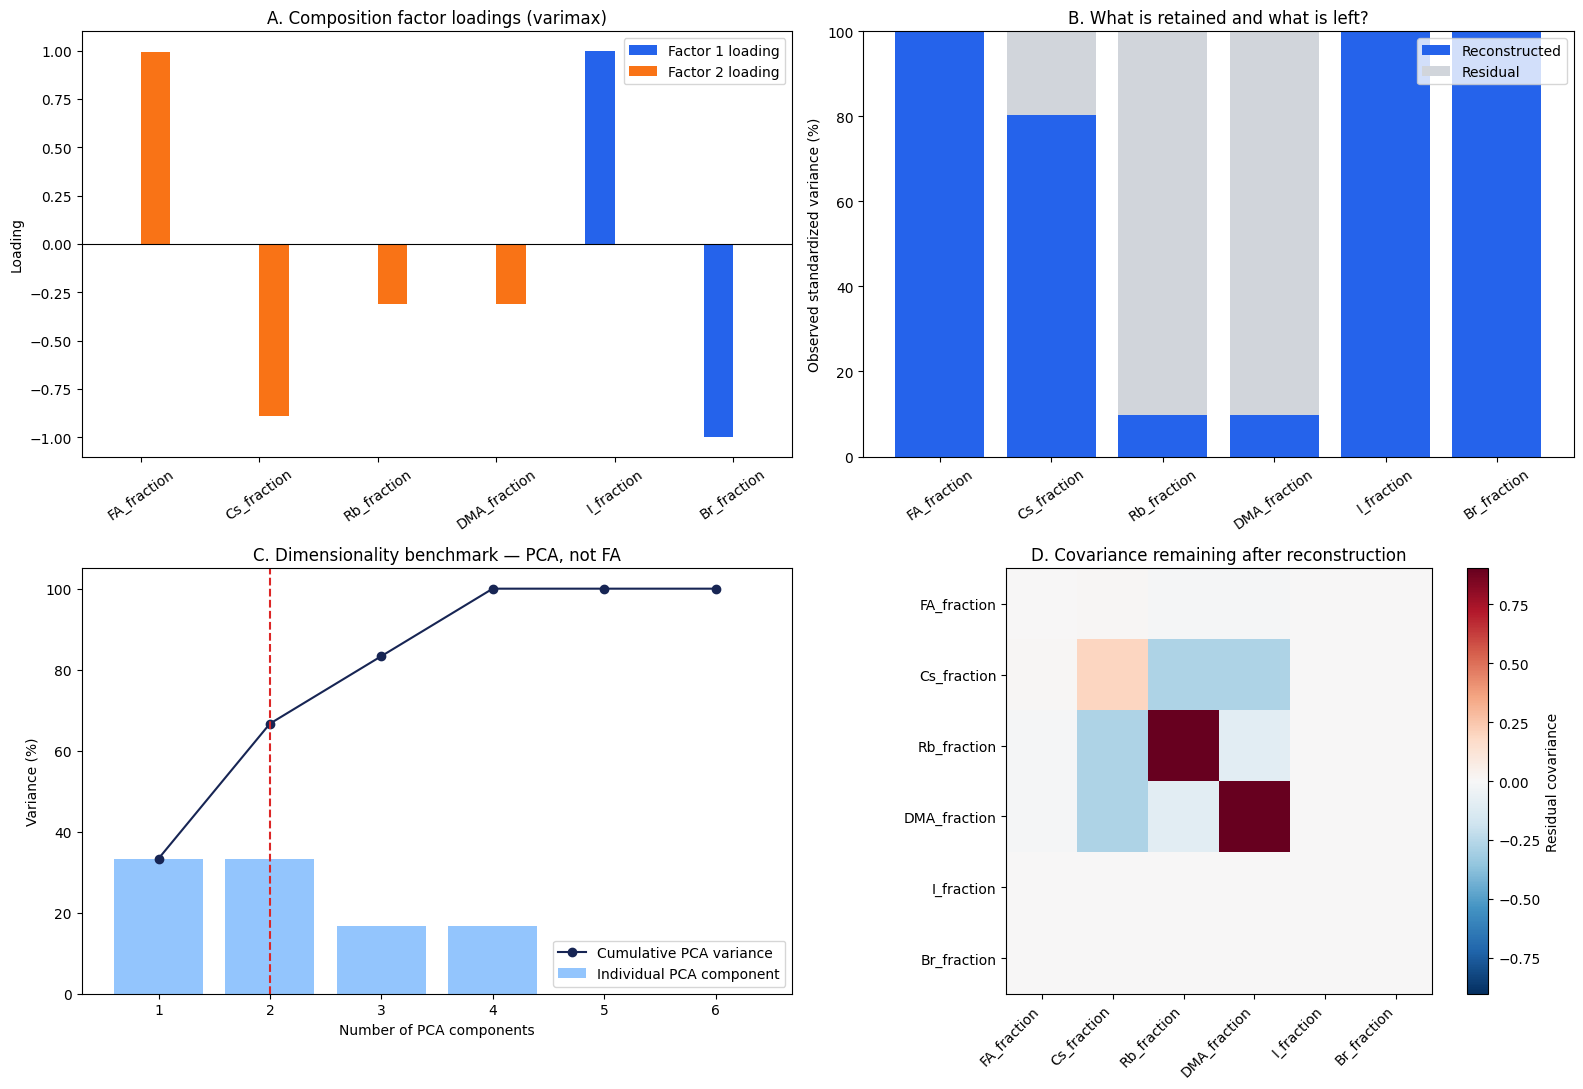

Wells least faithfully represented by two factors:


,well,FA_fraction_residual,Cs_fraction_residual,Rb_fraction_residual,DMA_fraction_residual,I_fraction_residual,Br_fraction_residual,residual_norm_standardized
47,D12,-0.0060,-0.1052,0.0556,0.0556,-0.0,0.0,2.3723
43,D8,-0.0060,-0.1052,0.0556,0.0556,0.0,-0.0,2.3723
39,D4,-0.0060,-0.1052,0.0556,0.0556,0.0,-0.0,2.3723
44,D9,-0.0004,-0.0302,0.0653,-0.0347,-0.0,0.0,2.0224
3,A4,-0.0004,-0.0302,-0.0347,0.0653,0.0,-0.0,2.0224
7,A8,-0.0004,-0.0302,-0.0347,0.0653,0.0,-0.0,2.0224
40,D5,-0.0004,-0.0302,0.0653,-0.0347,0.0,-0.0,2.0224
11,A12,-0.0004,-0.0302,-0.0347,0.0653,-0.0,0.0,2.0224
36,D1,-0.0004,-0.0302,0.0653,-0.0347,0.0,-0.0,2.0224
48,E1,0.0046,0.0864,-0.0455,-0.0455,0.0,-0.0,1.9437


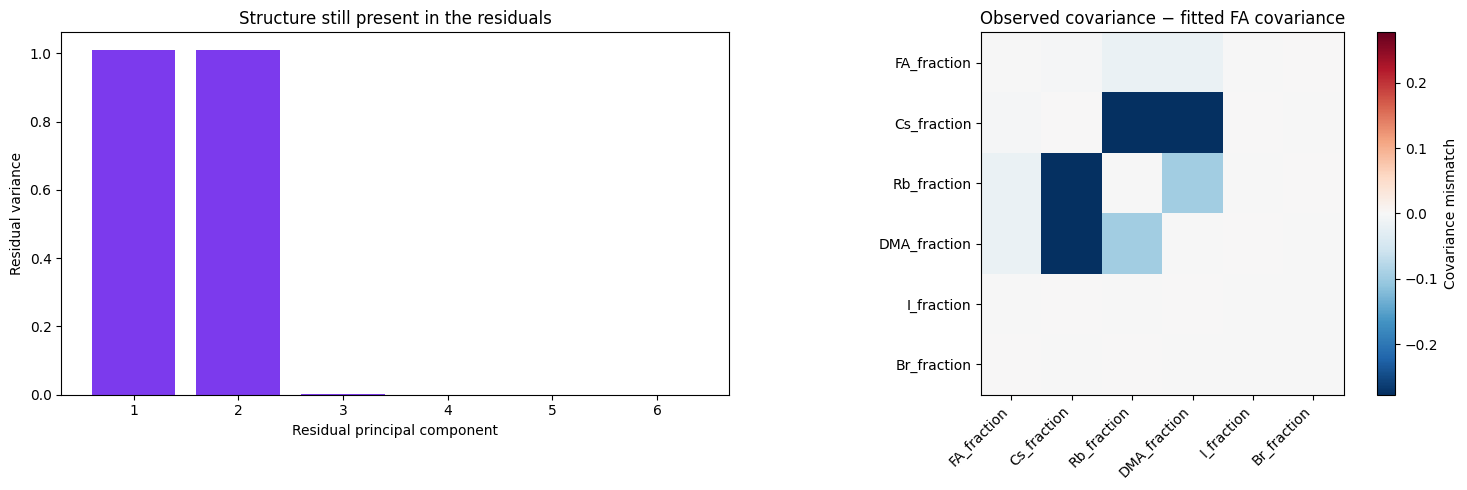

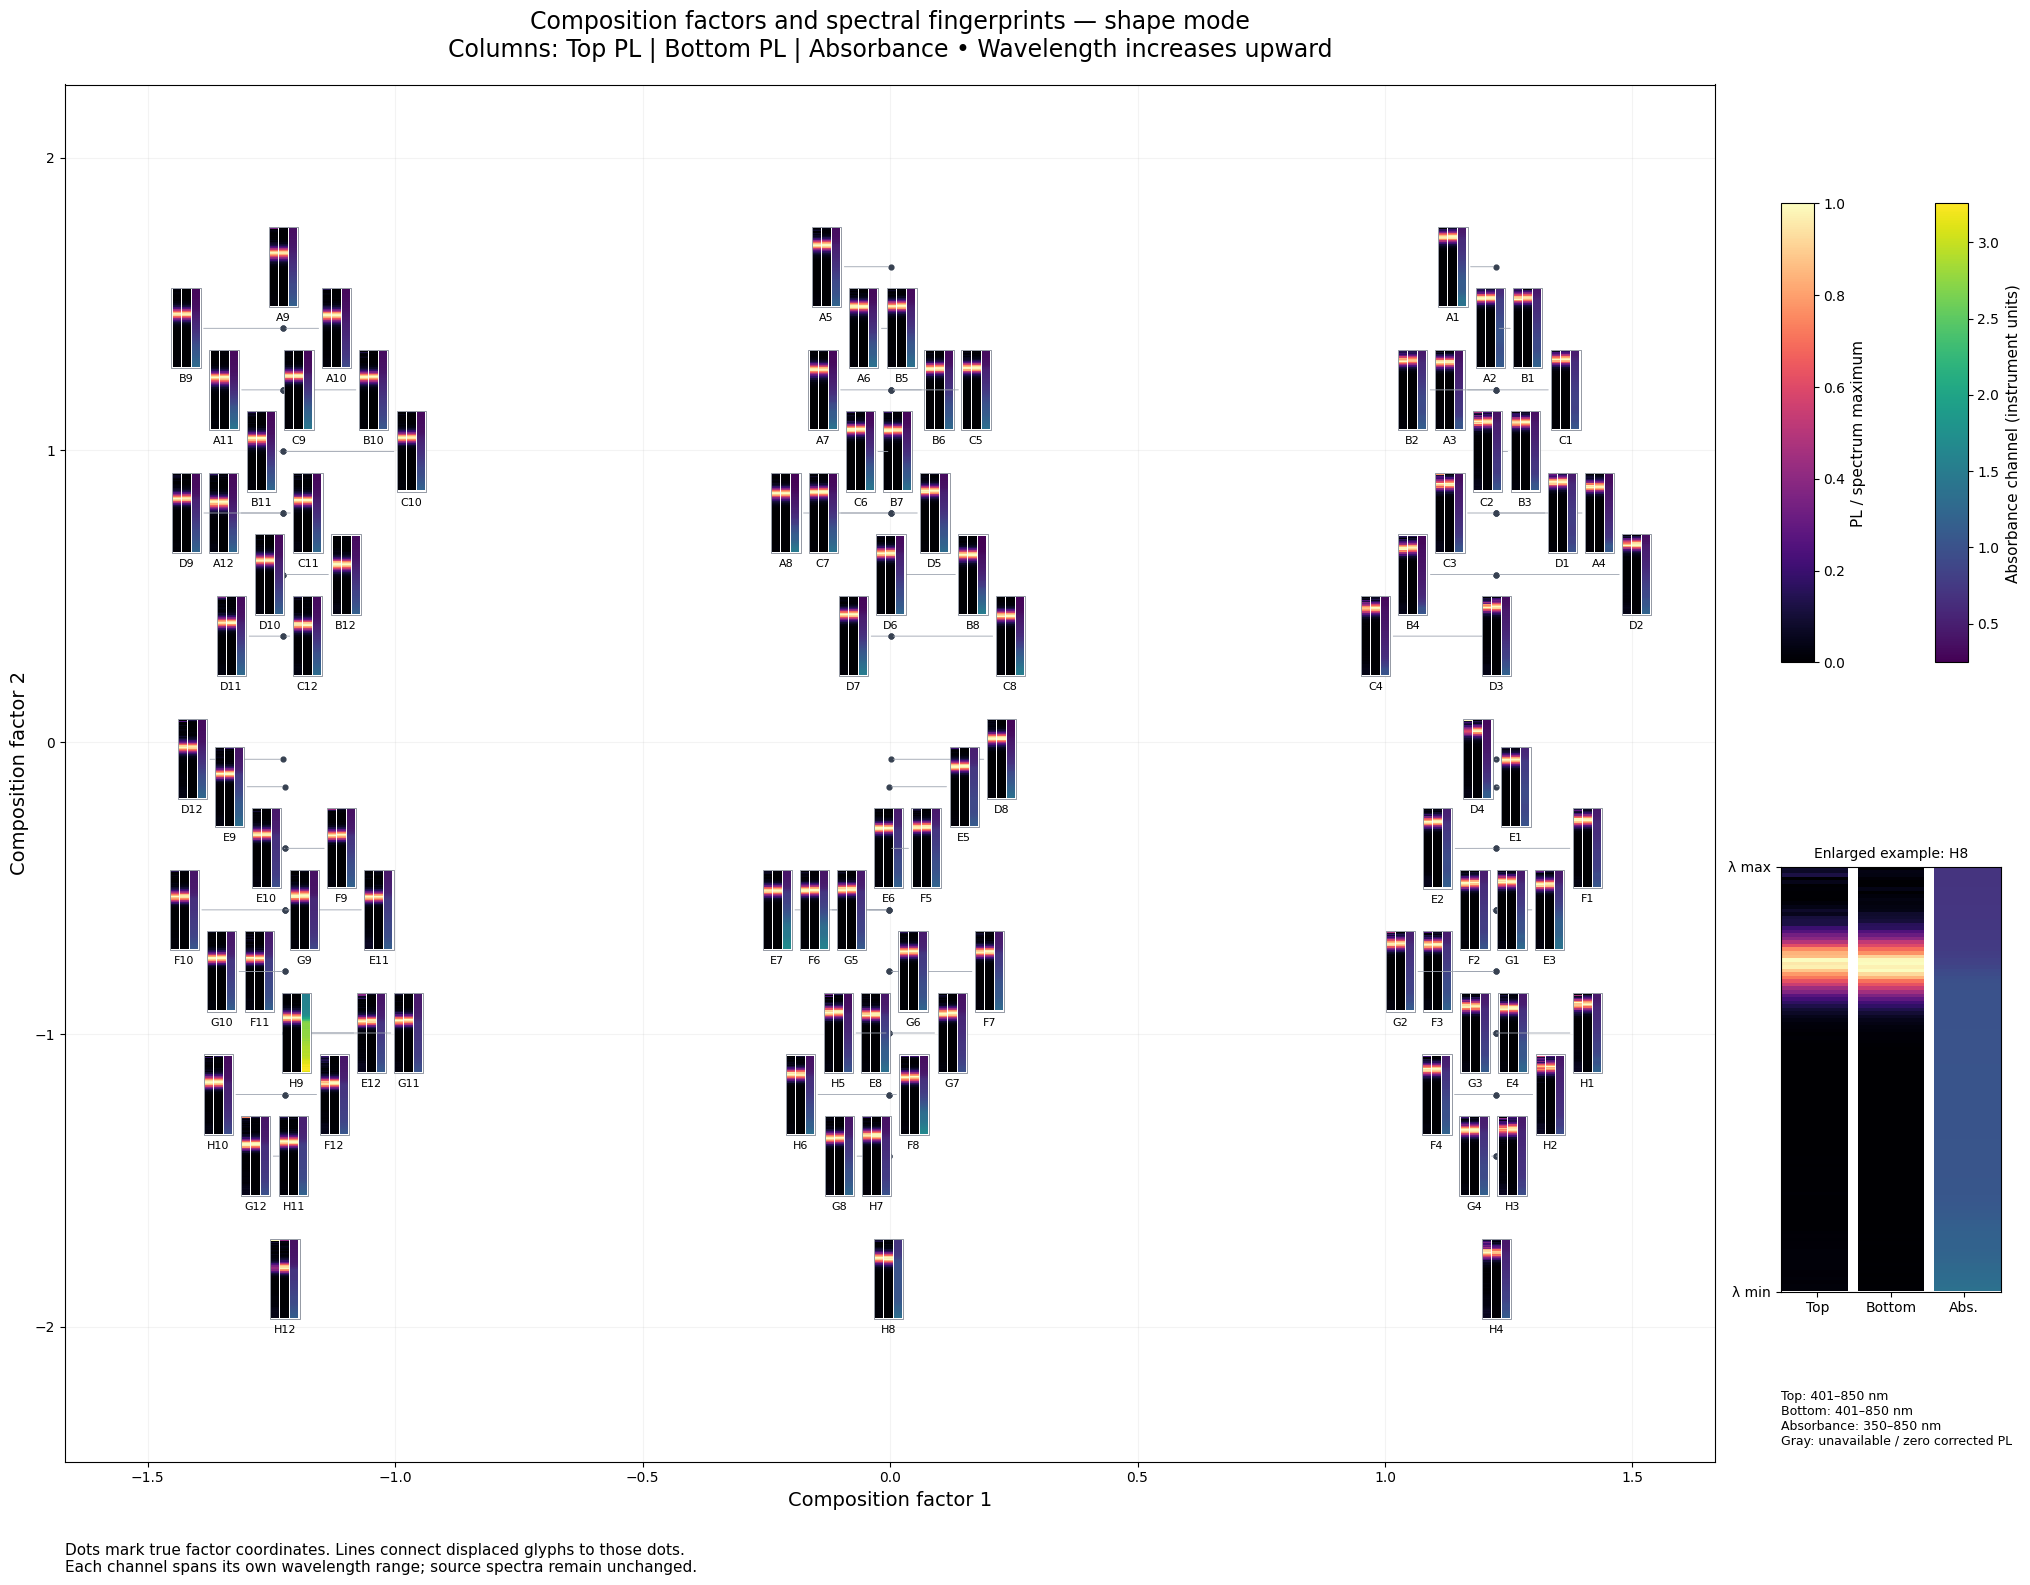

In [20]:
# ============================================================
# Challenge 1 — factor diagnostics + readable spectral strips
# Run after the original Challenge 1 cells.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis, PCA
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from IPython.display import display

# --------------------------- Settings ------------------------
PL_MODE = "shape"              # "shape" or "intensity"
BASELINE_CORRECT_PL = True
MAP_FIGSIZE = (22, 17)
GLYPH_WIDTH_PX = 27            # three vertical columns
GLYPH_HEIGHT_PX = 78
GLYPH_GAP_PX = 10
SPECTRAL_PIXELS = 120          # display sampling; source unchanged

COMPOSITION_COLUMNS = [
    "FA_fraction", "Cs_fraction", "Rb_fraction", "DMA_fraction",
    "I_fraction", "Br_fraction", "Cl_fraction",
]
GEOMETRIES = ["Top", "Bottom", "Absorbance"]

if PL_MODE not in {"shape", "intensity"}:
    raise ValueError("PL_MODE must be 'shape' or 'intensity'.")

composition = quaternary_composition.copy().reset_index(drop=True)
if composition["well"].duplicated().any():
    raise ValueError("Composition table must have one row per well.")

X = composition[COMPOSITION_COLUMNS].astype(float)
if not np.isfinite(X.to_numpy()).all():
    raise ValueError("Composition contains missing/nonfinite values.")

active = [c for c in X if X[c].std(ddof=0) > 1e-12]
constant = [c for c in X if c not in active]
if len(active) < 2:
    raise ValueError("At least two varying composition variables are required.")

scaler = StandardScaler()
Z = scaler.fit_transform(X[active])

# ============================================================
# 1. Fit two-factor model and quantify what remains
# ============================================================

fa = FactorAnalysis(
    n_components=2, rotation="varimax", random_state=0
)
scores = fa.fit_transform(Z)

# Stable sign convention.
for j in range(2):
    anchor = np.argmax(np.abs(fa.components_[j]))
    if fa.components_[j, anchor] < 0:
        fa.components_[j] *= -1
        scores[:, j] *= -1

L = fa.components_.T
Z_hat = scores @ fa.components_ + fa.mean_
R = Z - Z_hat

# Empirical reconstruction diagnostics.
total_ss = np.sum((Z - Z.mean(axis=0)) ** 2)
residual_ss = np.sum(R ** 2)
retained = 1 - residual_ss / total_ss

variable_total = np.sum((Z - Z.mean(axis=0)) ** 2, axis=0)
variable_residual = np.sum(R ** 2, axis=0)
variable_retained = 1 - variable_residual / variable_total

# FA model covariance = common-factor covariance + diagonal noise.
observed_cov = np.cov(Z, rowvar=False, bias=True)
common_cov = L @ L.T
model_cov = common_cov + np.diag(fa.noise_variance_)
covariance_mismatch = observed_cov - model_cov
residual_cov = np.cov(R, rowvar=False, bias=True)

diagnostics = pd.DataFrame({
    "Factor 1 loading": L[:, 0],
    "Factor 2 loading": L[:, 1],
    "Common variance (model)": np.sum(L**2, axis=1),
    "Unique variance (model)": fa.noise_variance_,
    "Reconstructed variance (%)": 100 * variable_retained,
    "Residual RMSE (standardized)": np.sqrt(np.mean(R**2, axis=0)),
}, index=active)

print("TWO-FACTOR COMPOSITION ANALYSIS")
print(f"Empirical variance reconstructed: {100 * retained:.1f}%")
print(f"Empirical variance left in residuals: {100 * (1-retained):.1f}%")
print(f"Overall residual RMSE: {np.sqrt(np.mean(R**2)):.3f}")
if constant:
    print("Constant variables excluded:", ", ".join(constant))
display(diagnostics.round(3))

# PCA gives the best linear variance-retention benchmark for 2D.
# Its explained variance is not the FA explained variance.
pca = PCA().fit(Z)
cum_pca = np.cumsum(pca.explained_variance_ratio_)
print(
    f"Two-component PCA benchmark: {100*cum_pca[1]:.1f}% "
    "of standardized composition variance."
)
print(
    "FA reconstruction above uses estimated factor scores. "
    "Model unique variance and empirical reconstruction residuals "
    "are different quantities."
)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# A. Loadings
diagnostics[["Factor 1 loading", "Factor 2 loading"]].plot.bar(
    ax=axes[0, 0], color=["#2563eb", "#f97316"]
)
axes[0, 0].axhline(0, color="black", lw=0.8)
axes[0, 0].set_title("A. Composition factor loadings (varimax)")
axes[0, 0].set_ylabel("Loading")
axes[0, 0].tick_params(axis="x", rotation=35)

# B. Per-variable reconstruction
axes[0, 1].bar(
    active, 100*variable_retained, color="#2563eb",
    label="Reconstructed"
)
axes[0, 1].bar(
    active, 100*(1-variable_retained),
    bottom=100*variable_retained, color="#d1d5db",
    label="Residual"
)
axes[0, 1].set_ylim(0, 100)
axes[0, 1].set_title("B. What is retained and what is left?")
axes[0, 1].set_ylabel("Observed standardized variance (%)")
axes[0, 1].tick_params(axis="x", rotation=35)
axes[0, 1].legend()

# C. PCA benchmark / dimensionality
k = np.arange(1, len(cum_pca)+1)
axes[1, 0].bar(
    k, 100*pca.explained_variance_ratio_,
    color="#93c5fd", label="Individual PCA component"
)
axes[1, 0].plot(
    k, 100*cum_pca, "o-", color="#172554",
    label="Cumulative PCA variance"
)
axes[1, 0].axvline(2, color="#dc2626", ls="--")
axes[1, 0].set_xticks(k)
axes[1, 0].set_ylim(0, 105)
axes[1, 0].set_xlabel("Number of PCA components")
axes[1, 0].set_ylabel("Variance (%)")
axes[1, 0].set_title("C. Dimensionality benchmark — PCA, not FA")
axes[1, 0].legend()

# D. Residual covariance
bound = max(np.max(np.abs(residual_cov)), 1e-12)
im = axes[1, 1].imshow(
    residual_cov, cmap="RdBu_r", vmin=-bound, vmax=bound
)
axes[1, 1].set_xticks(range(len(active)), active, rotation=45, ha="right")
axes[1, 1].set_yticks(range(len(active)), active)
axes[1, 1].set_title("D. Covariance remaining after reconstruction")
fig.colorbar(im, ax=axes[1, 1], label="Residual covariance")

fig.tight_layout()
plt.show()

# Show residual structure in the ORIGINAL composition units.
X_hat = scaler.inverse_transform(Z_hat)
residual_table = pd.DataFrame(
    X[active].to_numpy() - X_hat,
    columns=[f"{c}_residual" for c in active]
)
residual_table.insert(0, "well", composition["well"].to_numpy())
residual_table["residual_norm_standardized"] = np.linalg.norm(R, axis=1)

print("Wells least faithfully represented by two factors:")
display(
    residual_table.sort_values(
        "residual_norm_standardized", ascending=False
    ).head(10).round(4)
)

# Residual dimensionality: what organized variation was omitted?
residual_pca = PCA().fit(R)
remaining_variance = residual_pca.explained_variance_

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(
    np.arange(1, len(remaining_variance)+1),
    remaining_variance, color="#7c3aed"
)
axes[0].set_xlabel("Residual principal component")
axes[0].set_ylabel("Residual variance")
axes[0].set_title("Structure still present in the residuals")

mismatch_bound = max(np.max(np.abs(covariance_mismatch)), 1e-12)
im = axes[1].imshow(
    covariance_mismatch, cmap="RdBu_r",
    vmin=-mismatch_bound, vmax=mismatch_bound
)
axes[1].set_xticks(range(len(active)), active, rotation=45, ha="right")
axes[1].set_yticks(range(len(active)), active)
axes[1].set_title("Observed covariance − fitted FA covariance")
fig.colorbar(im, ax=axes[1], label="Covariance mismatch")
fig.tight_layout()
plt.show()

# ============================================================
# 2. Prepare spectra for vertical strip fingerprints
# ============================================================

spectra = {}
wavelength_ranges = {}

for geometry in GEOMETRIES:
    channel = quaternary_optical[
        quaternary_optical["geometry"].eq(geometry)
    ]
    wavelengths = np.sort(channel["wavelength_nm"].astype(float).unique())
    if len(wavelengths) < 2:
        raise ValueError(f"Insufficient wavelength coverage: {geometry}")

    wavelength_ranges[geometry] = (wavelengths[0], wavelengths[-1])
    display_grid = np.linspace(
        wavelengths[0], wavelengths[-1], SPECTRAL_PIXELS
    )

    for well in composition["well"]:
        series = (
            channel[channel["well"].eq(well)]
            .groupby("wavelength_nm")["optical_signal_instrument_units"]
            .mean().sort_index()
        )
        raw = series.to_numpy(float)
        wl = series.index.to_numpy(float)

        if geometry in {"Top", "Bottom"} and np.isfinite(raw).any():
            if BASELINE_CORRECT_PL:
                raw = raw - np.nanpercentile(raw, 5)
            raw = np.clip(raw, 0, None)

        # Do not interpolate through missing spectral entries.
        if len(raw) < 2 or not np.isfinite(raw).all():
            sampled = np.full(SPECTRAL_PIXELS, np.nan)
        else:
            sampled = np.interp(
                display_grid, wl, raw, left=np.nan, right=np.nan
            )
        spectra[(well, geometry)] = sampled

pl_values = np.concatenate([
    v for (w, g), v in spectra.items() if g in {"Top", "Bottom"}
])
pl_finite = pl_values[np.isfinite(pl_values)]
pl_max = max(float(pl_finite.max()), 1e-12) if pl_finite.size else 1.0

abs_values = np.concatenate([
    v for (w, g), v in spectra.items() if g == "Absorbance"
])
abs_finite = abs_values[np.isfinite(abs_values)]
if not abs_finite.size:
    raise ValueError("No finite absorbance spectra.")

abs_lo, abs_hi = float(abs_finite.min()), float(abs_finite.max())
if abs_hi <= abs_lo:
    abs_hi = abs_lo + 1.0

pl_norm = Normalize(0, 1 if PL_MODE == "shape" else pl_max)
abs_norm = Normalize(abs_lo, abs_hi)

pl_cmap = plt.get_cmap("magma").copy()
abs_cmap = plt.get_cmap("viridis").copy()
pl_cmap.set_bad("#bdbdbd")
abs_cmap.set_bad("#bdbdbd")

def fingerprint(well):
    """RGBA image: wavelength upward; columns Top, Bottom, absorbance."""
    columns = []
    for geometry in GEOMETRIES:
        signal = spectra[(well, geometry)].copy()

        if geometry in {"Top", "Bottom"}:
            finite = signal[np.isfinite(signal)]
            maximum = finite.max() if finite.size else 0
            if maximum <= 0:
                signal[:] = np.nan
            elif PL_MODE == "shape":
                signal /= maximum
            rgba = pl_cmap(pl_norm(np.ma.masked_invalid(signal)))
        else:
            rgba = abs_cmap(abs_norm(np.ma.masked_invalid(signal)))

        columns.append(np.repeat(rgba[:, None, :], 7, axis=1))

    separator = np.ones((SPECTRAL_PIXELS, 1, 4))
    return np.concatenate(
        [columns[0], separator, columns[1], separator, columns[2]],
        axis=1,
    )

# ============================================================
# 3. Fixed-size glyphs, with collision handling in screen space
# ============================================================

fig, ax = plt.subplots(figsize=MAP_FIGSIZE, dpi=100)
fig.subplots_adjust(left=0.07, right=0.82, bottom=0.09, top=0.90)

span = np.ptp(scores, axis=0)
span = np.where(span > 0, span, 1.0)
ax.set_xlim(scores[:, 0].min()-0.18*span[0],
            scores[:, 0].max()+0.18*span[0])
ax.set_ylim(scores[:, 1].min()-0.18*span[1],
            scores[:, 1].max()+0.18*span[1])

ax.set_xlabel("Composition factor 1", fontsize=14)
ax.set_ylabel("Composition factor 2", fontsize=14)
ax.set_title(
    f"Composition factors and spectral fingerprints — {PL_MODE} mode\n"
    "Columns: Top PL | Bottom PL | Absorbance • Wavelength increases upward",
    fontsize=17, pad=20
)
ax.grid(alpha=0.15)
ax.scatter(scores[:, 0], scores[:, 1], s=12, c="#374151", zorder=2)
fig.canvas.draw()

anchors = ax.transData.transform(scores)
positions = anchors.copy()

# Break exact-coordinate ties deterministically.
rng = np.random.default_rng(0)
positions += rng.normal(0, 0.5, positions.shape)

box_width = GLYPH_WIDTH_PX + GLYPH_GAP_PX
box_height = GLYPH_HEIGHT_PX + 24 + GLYPH_GAP_PX

bounds = ax.get_window_extent()
lower = np.array([
    bounds.x0 + box_width/2, bounds.y0 + box_height/2
])
upper = np.array([
    bounds.x1 - box_width/2, bounds.y1 - box_height/2
])

def resolve_collisions(positions, iterations, spring):
    positions = positions.copy()
    for iteration in range(iterations):
        moves = spring * (anchors - positions)
        collisions = 0

        for i in range(len(positions)):
            for j in range(i+1, len(positions)):
                delta = positions[j] - positions[i]
                overlap_x = box_width - abs(delta[0])
                overlap_y = box_height - abs(delta[1])

                if overlap_x > 0 and overlap_y > 0:
                    collisions += 1
                    # Separate in the direction requiring less displacement.
                    axis = 0 if overlap_x < overlap_y else 1
                    overlap = overlap_x if axis == 0 else overlap_y
                    sign = 1 if delta[axis] >= 0 else -1
                    displacement = 0.52 * (overlap + 1)
                    moves[i, axis] -= sign * displacement
                    moves[j, axis] += sign * displacement

        positions += np.clip(moves, -12, 12)
        positions = np.clip(positions, lower, upper)
        if collisions == 0 and spring == 0:
            break
    return positions

positions = resolve_collisions(positions, 500, spring=0.015)
positions = resolve_collisions(positions, 1200, spring=0)
glyph_coordinates = ax.transData.inverted().transform(positions)

for i, well in enumerate(composition["well"]):
    image = fingerprint(well)

    # OffsetImage preserves aspect ratio. Resample to desired pixel shape.
    row_indices = np.linspace(
        0, image.shape[0]-1, GLYPH_HEIGHT_PX
    ).round().astype(int)
    col_indices = np.linspace(
        0, image.shape[1]-1, GLYPH_WIDTH_PX
    ).round().astype(int)
    image = image[row_indices][:, col_indices]

    artist = AnnotationBbox(
        OffsetImage(image, zoom=1, origin="lower", dpi_cor=False),
        xy=scores[i],
        xybox=glyph_coordinates[i],
        xycoords="data",
        boxcoords="data",
        frameon=True,
        pad=0.08,
        bboxprops={"edgecolor": "#6b7280", "linewidth": 0.5},
        arrowprops={"arrowstyle": "-", "color": "#9ca3af", "lw": 0.6},
        zorder=3,
    )
    ax.add_artist(artist)
    ax.annotate(
        well, glyph_coordinates[i],
        xytext=(0, -(GLYPH_HEIGHT_PX/2 + 7)),
        textcoords="offset pixels",
        ha="center", va="top", fontsize=8,
        zorder=4
    )

# Dedicated colorbars and an enlarged example fingerprint.
pl_cax = fig.add_axes([0.85, 0.56, 0.015, 0.27])
fig.colorbar(
    ScalarMappable(norm=pl_norm, cmap=pl_cmap), cax=pl_cax
).set_label(
    "PL / spectrum maximum" if PL_MODE == "shape"
    else "PL signal (instrument units)",
    fontsize=11
)

abs_cax = fig.add_axes([0.92, 0.56, 0.015, 0.27])
fig.colorbar(
    ScalarMappable(norm=abs_norm, cmap=abs_cmap), cax=abs_cax
).set_label("Absorbance channel (instrument units)", fontsize=11)

example_well = "H8" if "H8" in set(composition["well"]) else composition["well"].iloc[0]
legend_ax = fig.add_axes([0.85, 0.19, 0.10, 0.25])
legend_ax.imshow(
    fingerprint(example_well), origin="lower", aspect="auto",
    extent=[0, 3, 0, 1], interpolation="nearest"
)
legend_ax.set_xticks([0.5, 1.5, 2.5], ["Top", "Bottom", "Abs."])
legend_ax.set_yticks([0, 1], ["λ min", "λ max"])
legend_ax.set_title(f"Enlarged example: {example_well}", fontsize=10)

range_text = "\n".join(
    f"{g}: {lo:g}–{hi:g} nm"
    for g, (lo, hi) in wavelength_ranges.items()
)
fig.text(
    0.85, 0.10,
    range_text + "\nGray: unavailable / zero corrected PL",
    fontsize=9
)

fig.text(
    0.07, 0.025,
    "Dots mark true factor coordinates. Lines connect displaced glyphs to those dots.\n"
    "Each channel spans its own wavelength range; source spectra remain unchanged.",
    fontsize=11
)
plt.show()

# Report any remaining overlaps instead of silently ignoring them.
remaining_overlaps = sum(
    abs(positions[j, 0]-positions[i, 0]) < box_width
    and abs(positions[j, 1]-positions[i, 1]) < box_height
    for i in range(len(positions))
    for j in range(i+1, len(positions))
)
if remaining_overlaps:
    print(
        f"{remaining_overlaps} glyph pairs still overlap. "
        "Increase MAP_FIGSIZE or reduce GLYPH_HEIGHT_PX."
    )

# Tables remain available for subsequent analysis:
# diagnostics, residual_table, scores, Z_hat, R, loading matrix L

<h2><font color="purple">3.</font> Explore the RP-Additive System</h2>

### Problem 2

> **Where do emission bands appear, disappear, or shift with composition and time,
> and do Top and Bottom measurements tell the same story?**

Columns vary the nominal 3AMP/FAPbI3 host mix. Rows vary the nominal MACl design
level. Each well has Top and Bottom PL every 20 minutes from 0 to 380 minutes.

The host fractions form one closed basis. MACl is a separate experimental axis. A
single final-time map hides the trajectory, while 20 separate maps are cumbersome.
The baseline solution pairs a **composition overview at one time** with a
**time × wavelength heatmap** for one selected well.


In [13]:
# Reusable Challenge 2 composition map at one elapsed time
RP_METRICS = {
    "red_fraction_760_820": "Fraction of PL from 760–820 nm",
    "peak_nm": "Dominant emission (nm)",
    "peak_shift_vs_t0": "Peak shift from t0 (nm)",
    "retention_vs_t0": "Integrated PL / t0",
}
RP_COLORBAR_TITLES = {
    "red_fraction_760_820": "760–820 nm<br>PL fraction",
    "peak_nm": "Peak<br>(nm)",
    "peak_shift_vs_t0": "Peak shift<br>(nm)",
    "retention_vs_t0": "PL / t0",
}

def rp_composition_map(
    measure="Bottom PL", time_min=380, metric="red_fraction_760_820",
    selected_well="H7",
):
    current = rp_features[
        rp_features["measure"].eq(measure)
        & np.isclose(rp_features["time_min"], float(time_min))
    ].copy()
    valid = current[current["qc_status"].eq("valid")]
    all_valid = rp_features[
        rp_features["measure"].eq(measure)
        & rp_features["qc_status"].eq("valid")
    ]
    diverging = metric == "peak_shift_vs_t0"
    if diverging:
        bound = float(np.nanmax(np.abs(all_valid[metric])))
        color_range = [-bound, bound]
    else:
        color_range = [float(all_valid[metric].min()), float(all_valid[metric].max())]

    figure = px.scatter(
        valid, x="FAPbI3_percent", y="additive_percent", color=metric,
        custom_data=["well", "spacer_percent", "qc_status"],
        labels={
            "FAPbI3_percent": "FAPbI3 host (%)",
            "additive_percent": "MACl level (%)",
            metric: RP_METRICS[metric],
        },
        color_continuous_scale="RdBu_r" if diverging else "Viridis",
        range_color=color_range,
        title=(
            f"{measure} at {time_min:g} min"
            f"<br><sup>Color: {RP_METRICS[metric]}</sup>"
        ),
        height=650,
    )
    figure.update_traces(
        marker={"size": 16, "line": {"color": "white", "width": 1}},
        hovertemplate=(
            "<b>Well %{customdata[0]}</b><br>FAPbI3 %{x:.1f}%<br>"
            "3AMP host %{customdata[1]:.1f}%<br>MACl level %{y:g}%<br>"
            "Value %{marker.color:.4g}<extra></extra>"
        ),
    )
    invalid = current[~current["qc_status"].eq("valid")]
    if not invalid.empty:
        figure.add_trace(go.Scatter(
            x=invalid["FAPbI3_percent"], y=invalid["additive_percent"],
            mode="markers", name="Low/invalid PL",
            marker={"size": 13, "symbol": "x", "color": "#6b7280"},
            text=invalid["well"], hovertemplate="Well %{text}<extra></extra>",
        ))
    selected = current[current["well"].eq(selected_well)]
    if not selected.empty:
        figure.add_trace(go.Scatter(
            x=selected["FAPbI3_percent"], y=selected["additive_percent"],
            mode="markers", name=f"Selected: {selected_well}",
            marker={"size": 20, "symbol": "circle-open", "color": "black",
                    "line": {"width": 3}},
            hoverinfo="skip",
        ))
    figure.update_coloraxes(colorbar={
        "title": {"text": RP_COLORBAR_TITLES[metric], "side": "right"},
        "thickness": 18,
        "len": 0.72,
        "x": 1.02,
    })
    figure.update_xaxes(range=[-5, 105], automargin=True)
    figure.update_yaxes(range=[-1, 21.5], automargin=True)
    figure.update_layout(
        template="plotly_white", autosize=True,
        margin={"l": 80, "r": 145, "t": 105, "b": 120},
        title={"x": 0.01, "xanchor": "left"},
        legend={
            "orientation": "h", "yanchor": "top", "y": -0.20,
            "xanchor": "left", "x": 0,
        },
    )
    return figure


In [14]:
# Reusable Challenge 2 time × wavelength view for one composition
def rp_time_wavelength(well="H7", measure="Bottom PL"):
    rows = rp_features[
        rp_features["well"].eq(well) & rp_features["measure"].eq(measure)
    ].sort_values("time_min")
    matrix = rp_spectra_by_id.loc[
        rows["spectrum_id"], rp_wavelength_columns
    ].to_numpy(float, copy=True)
    valid = rows["qc_status"].eq("valid").to_numpy()
    matrix[~valid] = np.nan
    maxima = np.ones((len(rows), 1))
    maxima[valid] = np.max(matrix[valid], axis=1, keepdims=True)
    matrix = matrix / maxima

    composition = rp_composition[rp_composition["well"].eq(well)].iloc[0]
    subtitle = (
        f"FAPbI3 host {composition.FAPbI3_percent:.1f}% | "
        f"3AMP host {composition.spacer_percent:.1f}% | "
        f"MACl nominal level {composition.additive_percent:g}%"
    )
    figure = go.Figure(go.Heatmap(
        x=rp_wavelengths, y=rows["time_min"], z=matrix,
        zmin=0, zmax=1, colorscale="Magma",
        colorbar={
            "title": {"text": "PL shape<br>(0–1)", "side": "right"},
            "thickness": 18,
            "len": 0.78,
            "x": 1.02,
        },
        hovertemplate="%{x:.0f} nm<br>%{y:.0f} min<br>%{z:.3f}<extra></extra>",
    ))
    figure.update_layout(
        title=f"Well {well} | {measure}<br><sup>{subtitle}</sup>",
        xaxis_title="Wavelength (nm)", yaxis_title="Elapsed time (min)",
        height=650, template="plotly_white", plot_bgcolor="#d1d5db",
        autosize=True, margin={"l": 85, "r": 125, "t": 105, "b": 75},
        title_x=0.01,
    )
    return figure


# Worked Example — RP-Additive System

### Question

Which compositions show strong long-wavelength PL at 380 minutes, and how did the
spectrum of one selected well evolve to that state?

### Baseline solution

The map uses fixed color limits across time. Low/invalid PL is gray rather than being
silently converted to zero. The second figure retains the complete time–wavelength
history for well H7. The figures are stacked at full width for legibility.


In [15]:
RP_EXAMPLE_WELL = "H7"
RP_EXAMPLE_MEASURE = "Bottom PL"
rp_example_figures = [
    rp_composition_map(
        RP_EXAMPLE_MEASURE, 380, "red_fraction_760_820", RP_EXAMPLE_WELL
    ),
    rp_time_wavelength(RP_EXAMPLE_WELL, RP_EXAMPLE_MEASURE),
]
show_figures(rp_example_figures)

history = rp_features[
    rp_features["well"].eq(RP_EXAMPLE_WELL)
    & rp_features["measure"].eq(RP_EXAMPLE_MEASURE)
].sort_values("time_min")
initial, final = history.iloc[0], history.iloc[-1]
display(Markdown(f'''
### What did we just do?

At **{RP_EXAMPLE_WELL}**, the Bottom-PL dominant maximum
changes from **{initial.peak_nm:.0f} nm** at {initial.time_min:.0f} minutes to
**{final.peak_nm:.0f} nm** at {final.time_min:.0f} minutes. Its 760–820 nm fraction
changes from **{initial.red_fraction_760_820:.3f}** to
**{final.red_fraction_760_820:.3f}**. The heatmap shows whether that scalar change is
a moving band, a competing band, or a change in spectral weight. It is not by itself
evidence of a structural phase transition.
'''))



### What did we just do?

At **H7**, the Bottom-PL dominant maximum
changes from **706 nm** at 0 minutes to
**772 nm** at 380 minutes. Its 760–820 nm fraction
changes from **0.163** to
**0.388**. The heatmap shows whether that scalar change is
a moving band, a competing band, or a change in spectral weight. It is not by itself
evidence of a structural phase transition.


So let's create tunable representation for the composition (rotating our plane in factor space) and visualzie the predictive surprise for the PL vs adsorption

Included wells: 96; distinct composition groups: 96
Excluded wells: 0
PL interval: 401.0–850.0 nm
PL mode: shape

OUT-OF-SAMPLE SUMMARY


,value
Wells,96.00000
Mean prediction RMSE,0.00242
Median prediction relative L2 error,0.45080
Mean spectral angle (degrees),26.71182
Mean centroid absolute error (nm),14.90272
Global spectral R²,0.49110
MSE skill vs training-mean spectrum,0.49759
Mean baseline RMSE,0.00367
Mean marginal 95% coverage,0.96420
Mean marginal interval width,0.00890


,fold,training_wells,calibration_wells,test_wells,negative_predicted_coefficients_%,covariance_shrinkage
0,1,57,19,20,12.5000,0.5804
1,2,57,20,19,3.9474,0.1303
2,3,57,20,19,7.8947,0.1885
3,4,57,20,19,11.8421,0.0764
4,5,57,20,19,6.5789,0.1177



Highest predictive-surprise wells:


,well,fold,PL_prediction_RMSE,PL_prediction_MAE,PL_relative_L2_error,PL_spectral_angle_deg,PL_centroid_abs_error_nm,predictive_surprise_NLL_per_bin,Mahalanobis_squared_per_bin,surprise_calibration_percentile,marginal_95pct_coverage,mean_95pct_interval_width,Top_Bottom_RMSE,Top_Bottom_relative_L2,Top_Bottom_shape_RMSE,Top_Bottom_log10_area_ratio,abs_NMF_relative_reconstruction_error,PL_NMF_relative_reconstruction_error
92,H9,4,0.00795,0.00358,1.49040,20.49756,14.15917,23.45434,48.92269,100.00000,0.79832,0.00688,0.00028,0.05302,0.00028,0.01197,0.02385,0.06338
95,H12,1,0.00272,0.00117,0.59474,26.91924,11.36530,0.48663,0.37341,100.00000,0.99580,0.01295,0.00223,0.54101,0.00223,-0.74049,0.02104,0.43615
0,A1,1,0.00410,0.00215,0.75844,48.49031,37.03047,0.47632,0.35280,100.00000,0.82353,0.01295,0.00042,0.07989,0.00042,-0.43557,0.02968,0.06573
35,C12,1,0.00321,0.00185,0.63862,39.58333,34.13983,0.40756,0.21528,84.21053,0.87395,0.01295,0.00043,0.08880,0.00043,-0.53189,0.02257,0.26929
50,E3,1,0.00334,0.00152,0.64188,37.64683,13.97016,0.40628,0.21272,84.21053,0.89076,0.01295,0.00062,0.12619,0.00062,-0.48083,0.02572,0.08278
10,A11,1,0.00352,0.00210,0.71546,45.29105,39.03793,0.40510,0.21035,84.21053,0.89076,0.01295,0.00033,0.06664,0.00033,-0.47228,0.02237,0.12387
20,B9,1,0.00208,0.00104,0.40075,22.81829,11.64948,0.37372,0.14759,78.94737,0.96639,0.01295,0.00024,0.04768,0.00024,-0.48179,0.01176,0.17910
25,C2,1,0.00208,0.00121,0.41467,23.59748,17.23897,0.36765,0.13547,73.68421,0.96639,0.01295,0.00093,0.19040,0.00093,-0.34990,0.00946,0.09560
45,D10,1,0.00188,0.00098,0.36120,18.80220,11.92322,0.36386,0.12788,73.68421,1.00000,0.01295,0.00033,0.06385,0.00033,-0.47213,0.00585,0.19745
75,G4,1,0.00149,0.00075,0.29437,17.05572,1.61531,0.34199,0.08414,63.15789,1.00000,0.01295,0.00060,0.12655,0.00060,-0.38242,0.00867,0.05145



Largest Top–Bottom disagreement:


,well,fold,PL_prediction_RMSE,PL_prediction_MAE,PL_relative_L2_error,PL_spectral_angle_deg,PL_centroid_abs_error_nm,predictive_surprise_NLL_per_bin,Mahalanobis_squared_per_bin,surprise_calibration_percentile,marginal_95pct_coverage,mean_95pct_interval_width,Top_Bottom_RMSE,Top_Bottom_relative_L2,Top_Bottom_shape_RMSE,Top_Bottom_log10_area_ratio,abs_NMF_relative_reconstruction_error,PL_NMF_relative_reconstruction_error
95,H12,1,0.00272,0.00117,0.59474,26.91924,11.36530,0.48663,0.37341,100.00000,0.99580,0.01295,0.00223,0.54101,0.00223,-0.74049,0.02104,0.43615
39,D4,2,0.00324,0.00184,0.66539,41.68226,32.37913,-0.48002,0.38123,100.00000,0.93697,0.00827,0.00199,0.50548,0.00199,-0.31709,0.01906,0.21651
87,H4,4,0.00127,0.00071,0.26860,15.32819,1.03755,-0.83846,0.33709,100.00000,0.99160,0.00688,0.00137,0.28577,0.00137,-0.20601,0.00984,0.18131
59,E12,2,0.00261,0.00155,0.51664,30.31800,34.78439,-0.55186,0.23756,100.00000,0.93277,0.00827,0.00132,0.26956,0.00132,-0.48586,0.01133,0.16923
26,C3,5,0.00295,0.00172,0.58477,35.30538,29.63537,-0.59666,0.36441,100.00000,0.90336,0.00765,0.00131,0.31253,0.00131,-0.34049,0.00406,0.12629
84,H1,2,0.00204,0.00123,0.42394,24.85010,13.12387,-0.51719,0.30689,100.00000,0.97479,0.00827,0.00118,0.24354,0.00118,-0.29138,0.01916,0.12700
71,F12,5,0.00197,0.00113,0.39020,22.01507,24.13865,-0.70026,0.15720,95.00000,1.00000,0.00765,0.00114,0.22896,0.00114,-0.51617,0.01190,0.20293
85,H2,1,0.00070,0.00041,0.16285,9.20657,5.51007,0.32931,0.05879,57.89474,1.00000,0.01295,0.00108,0.23542,0.00108,-0.25132,0.01637,0.13441
47,D12,4,0.00233,0.00127,0.46277,27.55643,17.87500,-0.69074,0.63253,100.00000,0.86555,0.00688,0.00104,0.20796,0.00104,-0.47117,0.01624,0.09130
83,G12,3,0.00181,0.00103,0.35808,20.46728,18.70548,-0.41290,0.16978,95.00000,0.98739,0.00854,0.00103,0.24152,0.00103,-0.50666,0.00886,0.18407


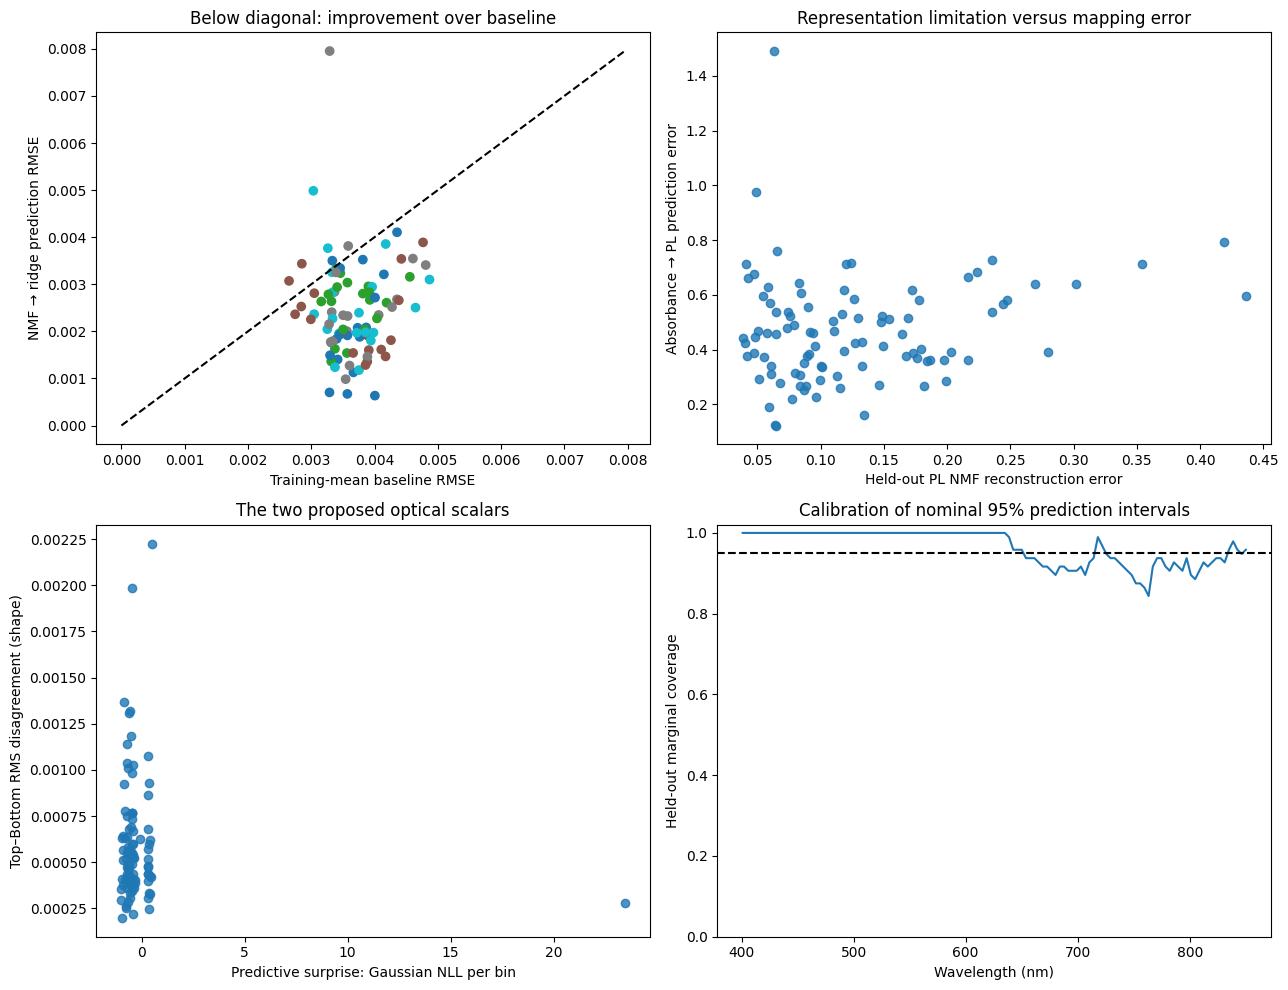

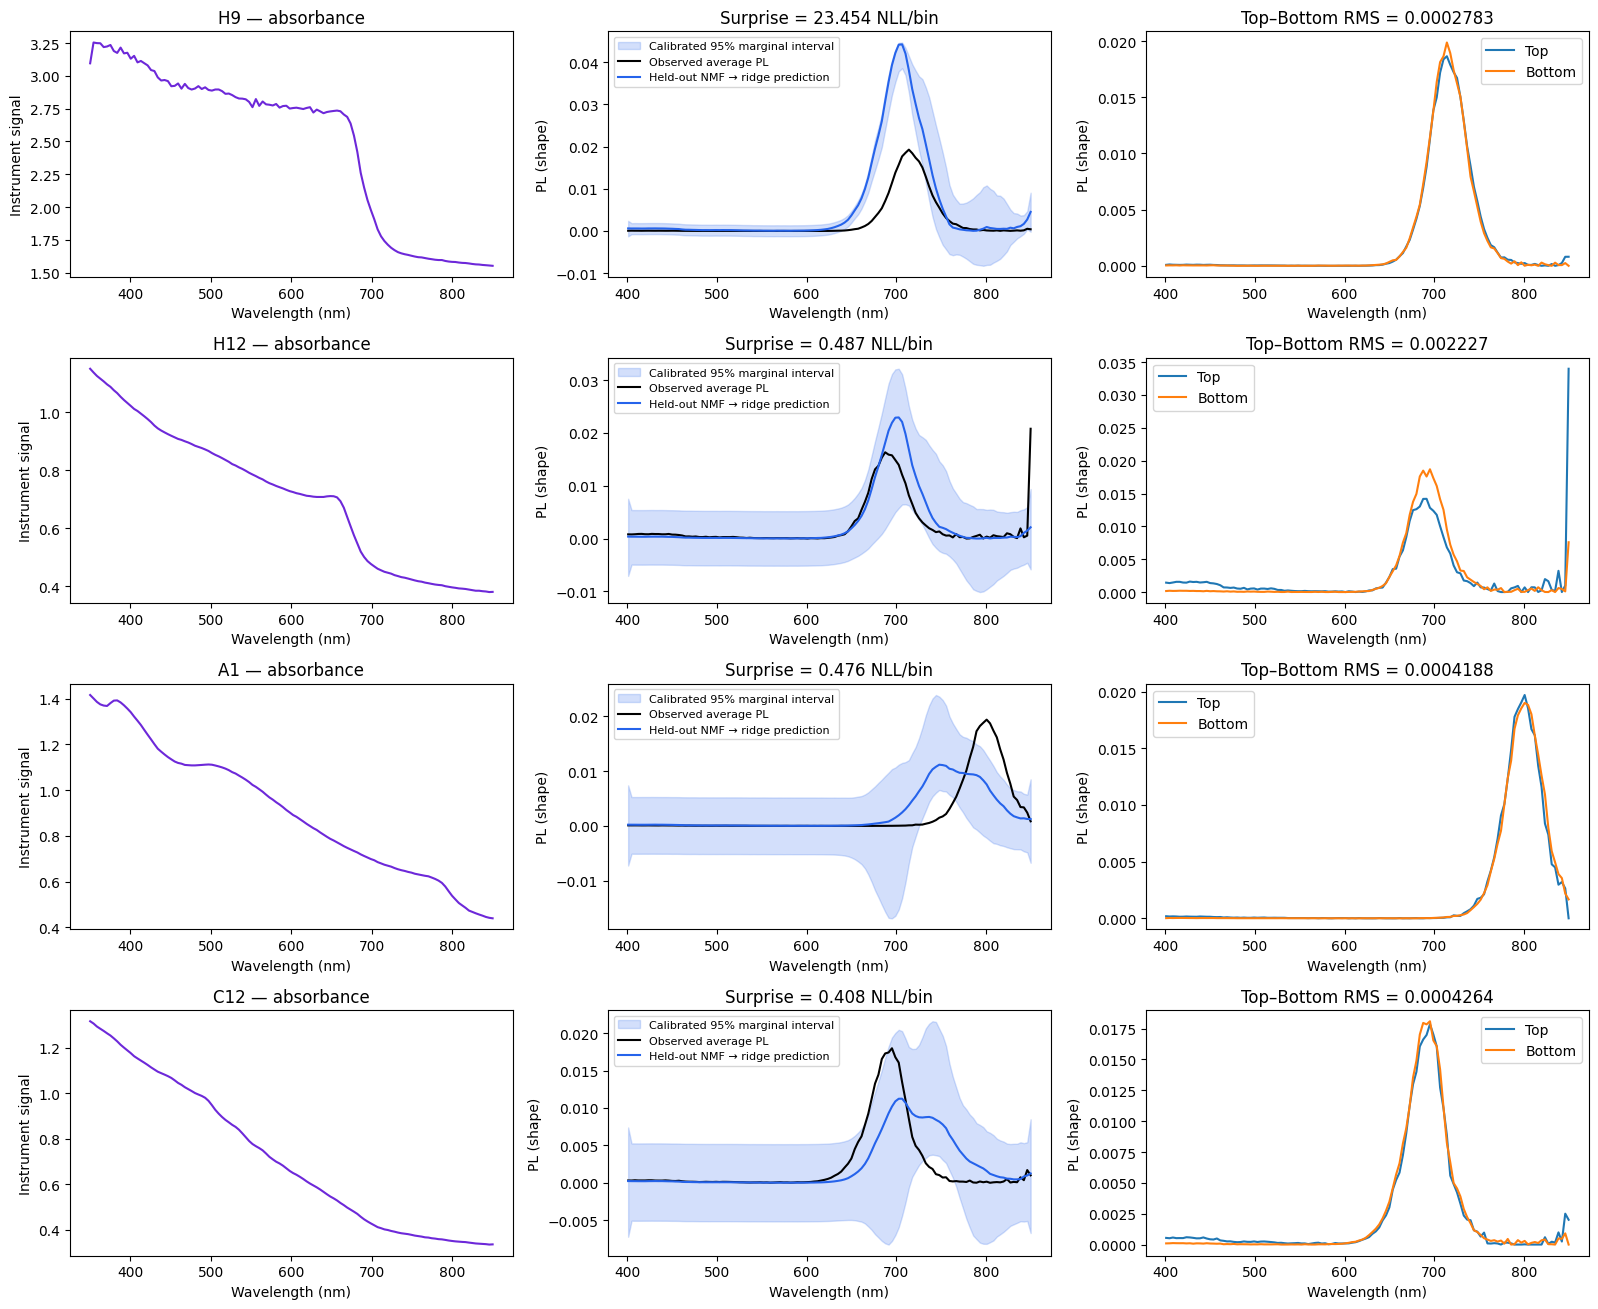

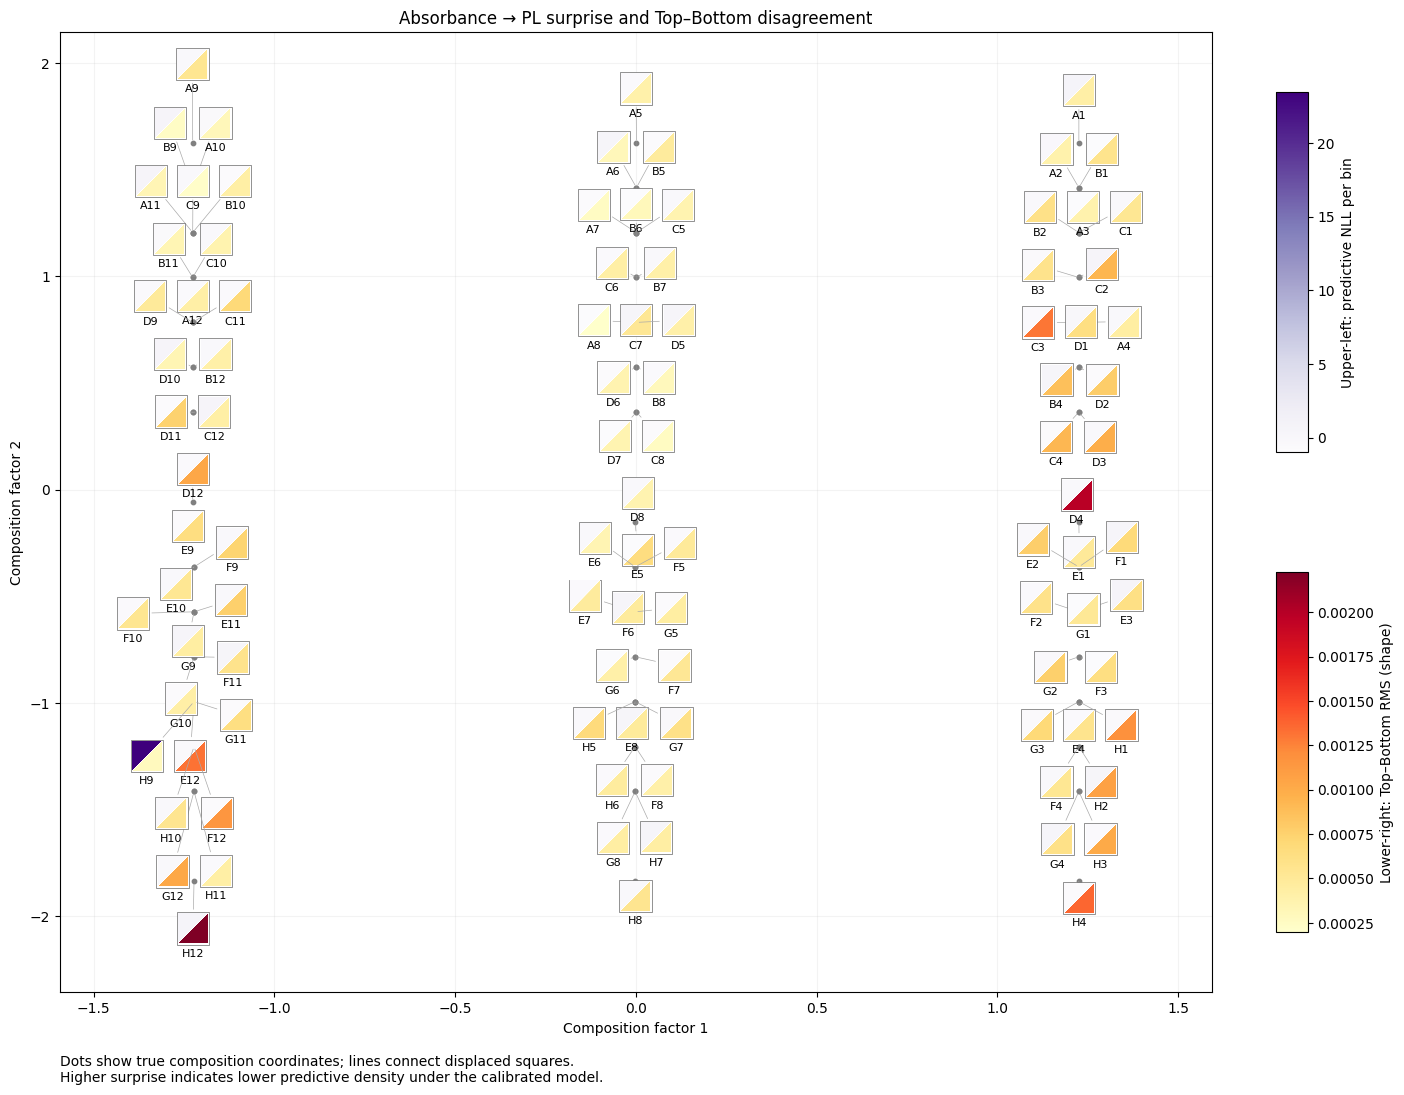

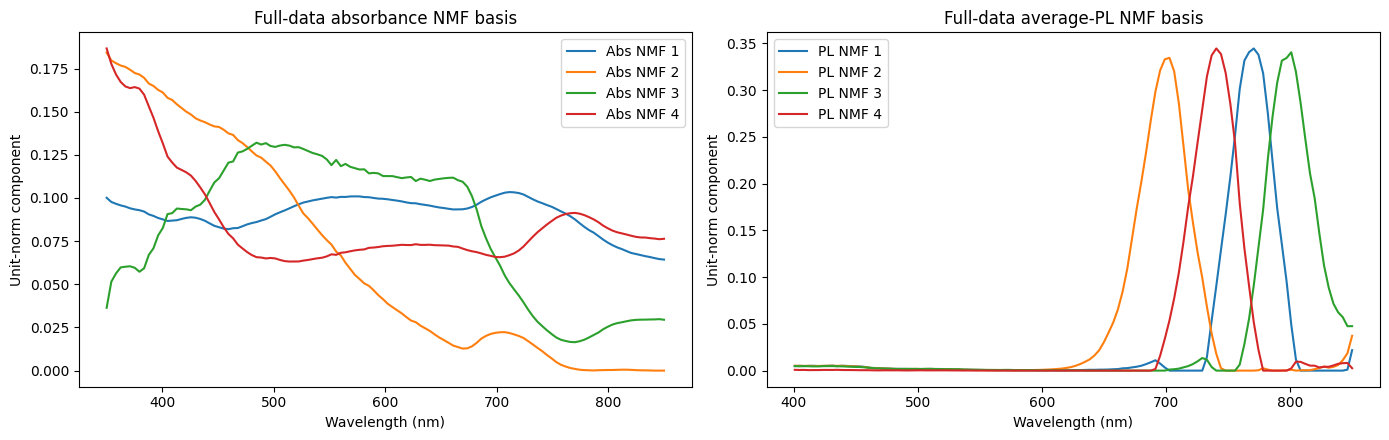

Regression coefficients between standardized NMF scores:


,Abs NMF 1,Abs NMF 2,Abs NMF 3,Abs NMF 4
PL NMF 1,0.509,0.203,-0.395,0.234
PL NMF 2,-0.721,-0.361,0.431,-0.323
PL NMF 3,0.468,-0.122,-0.606,0.502
PL NMF 4,0.122,0.450,0.362,-0.243


In [21]:
# ================================================================
# Absorbance -> average PL through NMF components
# Uses existing:
#   quaternary_composition
#   quaternary_optical
#
# All predictive results are out of sample.
# NMF bases and regression are fitted on training wells only.
# Calibration wells estimate uncertainty without refitting the model.
# ================================================================

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.linalg import solve_triangular
from sklearn.decomposition import NMF, PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.covariance import LedoitWolf
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from IPython.display import display

# --------------------------- Controls -----------------------------
PL_MODE = "shape"               # "shape" or "intensity"
BASELINE_CORRECT_PL = True      # heuristic fifth-percentile subtraction
ABS_NEGATIVE_POLICY = "error"   # "error" or "clip"; clipping is explicit
N_ABS_COMPONENTS = 4
N_PL_COMPONENTS = 4
RIDGE_ALPHA = 10.0              # fixed, not selected using test wells
N_FOLDS = 5
CALIBRATION_FRACTION = 0.25
GRID_POINTS = 120
RANDOM_STATE = 42
N_EXAMPLES = 4

COMPOSITION_COLUMNS = [
    "FA_fraction", "Cs_fraction", "Rb_fraction", "DMA_fraction",
    "I_fraction", "Br_fraction", "Cl_fraction",
]
SIGNAL_COLUMN = "optical_signal_instrument_units"

if PL_MODE not in {"shape", "intensity"}:
    raise ValueError("PL_MODE must be 'shape' or 'intensity'.")
if ABS_NEGATIVE_POLICY not in {"error", "clip"}:
    raise ValueError("ABS_NEGATIVE_POLICY must be 'error' or 'clip'.")

# np.trapezoid is available in newer NumPy versions.
integrate = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

# ================================================================
# 1. Assemble complete spectra on shared wavelength grids
# ================================================================

composition = quaternary_composition.copy().reset_index(drop=True)
optical = quaternary_optical.copy()

required = {"well", "geometry", "wavelength_nm", SIGNAL_COLUMN}
if not required.issubset(optical.columns):
    raise ValueError(f"Missing optical columns: {required - set(optical.columns)}")
if composition["well"].duplicated().any():
    raise ValueError("Expected one composition row per well.")

composition["well"] = composition["well"].astype(str)
optical["well"] = optical["well"].astype(str)
optical["wavelength_nm"] = pd.to_numeric(
    optical["wavelength_nm"], errors="coerce"
)
optical[SIGNAL_COLUMN] = pd.to_numeric(
    optical[SIGNAL_COLUMN], errors="coerce"
)

def wavelength_range(geometry):
    rows = optical.loc[optical["geometry"].eq(geometry)]
    wavelengths = rows["wavelength_nm"].dropna().to_numpy()
    if len(np.unique(wavelengths)) < 2:
        raise ValueError(f"Insufficient wavelengths for {geometry}.")
    return wavelengths.min(), wavelengths.max()

top_range = wavelength_range("Top")
bottom_range = wavelength_range("Bottom")
abs_range = wavelength_range("Absorbance")

pl_lo = max(top_range[0], bottom_range[0])
pl_hi = min(top_range[1], bottom_range[1])
if pl_hi <= pl_lo:
    raise ValueError("Top and Bottom PL have no common wavelength interval.")

pl_grid = np.linspace(pl_lo, pl_hi, GRID_POINTS)
abs_grid = np.linspace(*abs_range, GRID_POINTS)

def read_spectrum(well, geometry, grid):
    rows = optical.loc[
        optical["well"].eq(well) & optical["geometry"].eq(geometry)
    ]
    series = (
        rows.groupby("wavelength_nm")[SIGNAL_COLUMN]
        .mean().sort_index()
    )
    wavelengths = series.index.to_numpy(float)
    values = series.to_numpy(float)

    # Reject incomplete records rather than interpolate across missing values.
    if (
        len(values) < 2
        or not np.isfinite(wavelengths).all()
        or not np.isfinite(values).all()
        or wavelengths[0] > grid[0]
        or wavelengths[-1] < grid[-1]
    ):
        return None

    return np.interp(grid, wavelengths, values)

kept_indices, excluded, abs_rows, top_rows, bottom_rows = [], [], [], [], []

for index, row in composition.iterrows():
    well = row["well"]
    a = read_spectrum(well, "Absorbance", abs_grid)
    t = read_spectrum(well, "Top", pl_grid)
    b = read_spectrum(well, "Bottom", pl_grid)

    if a is None or t is None or b is None:
        excluded.append((well, "Missing/nonfinite/incomplete spectral coverage"))
        continue

    if BASELINE_CORRECT_PL:
        t = t - np.percentile(t, 5)
        b = b - np.percentile(b, 5)
    t, b = np.clip(t, 0, None), np.clip(b, 0, None)

    if integrate(t, pl_grid) <= 0 or integrate(b, pl_grid) <= 0:
        excluded.append((well, "Zero corrected PL area"))
        continue

    kept_indices.append(index)
    abs_rows.append(a)
    top_rows.append(t)
    bottom_rows.append(b)

if not kept_indices:
    raise ValueError("No complete wells remain.")

composition = composition.loc[kept_indices].reset_index(drop=True)
A = np.asarray(abs_rows)
T_raw = np.asarray(top_rows)
B_raw = np.asarray(bottom_rows)
wells = composition["well"].to_numpy()
n = len(wells)

negative_abs = int(np.sum(A < 0))
if negative_abs:
    if ABS_NEGATIVE_POLICY == "error":
        raise ValueError(
            f"Absorbance contains {negative_abs} negative entries. "
            "NMF requires nonnegative inputs. Inspect baseline/calibration, "
            "or explicitly set ABS_NEGATIVE_POLICY='clip'."
        )
    warnings.warn(f"Clipping {negative_abs} negative absorbance entries.")
    A = np.clip(A, 0, None)

top_area = integrate(T_raw, pl_grid, axis=1)
bottom_area = integrate(B_raw, pl_grid, axis=1)

if PL_MODE == "shape":
    # Normalize each geometry separately before taking the average.
    T = T_raw / top_area[:, None]
    B = B_raw / bottom_area[:, None]
else:
    # Requires comparable Top/Bottom acquisition settings.
    T, B = T_raw.copy(), B_raw.copy()

P = (T + B) / 2

# Quadrature weights: wavelength-weighted RMS and probability coordinates.
def quadrature_weights(grid):
    steps = np.diff(grid)
    weights = np.empty(len(grid))
    weights[0], weights[-1] = steps[0] / 2, steps[-1] / 2
    weights[1:-1] = (steps[:-1] + steps[1:]) / 2
    return weights / weights.sum()

pl_weights = quadrature_weights(pl_grid)
sqrt_weights = np.sqrt(pl_weights)

# Group identical nominal compositions to prevent replicate leakage.
C = composition[COMPOSITION_COLUMNS].to_numpy(float)
if not np.isfinite(C).all():
    raise ValueError("Composition contains nonfinite values.")

groups = pd.factorize(
    pd.MultiIndex.from_frame(
        composition[COMPOSITION_COLUMNS].round(10)
    )
)[0]

n_groups = len(np.unique(groups))
if n_groups < N_FOLDS:
    raise ValueError("Too few distinct compositions for N_FOLDS.")

print(f"Included wells: {n}; distinct composition groups: {n_groups}")
print(f"Excluded wells: {len(excluded)}")
print(f"PL interval: {pl_lo:.1f}–{pl_hi:.1f} nm")
print(f"PL mode: {PL_MODE}")
if excluded:
    display(pd.DataFrame(excluded, columns=["well", "reason"]))

# ================================================================
# 2. NMF -> regression -> NMF reconstruction
# ================================================================

def make_nmf(k, seed):
    return NMF(
        n_components=k,
        init="nndsvda",
        solver="cd",
        max_iter=3000,
        tol=1e-5,
        random_state=seed,
    )

def fit_pipeline(a_train, p_train, seed):
    if min(len(a_train), a_train.shape[1]) < N_ABS_COMPONENTS:
        raise ValueError("Too many absorbance components for training size.")
    if min(len(p_train), p_train.shape[1]) < N_PL_COMPONENTS:
        raise ValueError("Too many PL components for training size.")

    # One global scale per channel preserves relative spectral amplitudes.
    a_scale = max(float(np.mean(a_train)), 1e-12)
    p_scale = max(float(np.mean(p_train)), 1e-12)

    abs_nmf = make_nmf(N_ABS_COMPONENTS, seed)
    pl_nmf = make_nmf(N_PL_COMPONENTS, seed + 1)

    wa = abs_nmf.fit_transform(a_train / a_scale)
    wp = pl_nmf.fit_transform(p_train / p_scale)

    # Canonicalize basis amplitudes: NMF scaling is otherwise arbitrary.
    for model, coefficients in [(abs_nmf, wa), (pl_nmf, wp)]:
        norms = np.maximum(np.linalg.norm(model.components_, axis=1), 1e-12)
        model.components_ /= norms[:, None]
        coefficients *= norms[None, :]

    input_scaler = StandardScaler().fit(wa)
    output_scaler = StandardScaler().fit(wp)
    regressor = Ridge(alpha=RIDGE_ALPHA).fit(
        input_scaler.transform(wa),
        output_scaler.transform(wp),
    )

    return {
        "abs_nmf": abs_nmf, "pl_nmf": pl_nmf,
        "input_scaler": input_scaler,
        "output_scaler": output_scaler,
        "regressor": regressor,
        "a_scale": a_scale, "p_scale": p_scale,
    }

def predict_pipeline(model, a):
    wa = model["abs_nmf"].transform(a / model["a_scale"])
    wp_unconstrained = model["output_scaler"].inverse_transform(
        model["regressor"].predict(
            model["input_scaler"].transform(wa)
        )
    )
    # Projection to the nonnegative PL coefficient cone.
    wp = np.maximum(wp_unconstrained, 0)
    p_prediction = wp @ model["pl_nmf"].components_ * model["p_scale"]
    return p_prediction, wa, wp, wp_unconstrained

# ================================================================
# 3. Grouped out-of-sample validation and uncertainty calibration
# ================================================================

oof_prediction = np.full_like(P, np.nan)
oof_baseline = np.full_like(P, np.nan)
oof_lower = np.full_like(P, np.nan)
oof_upper = np.full_like(P, np.nan)
oof_abs_reconstruction = np.full_like(A, np.nan)
oof_pl_reconstruction = np.full_like(P, np.nan)

surprise = np.full(n, np.nan)
mahalanobis_per_bin = np.full(n, np.nan)
calibration_percentile = np.full(n, np.nan)
fold_id = np.full(n, -1)
fold_records = []
fold_models = []

outer = GroupKFold(n_splits=N_FOLDS)

for fold, (development, test) in enumerate(
    outer.split(A, P, groups), start=1
):
    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=CALIBRATION_FRACTION,
        random_state=RANDOM_STATE + fold,
    )
    train_local, calibration_local = next(
        splitter.split(
            A[development], groups=groups[development]
        )
    )
    train = development[train_local]
    calibration = development[calibration_local]

    if len(calibration) < 5:
        raise ValueError("Too few calibration wells; change split settings.")

    model = fit_pipeline(A[train], P[train], RANDOM_STATE + fold)
    pred_cal, _, _, _ = predict_pipeline(model, A[calibration])
    pred_test, wa_test, _, unconstrained = predict_pipeline(model, A[test])

    # Residual distribution in common, wavelength-weighted coordinates.
    # Scale is learned from training PL only.
    target_scale = max(
        np.sqrt(np.mean((P[train] * sqrt_weights) ** 2)), 1e-12
    )
    residual_cal = (
        (P[calibration] - pred_cal) * sqrt_weights / target_scale
    )
    residual_test = (
        (P[test] - pred_test) * sqrt_weights / target_scale
    )

    covariance_model = LedoitWolf().fit(residual_cal)
    covariance = covariance_model.covariance_
    jitter = max(float(np.trace(covariance) / GRID_POINTS), 1e-12) * 1e-8
    covariance = covariance + jitter * np.eye(GRID_POINTS)
    chol = np.linalg.cholesky(covariance)
    residual_mean = covariance_model.location_

    def gaussian_scores(residuals):
        centered = residuals - residual_mean
        whitened = solve_triangular(
            chol, centered.T, lower=True
        ).T
        distance_squared = np.sum(whitened**2, axis=1)
        logdet = 2 * np.log(np.diag(chol)).sum()
        nll = 0.5 * (
            GRID_POINTS * np.log(2 * np.pi)
            + logdet + distance_squared
        )
        return nll / GRID_POINTS, distance_squared / GRID_POINTS

    nll_test, distance_test = gaussian_scores(residual_test)
    nll_cal, _ = gaussian_scores(residual_cal)

    # Fold-specific reference percentile; descriptive, not a conformal p-value.
    percentiles = np.array([
        100 * np.mean(nll_cal <= value) for value in nll_test
    ])

    # 95% marginal Gaussian prediction intervals at each wavelength.
    # These are not simultaneous confidence bands.
    sigma = np.sqrt(np.diag(covariance))
    mean_correction = residual_mean * target_scale / sqrt_weights
    sigma_spectrum = sigma * target_scale / sqrt_weights
    calibrated_center = pred_test + mean_correction
    lower = calibrated_center - 1.96 * sigma_spectrum
    upper = calibrated_center + 1.96 * sigma_spectrum

    oof_prediction[test] = pred_test
    oof_baseline[test] = np.mean(P[train], axis=0)
    oof_lower[test], oof_upper[test] = lower, upper
    surprise[test] = nll_test
    mahalanobis_per_bin[test] = distance_test
    calibration_percentile[test] = percentiles
    fold_id[test] = fold

    oof_abs_reconstruction[test] = (
        wa_test @ model["abs_nmf"].components_ * model["a_scale"]
    )
    wp_observed = model["pl_nmf"].transform(P[test] / model["p_scale"])
    oof_pl_reconstruction[test] = (
        wp_observed @ model["pl_nmf"].components_ * model["p_scale"]
    )

    fold_records.append({
        "fold": fold,
        "training_wells": len(train),
        "calibration_wells": len(calibration),
        "test_wells": len(test),
        "negative_predicted_coefficients_%":
            100 * np.mean(unconstrained < 0),
        "covariance_shrinkage": covariance_model.shrinkage_,
    })
    fold_models.append(model)

if not np.isfinite(oof_prediction).all():
    raise RuntimeError("Some wells did not receive valid held-out predictions.")

# ================================================================
# 4. Relevant metrics
# ================================================================

def weighted_rms(array):
    return np.sqrt(np.sum(array**2 * pl_weights, axis=1))

def spectral_metrics(actual, predicted):
    residual = actual - predicted
    actual_norm = np.sqrt(np.sum(actual**2, axis=1))
    predicted_norm = np.sqrt(np.sum(predicted**2, axis=1))
    cosine = np.sum(actual * predicted, axis=1) / np.maximum(
        actual_norm * predicted_norm, 1e-15
    )
    return {
        "rmse": weighted_rms(residual),
        "mae": np.sum(np.abs(residual) * pl_weights, axis=1),
        "relative_l2": np.linalg.norm(residual, axis=1)
            / np.maximum(actual_norm, 1e-15),
        "spectral_angle_deg": np.degrees(
            np.arccos(np.clip(cosine, -1, 1))
        ),
    }

metrics = spectral_metrics(P, oof_prediction)
baseline_metrics = spectral_metrics(P, oof_baseline)
coverage = np.sum(
    ((P >= oof_lower) & (P <= oof_upper)) * pl_weights, axis=1
)
interval_width = np.sum(
    (oof_upper - oof_lower) * pl_weights, axis=1
)

# Top-Bottom measures in the selected analysis mode.
tb_rmse = weighted_rms(T - B)
tb_relative = (
    np.linalg.norm(T - B, axis=1)
    / np.maximum(
        0.5 * (np.linalg.norm(T, axis=1) + np.linalg.norm(B, axis=1)),
        1e-15,
    )
)

# Shape-only Top-Bottom disagreement remains available in either mode.
T_shape = T_raw / top_area[:, None]
B_shape = B_raw / bottom_area[:, None]
tb_shape_rmse = weighted_rms(T_shape - B_shape)

observed_centroid = (
    integrate(P * pl_grid, pl_grid, axis=1)
    / np.maximum(integrate(P, pl_grid, axis=1), 1e-15)
)
predicted_centroid = (
    integrate(oof_prediction * pl_grid, pl_grid, axis=1)
    / np.maximum(integrate(oof_prediction, pl_grid, axis=1), 1e-15)
)

results = pd.DataFrame({
    "well": wells,
    "fold": fold_id,
    "PL_prediction_RMSE": metrics["rmse"],
    "PL_prediction_MAE": metrics["mae"],
    "PL_relative_L2_error": metrics["relative_l2"],
    "PL_spectral_angle_deg": metrics["spectral_angle_deg"],
    "PL_centroid_abs_error_nm":
        np.abs(observed_centroid - predicted_centroid),
    "predictive_surprise_NLL_per_bin": surprise,
    "Mahalanobis_squared_per_bin": mahalanobis_per_bin,
    "surprise_calibration_percentile": calibration_percentile,
    "marginal_95pct_coverage": coverage,
    "mean_95pct_interval_width": interval_width,
    "Top_Bottom_RMSE": tb_rmse,
    "Top_Bottom_relative_L2": tb_relative,
    "Top_Bottom_shape_RMSE": tb_shape_rmse,
    "Top_Bottom_log10_area_ratio": np.log10(top_area / bottom_area),
    "abs_NMF_relative_reconstruction_error":
        np.linalg.norm(A - oof_abs_reconstruction, axis=1)
        / np.maximum(np.linalg.norm(A, axis=1), 1e-15),
    "PL_NMF_relative_reconstruction_error":
        np.linalg.norm(P - oof_pl_reconstruction, axis=1)
        / np.maximum(np.linalg.norm(P, axis=1), 1e-15),
})

# Global spectral R² uses a wavelength-dependent mean reference.
sse = np.sum((P - oof_prediction)**2 * pl_weights)
sst = np.sum((P - P.mean(axis=0))**2 * pl_weights)
baseline_sse = np.sum((P - oof_baseline)**2 * pl_weights)

summary = pd.Series({
    "Wells": n,
    "Mean prediction RMSE": metrics["rmse"].mean(),
    "Median prediction relative L2 error": np.median(metrics["relative_l2"]),
    "Mean spectral angle (degrees)": metrics["spectral_angle_deg"].mean(),
    "Mean centroid absolute error (nm)":
        results["PL_centroid_abs_error_nm"].mean(),
    "Global spectral R²": 1 - sse / sst if sst > 0 else np.nan,
    "MSE skill vs training-mean spectrum":
        1 - sse / baseline_sse if baseline_sse > 0 else np.nan,
    "Mean baseline RMSE": baseline_metrics["rmse"].mean(),
    "Mean marginal 95% coverage": coverage.mean(),
    "Mean marginal interval width": interval_width.mean(),
    "Median absorbance NMF relative reconstruction error":
        results["abs_NMF_relative_reconstruction_error"].median(),
    "Median PL NMF relative reconstruction error":
        results["PL_NMF_relative_reconstruction_error"].median(),
    "Mean predictive NLL per bin": surprise.mean(),
    "Median Top–Bottom relative disagreement": np.median(tb_relative),
}, name="value")

print("\nOUT-OF-SAMPLE SUMMARY")
display(summary.to_frame().round(5))
display(pd.DataFrame(fold_records).round(4))

print("\nHighest predictive-surprise wells:")
display(
    results.sort_values(
        "predictive_surprise_NLL_per_bin", ascending=False
    ).head(10).round(5)
)

print("\nLargest Top–Bottom disagreement:")
display(
    results.sort_values("Top_Bottom_RMSE", ascending=False)
    .head(10).round(5)
)

# ================================================================
# 5. Prediction diagnostics
# ================================================================

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0, 0].scatter(
    baseline_metrics["rmse"], metrics["rmse"], c=fold_id, cmap="tab10"
)
limit = max(baseline_metrics["rmse"].max(), metrics["rmse"].max())
axes[0, 0].plot([0, limit], [0, limit], "k--")
axes[0, 0].set(
    xlabel="Training-mean baseline RMSE",
    ylabel="NMF → ridge prediction RMSE",
    title="Below diagonal: improvement over baseline",
)

axes[0, 1].scatter(
    results["PL_NMF_relative_reconstruction_error"],
    metrics["relative_l2"], alpha=0.8
)
axes[0, 1].set(
    xlabel="Held-out PL NMF reconstruction error",
    ylabel="Absorbance → PL prediction error",
    title="Representation limitation versus mapping error",
)

axes[1, 0].scatter(surprise, tb_rmse, alpha=0.8)
axes[1, 0].set(
    xlabel="Predictive surprise: Gaussian NLL per bin",
    ylabel=f"Top–Bottom RMS disagreement ({PL_MODE})",
    title="The two proposed optical scalars",
)

axes[1, 1].plot(
    pl_grid,
    np.mean((P >= oof_lower) & (P <= oof_upper), axis=0),
)
axes[1, 1].axhline(0.95, color="black", ls="--")
axes[1, 1].set(
    xlabel="Wavelength (nm)",
    ylabel="Held-out marginal coverage",
    ylim=(0, 1.02),
    title="Calibration of nominal 95% prediction intervals",
)
plt.tight_layout()
plt.show()

# Highest-surprise examples.
example_indices = np.argsort(surprise)[::-1][:min(N_EXAMPLES, n)]
fig, axes = plt.subplots(
    len(example_indices), 3,
    figsize=(16, 3.3 * len(example_indices)),
    squeeze=False,
)

for row, i in enumerate(example_indices):
    axes[row, 0].plot(abs_grid, A[i], color="#6d28d9")
    axes[row, 0].set(
        title=f"{wells[i]} — absorbance",
        xlabel="Wavelength (nm)", ylabel="Instrument signal",
    )

    axes[row, 1].fill_between(
        pl_grid, oof_lower[i], oof_upper[i],
        alpha=0.2, color="#2563eb",
        label="Calibrated 95% marginal interval",
    )
    axes[row, 1].plot(pl_grid, P[i], "k", label="Observed average PL")
    axes[row, 1].plot(
        pl_grid, oof_prediction[i], color="#2563eb",
        label="Held-out NMF → ridge prediction",
    )
    axes[row, 1].set(
        title=f"Surprise = {surprise[i]:.3f} NLL/bin",
        xlabel="Wavelength (nm)", ylabel=f"PL ({PL_MODE})",
    )
    axes[row, 1].legend(fontsize=8)

    axes[row, 2].plot(pl_grid, T[i], label="Top")
    axes[row, 2].plot(pl_grid, B[i], label="Bottom")
    axes[row, 2].set(
        title=f"Top–Bottom RMS = {tb_rmse[i]:.4g}",
        xlabel="Wavelength (nm)", ylabel=f"PL ({PL_MODE})",
    )
    axes[row, 2].legend()

plt.tight_layout()
plt.show()

# ================================================================
# 6. Diagonal-square composition map
# Uses previous FA scores when available, otherwise composition PCA.
# ================================================================

previous_scores = globals().get("scores")
previous_composition = globals().get("quaternary_composition")

if (
    previous_scores is not None
    and np.asarray(previous_scores).ndim == 2
    and np.asarray(previous_scores).shape[1] >= 2
    and len(previous_scores) == len(previous_composition)
):
    coordinates_by_well = pd.DataFrame(
        np.asarray(previous_scores)[:, :2],
        index=previous_composition["well"].astype(str),
        columns=["x", "y"],
    )
    xy = coordinates_by_well.loc[wells].to_numpy()
    axis_labels = ["Composition factor 1", "Composition factor 2"]
else:
    active = np.std(C, axis=0) > 1e-12
    if active.sum() < 2:
        raise ValueError("Need two varying composition variables for the map.")
    composition_pca = PCA(n_components=2)
    xy = composition_pca.fit_transform(
        StandardScaler().fit_transform(C[:, active])
    )
    axis_labels = ["Composition PC1", "Composition PC2"]

def safe_norm(values):
    lo, hi = float(np.min(values)), float(np.max(values))
    if hi <= lo:
        hi = lo + max(abs(lo), 1) * 1e-6
    return Normalize(lo, hi)

surprise_norm = safe_norm(surprise)
tb_norm = safe_norm(tb_rmse)
surprise_cmap = plt.get_cmap("Purples")
tb_cmap = plt.get_cmap("YlOrRd")

def split_square(i, size=30):
    # Array top-left = surprise; bottom-right = Top–Bottom disagreement.
    rr, cc = np.indices((size, size))
    upper_left = rr + cc < size - 1
    image = np.empty((size, size, 4))
    image[upper_left] = surprise_cmap(surprise_norm(surprise[i]))
    image[~upper_left] = tb_cmap(tb_norm(tb_rmse[i]))
    image[rr + cc == size - 1] = (1, 1, 1, 1)
    return image

fig, ax = plt.subplots(figsize=(16, 12), dpi=100)
fig.subplots_adjust(left=0.08, right=0.80, bottom=0.10, top=0.90)

span = np.maximum(np.ptp(xy, axis=0), 1e-6)
ax.set_xlim(xy[:, 0].min() - 0.15*span[0],
            xy[:, 0].max() + 0.15*span[0])
ax.set_ylim(xy[:, 1].min() - 0.15*span[1],
            xy[:, 1].max() + 0.15*span[1])
ax.set(
    xlabel=axis_labels[0], ylabel=axis_labels[1],
    title="Absorbance → PL surprise and Top–Bottom disagreement",
)
ax.grid(alpha=0.15)
ax.scatter(xy[:, 0], xy[:, 1], s=10, c="gray")
fig.canvas.draw()

anchors = ax.transData.transform(xy)
positions = anchors.copy()
positions += np.random.default_rng(0).normal(0, 0.5, positions.shape)
bounds = ax.get_window_extent()
box_width, box_height = 42, 57

# Screen-space collision handling; labels included in box height.
for iteration in range(1500):
    moves = np.zeros_like(positions)
    collisions = 0
    for i in range(n):
        for j in range(i + 1, n):
            delta = positions[j] - positions[i]
            ox = box_width - abs(delta[0])
            oy = box_height - abs(delta[1])
            if ox > 0 and oy > 0:
                collisions += 1
                direction = 0 if ox < oy else 1
                overlap = ox if direction == 0 else oy
                sign = 1 if delta[direction] >= 0 else -1
                moves[i, direction] -= sign * (overlap + 1) * 0.52
                moves[j, direction] += sign * (overlap + 1) * 0.52
    if collisions == 0:
        break
    positions += np.clip(moves, -10, 10)
    positions[:, 0] = np.clip(
        positions[:, 0], bounds.x0 + box_width/2,
        bounds.x1 - box_width/2,
    )
    positions[:, 1] = np.clip(
        positions[:, 1], bounds.y0 + box_height/2,
        bounds.y1 - box_height/2,
    )

displaced_xy = ax.transData.inverted().transform(positions)

for i, well in enumerate(wells):
    ax.add_artist(AnnotationBbox(
        OffsetImage(
            split_square(i), zoom=1,
            origin="upper", dpi_cor=False,
        ),
        xy=xy[i], xybox=displaced_xy[i],
        xycoords="data", boxcoords="data",
        frameon=True, pad=0.08,
        bboxprops={"edgecolor": "#666666", "linewidth": 0.5},
        arrowprops={"arrowstyle": "-", "color": "#aaaaaa", "lw": 0.5},
    ))
    ax.annotate(
        well, displaced_xy[i], xytext=(0, -20),
        textcoords="offset pixels",
        ha="center", va="top", fontsize=8,
    )

cax1 = fig.add_axes([0.84, 0.55, 0.02, 0.30])
fig.colorbar(
    ScalarMappable(norm=surprise_norm, cmap=surprise_cmap), cax=cax1
).set_label("Upper-left: predictive NLL per bin")

cax2 = fig.add_axes([0.84, 0.15, 0.02, 0.30])
fig.colorbar(
    ScalarMappable(norm=tb_norm, cmap=tb_cmap), cax=cax2
).set_label(f"Lower-right: Top–Bottom RMS ({PL_MODE})")

fig.text(
    0.08, 0.025,
    "Dots show true composition coordinates; lines connect displaced squares.\n"
    "Higher surprise indicates lower predictive density under the calibrated model.",
    fontsize=10,
)
plt.show()

remaining_overlaps = sum(
    abs(positions[j, 0] - positions[i, 0]) < box_width
    and abs(positions[j, 1] - positions[i, 1]) < box_height
    for i in range(n) for j in range(i + 1, n)
)
if remaining_overlaps:
    print(f"{remaining_overlaps} square pairs overlap; enlarge the map.")

# ================================================================
# 7. Full-data descriptive model: interpretable NMF bases
# This model is for inspecting bases and future predictions.
# Reported validation metrics above still use held-out predictions.
# ================================================================

final_model = fit_pipeline(A, P, RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for k, component in enumerate(final_model["abs_nmf"].components_):
    axes[0].plot(abs_grid, component, label=f"Abs NMF {k+1}")
for k, component in enumerate(final_model["pl_nmf"].components_):
    axes[1].plot(pl_grid, component, label=f"PL NMF {k+1}")

axes[0].set(
    title="Full-data absorbance NMF basis",
    xlabel="Wavelength (nm)", ylabel="Unit-norm component",
)
axes[1].set(
    title="Full-data average-PL NMF basis",
    xlabel="Wavelength (nm)", ylabel="Unit-norm component",
)
for axis in axes:
    axis.legend()
plt.tight_layout()
plt.show()

mapping_coefficients = pd.DataFrame(
    final_model["regressor"].coef_,
    index=[f"PL NMF {k+1}" for k in range(N_PL_COMPONENTS)],
    columns=[f"Abs NMF {k+1}" for k in range(N_ABS_COMPONENTS)],
)
print("Regression coefficients between standardized NMF scores:")
display(mapping_coefficients.round(3))

# Optional local Colab export:
# results.to_csv("NMF_absorbance_to_PL_per_well_metrics.csv", index=False)

# Available for subsequent interactive visualization:
# results, summary, final_model, fold_models
# A, T, B, P, abs_grid, pl_grid, xy
# oof_prediction, oof_lower, oof_upper

NOw, let's see if there is optimal presentation. Find cross-section fo which variation strongest

In [22]:
# ================================================================
# Original concentration coordinates with the same optical squares
# Run after the NMF prediction cell.
# ================================================================

import ipywidgets as widgets
from IPython.display import display, clear_output

# Enable widgets when running in Google Colab.
try:
    from google.colab import output as colab_output
    colab_output.enable_custom_widget_manager()
except ImportError:
    pass

available_columns = [
    c for c in COMPOSITION_COLUMNS
    if c in composition.columns
]

x_control = widgets.Dropdown(
    options=available_columns,
    value="Br_fraction" if "Br_fraction" in available_columns
          else available_columns[0],
    description="Horizontal:",
    style={"description_width": "initial"},
)
y_control = widgets.Dropdown(
    options=available_columns,
    value="Cs_fraction" if "Cs_fraction" in available_columns
          else available_columns[1],
    description="Vertical:",
    style={"description_width": "initial"},
)
displace_control = widgets.Checkbox(
    value=True,
    description="Separate overlapping squares",
    indent=False,
)
plot_output = widgets.Output()

def plot_concentration_grid(x_column, y_column, displace=True):
    # Explicitly align composition rows with the prediction results.
    aligned = composition.set_index("well").loc[results["well"]]
    coordinates = aligned[[x_column, y_column]].to_numpy(float)
    labels = results["well"].to_numpy()
    count = len(labels)

    fig, ax = plt.subplots(figsize=(16, 12), dpi=100)
    fig.subplots_adjust(
        left=0.09, right=0.79, bottom=0.11, top=0.90
    )

    for dimension, setter in enumerate([ax.set_xlim, ax.set_ylim]):
        values = coordinates[:, dimension]
        span = np.ptp(values)
        padding = 0.12 * span if span > 0 else 0.05
        setter(values.min() - padding, values.max() + padding)

    ax.set_xlabel(x_column.replace("_", " "), fontsize=13)
    ax.set_ylabel(y_column.replace("_", " "), fontsize=13)
    ax.set_title(
        "Optical behavior in original concentration coordinates\n"
        "Upper-left: absorption → PL surprise | "
        "Lower-right: Top–Bottom disagreement",
        fontsize=15,
    )
    ax.grid(alpha=0.2)
    ax.set_axisbelow(True)
    ax.scatter(
        coordinates[:, 0], coordinates[:, 1],
        s=14, color="#374151", zorder=2,
    )
    fig.canvas.draw()

    anchors = ax.transData.transform(coordinates)
    positions = anchors.copy()
    box_width, box_height = 42, 57
    bounds = ax.get_window_extent()

    if displace:
        positions += np.random.default_rng(0).normal(
            0, 0.5, positions.shape
        )

        for iteration in range(1500):
            moves = np.zeros_like(positions)
            collisions = 0

            for i in range(count):
                for j in range(i + 1, count):
                    delta = positions[j] - positions[i]
                    overlap_x = box_width - abs(delta[0])
                    overlap_y = box_height - abs(delta[1])

                    if overlap_x > 0 and overlap_y > 0:
                        collisions += 1
                        direction = 0 if overlap_x < overlap_y else 1
                        overlap = (
                            overlap_x if direction == 0 else overlap_y
                        )
                        sign = 1 if delta[direction] >= 0 else -1
                        step = sign * (overlap + 1) * 0.52
                        moves[i, direction] -= step
                        moves[j, direction] += step

            if collisions == 0:
                break

            positions += np.clip(moves, -10, 10)
            positions[:, 0] = np.clip(
                positions[:, 0],
                bounds.x0 + box_width / 2,
                bounds.x1 - box_width / 2,
            )
            positions[:, 1] = np.clip(
                positions[:, 1],
                bounds.y0 + box_height / 2,
                bounds.y1 - box_height / 2,
            )

    square_coordinates = ax.transData.inverted().transform(positions)

    for i, well in enumerate(labels):
        ax.add_artist(AnnotationBbox(
            OffsetImage(
                split_square(i), zoom=1,
                origin="upper", dpi_cor=False,
            ),
            xy=coordinates[i],
            xybox=square_coordinates[i],
            xycoords="data",
            boxcoords="data",
            frameon=True,
            pad=0.08,
            bboxprops={
                "edgecolor": "#666666", "linewidth": 0.5,
            },
            arrowprops={
                "arrowstyle": "-", "color": "#999999", "lw": 0.6,
            } if displace else None,
            zorder=3,
        ))
        ax.annotate(
            well, square_coordinates[i],
            xytext=(0, -20),
            textcoords="offset pixels",
            ha="center", va="top", fontsize=8,
            zorder=4,
        )

    # Reuse the original normalization: colors remain comparable
    # across factor-space and concentration-space maps.
    cax1 = fig.add_axes([0.84, 0.55, 0.02, 0.30])
    fig.colorbar(
        ScalarMappable(norm=surprise_norm, cmap=surprise_cmap),
        cax=cax1,
    ).set_label("Upper-left: predictive NLL per bin")

    cax2 = fig.add_axes([0.84, 0.15, 0.02, 0.30])
    fig.colorbar(
        ScalarMappable(norm=tb_norm, cmap=tb_cmap),
        cax=cax2,
    ).set_label(f"Lower-right: Top–Bottom RMS ({PL_MODE})")

    duplicate_count = count - len(np.unique(coordinates, axis=0))
    fig.text(
        0.09, 0.025,
        "Dots mark actual concentrations; lines connect displaced squares.\n"
        f"{duplicate_count} wells share coordinates with another well "
        "in this two-variable projection.",
        fontsize=10,
    )
    plt.show()
    plt.close(fig)

    remaining = sum(
        abs(positions[j, 0] - positions[i, 0]) < box_width
        and abs(positions[j, 1] - positions[i, 1]) < box_height
        for i in range(count) for j in range(i + 1, count)
    )
    if remaining:
        print(
            f"{remaining} square pairs overlap. "
            "Enable separation or increase the figure size."
        )

def update_concentration_plot(change=None):
    with plot_output:
        clear_output(wait=True)
        if x_control.value == y_control.value:
            print("Choose different horizontal and vertical variables.")
            return
        plot_concentration_grid(
            x_control.value,
            y_control.value,
            displace_control.value,
        )

for control in [x_control, y_control, displace_control]:
    control.observe(update_concentration_plot, names="value")

display(widgets.VBox([
    widgets.HBox([x_control, y_control]),
    displace_control,
    plot_output,
]))
update_concentration_plot()

# <font color="red">Challenge 2 — RP-Additive System</font>

### Your task

Improve the baseline so a new user can connect host composition, MACl design level,
time, wavelength, and measurement geometry more quickly or more accurately.

### Possible solutions

- add a time control or animation with a fixed color scale;
- compare Top and Bottom measurements directly;
- encode final − initial change or show a trajectory through time;
- create a wavelength-first composition map;
- link a composition selection to its full spectral history.

### Scientific question

> Where does a spectral feature change, when does it change, and what composition
> context makes that trend understandable?

### Minimum deliverable

One readable visualization, one time-resolved spectral view, one sentence describing
the insight, and one sentence naming a possible misinterpretation.


In [16]:
# ============================================================
# YOUR CODE STARTS HERE — Challenge 2
# ============================================================

CHALLENGE2_MEASURE = "Bottom PL"
CHALLENGE2_TIME_MIN = 380
CHALLENGE2_METRIC = "red_fraction_760_820"
CHALLENGE2_WELL = "H7"

# Start from this working baseline, then replace or extend it.
challenge2_figures = [
    rp_composition_map(
        CHALLENGE2_MEASURE, CHALLENGE2_TIME_MIN,
        CHALLENGE2_METRIC, CHALLENGE2_WELL,
    ),
    rp_time_wavelength(CHALLENGE2_WELL, CHALLENGE2_MEASURE),
]

# Ideas: compare geometries, add a time control, encode two metrics,
# or replace both panels with one more integrated representation.

# ============================================================
# YOUR CODE ENDS HERE
# ============================================================
show_figures(challenge2_figures)


<h2><font color="purple">4.</font> Build, Test, and Explain Your Design</h2>

Use a **60-second usability test**: hand the visualization to someone from another team
and ask them to answer your scientific question without coaching.

Score one point for each:

1. **Dimensional fidelity:** important variables are shown, encoded, or selectable.
2. **Overview + evidence:** a trend can be found and its spectra inspected.
3. **Spectral honesty:** summaries do not masquerade as phase assignments.
4. **Comparable scales + QC:** time/geometry comparisons use defensible scales, and
   low/invalid PL is visibly distinct from measured zero.
5. **One-minute usability:** a new user can answer the stated question.


In [17]:
# @title 5. Team result — edit these three fields
TEAM_NAME = "" # @param {type:"string"}
CHOSEN_CHALLENGE = "Challenge 1 — Quaternary System" # @param ["Challenge 1 — Quaternary System", "Challenge 2 — RP-Additive System"]
DESIGN_CLAIM = "" # @param {type:"string"}

TEAM_FIGURES = (
    challenge1_figures
    if CHOSEN_CHALLENGE.startswith("Challenge 1")
    else challenge2_figures
)
display(Markdown(
    f"### {TEAM_NAME or 'Unnamed team'}\n\n"
    f"**{CHOSEN_CHALLENGE}**\n\n"
    f"{DESIGN_CLAIM or 'Add one sentence explaining what became easier to see.'}"
))
show_figures(TEAM_FIGURES)


### Unnamed team

**Challenge 1 — Quaternary System**

Add one sentence explaining what became easier to see.

In [18]:
# @title 6. Export the final interactive result
safe_team = "".join(
    character if character.isalnum() or character in "-_" else "_"
    for character in (TEAM_NAME.strip() or "unnamed_team")
)
export_dir = DATA_ROOT / "team_exports"
export_dir.mkdir(exist_ok=True)
export_path = export_figure_grid(
    TEAM_FIGURES,
    export_dir / f"{safe_team}_final_visualization.html",
    f"{TEAM_NAME or 'Unnamed team'} — {CHOSEN_CHALLENGE}",
)
print("Wrote", export_path)
display(FileLink(str(export_path), result_html_prefix="Download interactive HTML: "))


Wrote /content/higher_dimensional_optical_data/team_exports/unnamed_team_final_visualization.html


/content/higher_dimensional_optical_data/team_exports/unnamed_team_final_visualization.html

# Sergei solution

# Problem 2: Latent Dynamics of Time-Resolved Photoluminescence

## Scientific objective

We want to understand how photoluminescence (PL) evolves across a composition–additive library, and whether Top and Bottom measurements reflect a common evolving optical state.

Each well is defined by two independent experimental coordinates:

- **Host composition:** the nominal 3AMP/FAPbI3 mixing fraction.
- **Additive level:** the nominal MACl design level.

The two host fractions sum to one. MACl is a separate experimental axis; its percentage denominator is undocumented.

Each well contains Top and Bottom PL spectra measured every 20 minutes from 0 to 380 minutes. We model these spectra as observations emitted from a low-dimensional state that evolves over time.

## 1. Preparing the observations

The spectra are assembled into an array with dimensions:

**well × time × measurement geometry × wavelength**

Measurements marked invalid by the notebook's quality-control metadata, containing nonfinite values, or having zero corrected spectral area are excluded from assimilation.

An optional fifth-percentile baseline subtraction is applied, followed by clipping negative values to zero. This is a preprocessing heuristic, not an instrument calibration.

Two analysis modes are available:

- **Intensity mode:** retains spectral brightness and shape.
- **Shape mode:** normalizes each spectrum by its integrated area, removing absolute brightness.

Intensity comparisons require comparable acquisition settings across times and geometries.

## 2. Learning a shared spectral emission basis

We fit nonnegative matrix factorization (NMF) to pooled Top and Bottom spectra from the training subset:

$$
P_{ig}(t,\lambda)
\approx
\sum_{k=1}^{K} a_{igk}(t)B_k(\lambda).
$$

Here:

- $P_{ig}(t,\lambda)$ is the measured spectrum for well $i$ and geometry $g$.
- $B_k(\lambda)$ is a nonnegative spectral component.
- $a_{igk}(t)$ is its nonnegative contribution to that spectrum.
- $K$ is the selected number of components; the initial implementation uses four.

Both geometries use the same basis, so their coefficients describe comparable spectral patterns. Component norms are fixed to remove the arbitrary scaling between NMF coefficients and basis spectra.

The components are **optical patterns**, not established structural phases. Their interpretation requires inspection of the loading curves and supporting measurements.

## 3. Defining the shared latent optical state

NMF coefficients are transformed using a logarithm with a small positive floor, then standardized using training observations.

We describe the resulting coefficient vectors as observations of a shared latent state:

$$
\mathbf u_{ig}(t)
=
\mathbf z_i(t)+\mathbf b_g+\boldsymbol\nu_{ig}(t).
$$

Here:

- $\mathbf z_i(t)$ is the shared evolving optical state.
- $\mathbf b_g$ is a geometry-specific offset.
- $\boldsymbol\nu_{ig}(t)$ represents observation variability and model mismatch.

The observation mapping is constrained to the identity. This keeps the latent coordinates connected to the NMF components rather than introducing an arbitrary rotation.

Top and Bottom offsets are estimated from their mean difference and constrained to sum to zero. Thus, the shared state represents their common behavior, while the offsets capture systematic geometry differences.

This first model assumes those offsets remain fixed across composition and time. Evolving geometry differences appear as residuals.

## 4. Learning composition-dependent dynamics

The latent state follows a linear stochastic transition model:

$$
\mathbf z_i(t+\Delta t)
=
F\mathbf z_i(t)+G\mathbf c_i+\mathbf d+\boldsymbol\eta_i(t).
$$

Here:

- $F$ describes temporal propagation of the state.
- $\mathbf c_i$ contains standardized host composition and nominal MACl level.
- $G$ describes the composition-dependent driving term.
- $\mathbf d$ is an intercept.
- $\boldsymbol\eta_i(t)$ represents unresolved transition variability.

The transition parameters are estimated by ridge regression using paired-observation state proxies from consecutive training times.

This is an empirical dynamical model, not a mechanistic kinetic law. Composition changes the driving term; the transition matrix $F$ is shared across wells.

Process and observation covariance matrices use shrinkage estimation for numerical stability. Their estimates include representation error and model mismatch and should not be interpreted as independently calibrated physical noise.

## 5. Estimating states and predicting spectra

A Kalman filter alternates between two operations:

1. **Prediction:** propagate the previous state and its uncertainty to the next time.
2. **Assimilation:** update that prediction using the available Top and/or Bottom observation.

Missing observations are skipped. If neither geometry is available, the state evolves through prediction alone.

Each spectral forecast is generated **before assimilating the current measurement**. Samples from the predicted log-coefficient distribution are transformed back to nonnegative NMF coefficients and reconstructed into full spectra.

These samples provide:

- The mean predicted spectrum.
- Pointwise 95% prediction intervals.

The intervals describe uncertainty conditional on the fitted model. They exclude uncertainty in the learned NMF basis and dynamics parameters and are not simultaneous confidence bands over the entire spectrum.

## 6. Measuring predictive surprise

Predictive surprise is the negative log predictive density of the current observation under its one-step forecast:

$$
S_i(t)
=
-\frac{1}{D}
\log p\!\left(
\mathbf u_{i,\mathrm{observed}}(t)
\mid
\text{earlier observations},\mathbf c_i
\right).
$$

The density is calculated in **standardized log-NMF coefficient space**, where $D$ is the number of observed coordinates.

Higher surprise means the observation was less expected under the model. It can indicate unusual evolution, geometry mismatch, measurement problems, or an inadequate model.

This is **predictive surprise**, not Bayesian prior-to-posterior information gain. Its numerical value depends on the chosen representation and can be negative because it is based on a continuous probability density.

The composition map displays surprise only when both geometries are valid, keeping the observation dimension consistent across mapped wells.

## 7. Measuring Top–Bottom disagreement

We also calculate spectral RMS disagreement:

$$
D_{\mathrm{TB},i}(t)
=
\sqrt{
\frac{1}{N_\lambda}
\sum_\lambda
\left[
P_{i,\mathrm{Top}}(t,\lambda)
-
P_{i,\mathrm{Bottom}}(t,\lambda)
\right]^2
}.
$$

In intensity mode, this includes brightness and shape differences. In shape mode, it describes differences between area-normalized spectra.

This quantity complements surprise: one measures unexpected temporal behavior, while the other measures disagreement between observation geometries.

## 8. Validation design

Identical nominal concentration pairs are kept together when splitting training and held-out wells.

The NMF basis, coefficient scaling, geometry offsets, dynamics, and covariance estimates are learned using:

- Training compositions only.
- Measurements through the selected fitting cutoff, initially 240 minutes.

Forecast metrics are reported for later measurements of held-out compositions.

The filter may assimilate the earlier history of a held-out well and then make successive one-step predictions. Therefore, this evaluates **history-conditioned forecasting for unseen compositions**, not prediction of an entire trajectory without measurements.

## 9. Reported metrics

The evaluation includes:

- **Spectral RMSE:** absolute prediction error.
- **Relative L2 error:** error relative to the observed spectral magnitude.
- **Spectral angle:** agreement in spectral shape.
- **NMF reconstruction error:** whether the spectral basis can represent held-out observations.
- **Persistence skill:** improvement over predicting that the next spectrum equals the previous spectrum.
- **Marginal interval coverage and width:** checks on predictive uncertainty.
- **Predictive negative log density:** uncertainty-aware surprise.
- **Normalized innovation squared:** discrepancy relative to the predicted covariance.

Persistence skill is defined as:

$$
\mathrm{Skill}
=
1-
\frac{
\sum \mathrm{MSE}_{\mathrm{model}}
}{
\sum \mathrm{MSE}_{\mathrm{persistence}}
}.
$$

Positive values indicate improvement over persistence. This comparison uses observations for which both methods can make predictions.

## 10. Interactive visualization

The interface links four views:

1. **Original concentration grid:** each well remains at its host-composition and MACl coordinates.
2. **Filtered latent trajectories:** state evolution with conditional uncertainty bands.
3. **Observed and predicted spectra:** current Top/Bottom measurements compared with forecasts.
4. **Time–wavelength heatmap:** the complete observed average-PL history for the selected well.

Each concentration-grid square is divided diagonally:

- **Upper-left:** predictive surprise.
- **Lower-right:** Top–Bottom RMS disagreement.

Color scales remain fixed across animation times. Gray indicates unavailable paired observations.

## Interpretation and next steps

A useful model should outperform persistence, reconstruct held-out spectral shapes, and provide reasonably calibrated uncertainty.

Large NMF reconstruction errors suggest that the spectral basis is insufficient. Large forecasting errors with good NMF reconstruction suggest that the dynamical model needs improvement. Persistent Top–Bottom residuals suggest that fixed geometry offsets may be too restrictive.

The next extensions are to compare component counts and regularization settings within training data, introduce evolving geometry-specific states, and test nonlinear or switching dynamics if the linear model cannot capture the observed trajectories.

96 wells; 20 times; 221 wavelengths; 3470 valid spectra.
Training wells: 72; held-out wells: 24.
Basis/dynamics fit through 240 min; evaluation uses later times of held-out wells.
Training transitions: 639
Transition spectral radius: 0.966

HELD-OUT COMPOSITION, LATE-TIME FORECAST METRICS


,value
Held-out late-time spectra,307.00000
Mean forecast RMSE,19609.05837
Median relative L2 error,3.91989
Mean spectral angle (degrees),18.37164
MSE skill against previous-spectrum persistence,-2760.48966
Median NMF relative reconstruction error,0.06631
Mean nominal 95% marginal coverage,0.90729
Mean prediction interval width,67208.51363
Mean paired predictive NLL per latent observation,0.55470
Mean paired normalized innovation squared,1.00953


,forecast_RMSE,relative_L2_error,marginal_95pct_coverage,NMF_relative_reconstruction_error
geometry,,,,
Bottom PL,28802.52781,8.31094,0.91642,0.22517
Top PL,8497.52696,6.72201,0.89625,0.08355


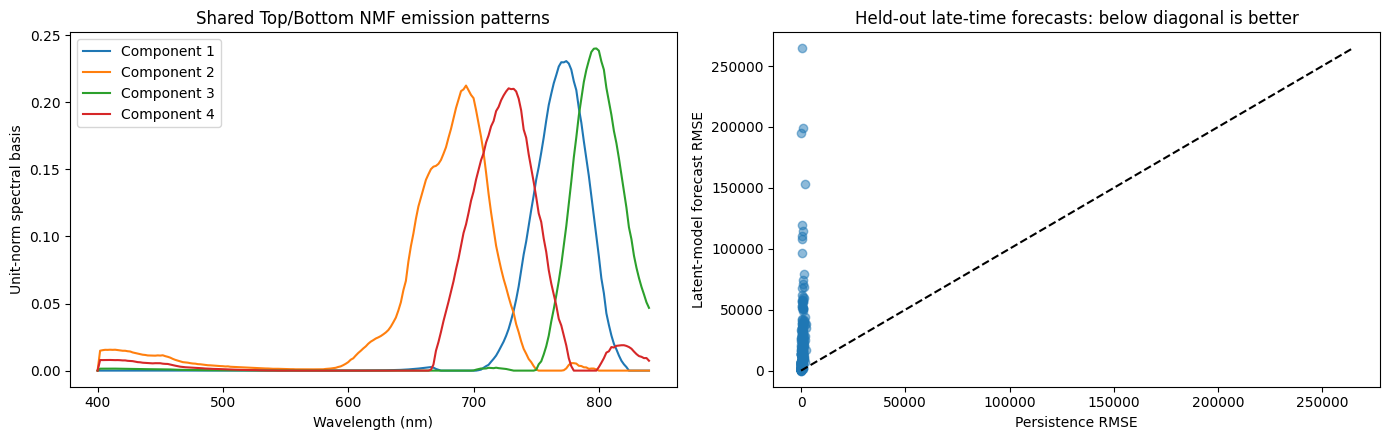

In [23]:
# ================================================================
# Problem 2: NMF emissions + shared latent state-space dynamics
#
# Existing notebook variables:
#   rp_composition, rp_features, rp_spectra
#
# Outputs:
#   rp_latent_metrics       held-out late-time prediction metrics
#   rp_latent_states        filtered states and uncertainty
#   rp_dynamics_model       fitted model parameters
#   interactive animation  composition grid + selected-well history
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets

from scipy.linalg import cho_factor, cho_solve
from sklearn.decomposition import NMF
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.covariance import LedoitWolf
from sklearn.model_selection import GroupShuffleSplit
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Polygon
from IPython.display import display, clear_output

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass

# ---------------------------- Controls -----------------------------
K = 4
MODE = "intensity"          # "intensity" or "shape"
BASELINE_CORRECT = True     # heuristic fifth-percentile subtraction
FIT_UNTIL_MIN = 240         # later times reserved for forecasting evaluation
TEST_COMPOSITION_FRACTION = 0.25
DYNAMICS_RIDGE = 10.0
MC_SAMPLES = 150
SEED = 42

if MODE not in {"intensity", "shape"}:
    raise ValueError("MODE must be 'intensity' or 'shape'.")

rng = np.random.default_rng(SEED)
trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
geometries = ["Top PL", "Bottom PL"]

# ================================================================
# 1. Build well × time × geometry × wavelength array
# ================================================================

comp = rp_composition.copy()
meta = rp_features.copy()
comp["well"] = comp["well"].astype(str)
meta["well"] = meta["well"].astype(str)

if comp["well"].duplicated().any():
    raise ValueError("Expected one composition row per well.")

wl_columns = sorted(
    [c for c in rp_spectra.columns if c.startswith("wl_")],
    key=lambda c: float(c.split("_", 1)[1]),
)
wavelengths = np.array([
    float(c.split("_", 1)[1]) for c in wl_columns
])
spectra_by_id = rp_spectra.set_index("spectrum_id")

well_names = comp["well"].to_numpy()
times = np.sort(meta["time_min"].unique().astype(float))
N, NT, L = len(well_names), len(times), len(wavelengths)

if NT < 4:
    raise ValueError("Need at least four time points.")
if not np.allclose(np.diff(times), np.diff(times)[0]):
    raise ValueError("This implementation requires equally spaced times.")

well_index = {w: i for i, w in enumerate(well_names)}
time_index = {float(t): j for j, t in enumerate(times)}

Y = np.full((N, NT, 2, L), np.nan)
seen = set()

for row in meta.itertuples(index=False):
    if row.measure not in geometries or row.well not in well_index:
        continue

    i = well_index[row.well]
    j = time_index[float(row.time_min)]
    g = geometries.index(row.measure)
    key = (i, j, g)

    if key in seen:
        raise ValueError(f"Duplicate well/time/geometry record: {key}")
    seen.add(key)

    if row.qc_status != "valid":
        continue

    signal = spectra_by_id.loc[row.spectrum_id, wl_columns].to_numpy(float)
    if not np.isfinite(signal).all():
        continue

    if BASELINE_CORRECT:
        signal = signal - np.percentile(signal, 5)
    signal = np.maximum(signal, 0)

    area = trapz(signal, wavelengths)
    if area <= 0:
        continue

    if MODE == "shape":
        signal = signal / area

    Y[i, j, g] = signal

valid = np.isfinite(Y).all(axis=-1)
early = times <= FIT_UNTIL_MIN

if early.sum() < 4 or (~early).sum() < 1:
    raise ValueError("Choose FIT_UNTIL_MIN with early and later measurements.")

# Identical concentration pairs stay in the same split.
composition_columns = ["FAPbI3_host_fraction", "additive_percent"]
C = comp[composition_columns].to_numpy(float)
if not np.isfinite(C).all():
    raise ValueError("Nonfinite composition values.")

groups = pd.factorize(
    pd.MultiIndex.from_frame(comp[composition_columns].round(10))
)[0]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_COMPOSITION_FRACTION,
    random_state=SEED,
)
train_wells, test_wells = next(splitter.split(C, groups=groups))
is_train = np.zeros(N, dtype=bool)
is_train[train_wells] = True

fit_mask = valid & is_train[:, None, None] & early[None, :, None]
fit_spectra = Y[fit_mask]

if min(fit_spectra.shape) < K:
    raise ValueError("Not enough valid training spectra for K components.")

print(
    f"{N} wells; {NT} times; {L} wavelengths; "
    f"{valid.sum()} valid spectra."
)
print(
    f"Training wells: {len(train_wells)}; "
    f"held-out wells: {len(test_wells)}."
)
print(
    f"Basis/dynamics fit through {FIT_UNTIL_MIN:g} min; "
    "evaluation uses later times of held-out wells."
)

# ================================================================
# 2. Shared NMF spectral emission basis
# ================================================================

signal_scale = max(float(fit_spectra.mean()), 1e-12)
nmf = NMF(
    n_components=K,
    init="nndsvda",
    random_state=SEED,
    max_iter=3000,
    tol=1e-5,
)
nmf.fit(fit_spectra / signal_scale)

# Fix arbitrary component scaling.
basis_norms = np.maximum(np.linalg.norm(nmf.components_, axis=1), 1e-12)
nmf.components_ /= basis_norms[:, None]

coefficients = np.full((N, NT, 2, K), np.nan)
coefficients[valid] = nmf.transform(Y[valid] / signal_scale)

training_coefficients = coefficients[fit_mask]
coefficient_floor = np.maximum(
    np.median(training_coefficients, axis=0) * 1e-4, 1e-8
)
log_coefficients = np.log(coefficients + coefficient_floor)

# Per-component normalization learned only from training observations.
latent_scaler = StandardScaler().fit(log_coefficients[fit_mask])
U = np.full_like(log_coefficients, np.nan)
U[valid] = latent_scaler.transform(log_coefficients[valid])

# Constrained observation model:
# U_top = z + offset_top + noise
# U_bottom = z + offset_bottom + noise
# Offsets sum to zero; latent coordinates inherit the NMF interpretation.
pair_fit = valid.all(axis=2) & is_train[:, None] & early[None, :]
if pair_fit.sum() < max(10, 2 * K):
    raise ValueError("Too few paired training observations.")

difference = (U[:, :, 0] - U[:, :, 1])[pair_fit]
offset_top = 0.5 * difference.mean(axis=0)
offsets = np.stack([offset_top, -offset_top])

proxy_states = 0.5 * (
    U[:, :, 0] - offsets[0] + U[:, :, 1] - offsets[1]
)

# Empirical observation covariance from geometry departures.
observation_residuals = np.concatenate([
    U[:, :, 0][pair_fit] - offsets[0] - proxy_states[pair_fit],
    U[:, :, 1][pair_fit] - offsets[1] - proxy_states[pair_fit],
], axis=1)

def regularized_covariance(samples, floor=1e-3):
    covariance = LedoitWolf().fit(samples).covariance_
    return covariance + floor * np.eye(covariance.shape[0])

R = regularized_covariance(observation_residuals)

# ================================================================
# 3. Composition-conditioned latent dynamics
# z(t+1) = F z(t) + G c + b + process noise
# ================================================================

composition_scaler = StandardScaler().fit(C[train_wells])
C_scaled = composition_scaler.transform(C)

inputs, targets = [], []
for i in train_wells:
    for j in range(NT - 1):
        if (
            early[j] and early[j + 1]
            and valid[i, j].all() and valid[i, j + 1].all()
        ):
            inputs.append(np.r_[proxy_states[i, j], C_scaled[i]])
            targets.append(proxy_states[i, j + 1])

inputs, targets = np.asarray(inputs), np.asarray(targets)
if len(inputs) < max(20, 3 * K):
    raise ValueError("Too few complete training transitions.")

dynamics = Ridge(alpha=DYNAMICS_RIDGE).fit(inputs, targets)
F = dynamics.coef_[:, :K]
G = dynamics.coef_[:, K:]
intercept = dynamics.intercept_
transition_residuals = targets - dynamics.predict(inputs)
Q = regularized_covariance(transition_residuals)

initial_samples = [
    proxy_states[i, 0] for i in train_wells if valid[i, 0].all()
]
initial_samples = np.asarray(initial_samples)
if len(initial_samples) < 3:
    raise ValueError("Too few valid training wells at the initial time.")

initial_mean = initial_samples.mean(axis=0)
initial_cov = regularized_covariance(initial_samples)

print(f"Training transitions: {len(inputs)}")
print(f"Transition spectral radius: {max(abs(np.linalg.eigvals(F))):.3f}")

rp_dynamics_model = {
    "nmf": nmf,
    "latent_scaler": latent_scaler,
    "composition_scaler": composition_scaler,
    "F": F, "G": G, "intercept": intercept,
    "Q": Q, "R": R, "geometry_offsets": offsets,
    "initial_mean": initial_mean,
    "initial_covariance": initial_cov,
    "coefficient_floor": coefficient_floor,
    "signal_scale": signal_scale,
}

# ================================================================
# 4. Kalman filtering and one-step predictive distributions
# Predict FIRST, then assimilate the current measurement.
# ================================================================

H_full = np.vstack([np.eye(K), np.eye(K)])
state_mean = np.full((N, NT, K), np.nan)
state_cov = np.full((N, NT, K, K), np.nan)
predicted_mean = np.full_like(Y, np.nan)
predicted_lower = np.full_like(Y, np.nan)
predicted_upper = np.full_like(Y, np.nan)
nll = np.full((N, NT), np.nan)
mahalanobis = np.full((N, NT), np.nan)
eye = np.eye(K)

for i in range(N):
    mean, covariance = initial_mean.copy(), initial_cov.copy()

    for j in range(NT):
        if j > 0:
            mean = F @ mean + G @ C_scaled[i] + intercept
            covariance = F @ covariance @ F.T + Q
        covariance = 0.5 * (covariance + covariance.T)

        # Predict both geometry emissions, including observation variation.
        emission_mean = H_full @ mean + offsets.ravel()
        emission_cov = H_full @ covariance @ H_full.T + R
        emission_cov = 0.5 * (emission_cov + emission_cov.T)

        draws = rng.multivariate_normal(
            emission_mean, emission_cov, size=MC_SAMPLES
        ).reshape(MC_SAMPLES, 2, K)
        log_draws = (
            draws * latent_scaler.scale_[None, None, :]
            + latent_scaler.mean_[None, None, :]
        )
        # A numerical guard for extreme unstable extrapolation.
        coefficient_draws = np.maximum(
            np.exp(np.clip(log_draws, -50, 50))
            - coefficient_floor[None, None, :],
            0,
        )
        spectral_draws = (
            coefficient_draws @ nmf.components_ * signal_scale
        )
        predicted_mean[i, j] = spectral_draws.mean(axis=0)
        predicted_lower[i, j] = np.quantile(spectral_draws, 0.025, axis=0)
        predicted_upper[i, j] = np.quantile(spectral_draws, 0.975, axis=0)

        observed_geometries = np.flatnonzero(valid[i, j])
        if len(observed_geometries):
            selected = np.concatenate([
                np.arange(g*K, (g+1)*K) for g in observed_geometries
            ])
            H = H_full[selected]
            R_current = R[np.ix_(selected, selected)]
            observation = U[i, j, observed_geometries].ravel()
            offset = offsets[observed_geometries].ravel()

            innovation = observation - (H @ mean + offset)
            S = H @ covariance @ H.T + R_current
            factor = cho_factor(S, lower=True)
            squared_distance = innovation @ cho_solve(factor, innovation)
            logdet = 2 * np.log(np.diag(factor[0])).sum()
            dimension = len(observation)

            # Density in standardized log-NMF coordinates.
            nll[i, j] = 0.5 * (
                dimension * np.log(2*np.pi)
                + logdet + squared_distance
            ) / dimension
            mahalanobis[i, j] = squared_distance / dimension

            gain = cho_solve(factor, H @ covariance).T
            mean = mean + gain @ innovation
            # Joseph update for numerical stability.
            correction = eye - gain @ H
            covariance = (
                correction @ covariance @ correction.T
                + gain @ R_current @ gain.T
            )

        state_mean[i, j] = mean
        state_cov[i, j] = 0.5 * (covariance + covariance.T)

# ================================================================
# 5. Held-out forecasting and representation metrics
# ================================================================

basis_reconstruction = np.full_like(Y, np.nan)
basis_reconstruction[valid] = (
    coefficients[valid] @ nmf.components_ * signal_scale
)

pair_valid = valid.all(axis=2)
tb_disagreement = np.sqrt(
    np.mean((Y[:, :, 0] - Y[:, :, 1])**2, axis=-1)
)
tb_disagreement[~pair_valid] = np.nan

records = []
for i in test_wells:
    for j in range(1, NT):
        if times[j] <= FIT_UNTIL_MIN:
            continue
        for g, geometry in enumerate(geometries):
            if not valid[i, j, g]:
                continue

            actual = Y[i, j, g]
            predicted = predicted_mean[i, j, g]
            residual = actual - predicted
            norm = max(np.linalg.norm(actual), 1e-15)

            cosine = np.dot(actual, predicted) / max(
                np.linalg.norm(actual) * np.linalg.norm(predicted), 1e-15
            )
            persistence_mse = np.nan
            if valid[i, j - 1, g]:
                persistence_mse = np.mean(
                    (actual - Y[i, j - 1, g])**2
                )

            records.append({
                "well": well_names[i],
                "time_min": times[j],
                "geometry": geometry,
                "forecast_MSE": np.mean(residual**2),
                "forecast_RMSE": np.sqrt(np.mean(residual**2)),
                "relative_L2_error": np.linalg.norm(residual) / norm,
                "spectral_angle_deg":
                    np.degrees(np.arccos(np.clip(cosine, -1, 1))),
                "persistence_MSE": persistence_mse,
                "NMF_relative_reconstruction_error":
                    np.linalg.norm(
                        actual - basis_reconstruction[i, j, g]
                    ) / norm,
                "marginal_95pct_coverage": np.mean(
                    (actual >= predicted_lower[i, j, g])
                    & (actual <= predicted_upper[i, j, g])
                ),
                "mean_interval_width": np.mean(
                    predicted_upper[i, j, g] - predicted_lower[i, j, g]
                ),
            })

rp_latent_metrics = pd.DataFrame(records)
if rp_latent_metrics.empty:
    raise ValueError("No valid held-out late-time observations.")

matched = rp_latent_metrics.dropna(subset=["persistence_MSE"])
persistence_skill = (
    1 - matched["forecast_MSE"].sum() / matched["persistence_MSE"].sum()
    if len(matched) and matched["persistence_MSE"].sum() > 0
    else np.nan
)

evaluation_wells = np.zeros(N, dtype=bool)
evaluation_wells[test_wells] = True
surprise_eval = (
    evaluation_wells[:, None] & (~early)[None, :] & pair_valid
)

summary = pd.Series({
    "Held-out late-time spectra": len(rp_latent_metrics),
    "Mean forecast RMSE": rp_latent_metrics["forecast_RMSE"].mean(),
    "Median relative L2 error":
        rp_latent_metrics["relative_L2_error"].median(),
    "Mean spectral angle (degrees)":
        rp_latent_metrics["spectral_angle_deg"].mean(),
    "MSE skill against previous-spectrum persistence": persistence_skill,
    "Median NMF relative reconstruction error":
        rp_latent_metrics["NMF_relative_reconstruction_error"].median(),
    "Mean nominal 95% marginal coverage":
        rp_latent_metrics["marginal_95pct_coverage"].mean(),
    "Mean prediction interval width":
        rp_latent_metrics["mean_interval_width"].mean(),
    "Mean paired predictive NLL per latent observation":
        np.nanmean(nll[surprise_eval]),
    "Mean paired normalized innovation squared":
        np.nanmean(mahalanobis[surprise_eval]),
}, name="value")

print("\nHELD-OUT COMPOSITION, LATE-TIME FORECAST METRICS")
display(summary.to_frame().round(5))
display(
    rp_latent_metrics.groupby("geometry")[
        ["forecast_RMSE", "relative_L2_error",
         "marginal_95pct_coverage", "NMF_relative_reconstruction_error"]
    ].mean().round(5)
)

# Table of all filtered states; filtering uses only history through that time.
state_records = []
for i in range(N):
    for j in range(NT):
        record = {
            "well": well_names[i],
            "time_min": times[j],
            "held_out_composition": bool(evaluation_wells[i]),
            "observed_geometries": int(valid[i, j].sum()),
            "predictive_NLL_per_coordinate": nll[i, j],
            "normalized_innovation_squared": mahalanobis[i, j],
            "Top_Bottom_RMSE": tb_disagreement[i, j],
        }
        for k in range(K):
            record[f"state_{k+1}"] = state_mean[i, j, k]
            record[f"state_{k+1}_sd"] = np.sqrt(
                max(state_cov[i, j, k, k], 0)
            )
        state_records.append(record)

rp_latent_states = pd.DataFrame(state_records)

# NMF basis and forecasting benchmark.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for k, basis in enumerate(nmf.components_):
    axes[0].plot(wavelengths, basis, label=f"Component {k+1}")
axes[0].set(
    xlabel="Wavelength (nm)", ylabel="Unit-norm spectral basis",
    title="Shared Top/Bottom NMF emission patterns",
)
axes[0].legend()

axes[1].scatter(
    np.sqrt(matched["persistence_MSE"]),
    matched["forecast_RMSE"], alpha=0.5,
)
limit = max(
    np.sqrt(matched["persistence_MSE"]).max()
    if len(matched) else 0,
    rp_latent_metrics["forecast_RMSE"].max(),
)
axes[1].plot([0, limit], [0, limit], "k--")
axes[1].set(
    xlabel="Persistence RMSE", ylabel="Latent-model forecast RMSE",
    title="Held-out late-time forecasts: below diagonal is better",
)
plt.tight_layout()
plt.show()

# ================================================================
# 6. Animation: composition grid + selected-well evidence
# ================================================================

x_values = comp["FAPbI3_host_fraction"].to_numpy(float) * 100
y_values = comp["additive_percent"].to_numpy(float)

def spacing(values):
    unique = np.unique(values)
    return np.min(np.diff(unique)) if len(unique) > 1 else 1.0

half_width = 0.38 * spacing(x_values)
half_height = 0.38 * spacing(y_values)

# Only paired NLL is mapped so all squares use the same dimension.
paired_nll = np.where(pair_valid, nll, np.nan)

def finite_norm(values):
    finite = values[np.isfinite(values)]
    if not len(finite):
        return Normalize(0, 1)
    lo, hi = finite.min(), finite.max()
    return Normalize(lo, hi if hi > lo else lo + 1)

surprise_norm = finite_norm(paired_nll)
disagreement_norm = finite_norm(tb_disagreement)
surprise_cmap = plt.get_cmap("Purples")
disagreement_cmap = plt.get_cmap("YlOrRd")

initial_well = "H7" if "H7" in well_index else well_names[0]
well_widget = widgets.Dropdown(
    options=list(well_names), value=initial_well, description="Well:"
)
time_widget = widgets.IntSlider(
    min=0, max=NT-1, value=NT-1, step=1,
    description="Time index:", continuous_update=False,
)
play_widget = widgets.Play(
    min=0, max=NT-1, value=NT-1, step=1, interval=500,
)
play_link = widgets.jslink(
    (play_widget, "value"), (time_widget, "value")
)
view_output = widgets.Output()

def color_or_gray(value, cmap, norm):
    return cmap(norm(value)) if np.isfinite(value) else "#bdbdbd"

def draw_view(change=None):
    with view_output:
        clear_output(wait=True)
        j = time_widget.value
        i = well_index[well_widget.value]

        fig, axes = plt.subplots(2, 2, figsize=(17, 11))
        ax = axes[0, 0]

        for w in range(N):
            x, y = x_values[w], y_values[w]
            # Diagonal from lower-left to upper-right.
            upper_left = [
                (x-half_width, y-half_height),
                (x-half_width, y+half_height),
                (x+half_width, y+half_height),
            ]
            lower_right = [
                (x-half_width, y-half_height),
                (x+half_width, y-half_height),
                (x+half_width, y+half_height),
            ]
            ax.add_patch(Polygon(
                upper_left,
                facecolor=color_or_gray(
                    paired_nll[w, j], surprise_cmap, surprise_norm
                ),
                edgecolor="white", linewidth=0.6,
            ))
            ax.add_patch(Polygon(
                lower_right,
                facecolor=color_or_gray(
                    tb_disagreement[w, j],
                    disagreement_cmap, disagreement_norm,
                ),
                edgecolor="white", linewidth=0.6,
            ))
            ax.text(x, y, well_names[w], ha="center", va="center", fontsize=6)

        ax.plot(
            x_values[i], y_values[i], "s",
            markersize=22, markerfacecolor="none",
            markeredgecolor="black", markeredgewidth=2,
        )
        ax.set(
            xlim=(x_values.min()-2*half_width, x_values.max()+2*half_width),
            ylim=(y_values.min()-2*half_height, y_values.max()+2*half_height),
            xlabel="FAPbI3 host (%)",
            ylabel="Nominal MACl level (%)",
            title=f"{times[j]:g} min — upper-left surprise; lower-right disagreement",
        )
        fig.colorbar(
            ScalarMappable(norm=surprise_norm, cmap=surprise_cmap),
            ax=ax, fraction=0.035, pad=0.03, label="Predictive NLL / coordinate",
        )
        fig.colorbar(
            ScalarMappable(norm=disagreement_norm, cmap=disagreement_cmap),
            ax=ax, fraction=0.035, pad=0.13, label="Top–Bottom RMS",
        )

        # Filtered latent trajectory and uncertainty.
        ax = axes[0, 1]
        for k in range(K):
            line, = ax.plot(
                times, state_mean[i, :, k], label=f"State {k+1}"
            )
            sd = np.sqrt(np.maximum(state_cov[i, :, k, k], 0))
            ax.fill_between(
                times,
                state_mean[i, :, k]-1.96*sd,
                state_mean[i, :, k]+1.96*sd,
                color=line.get_color(), alpha=0.12,
            )
        ax.axvline(times[j], color="black", ls=":")
        ax.axvline(FIT_UNTIL_MIN, color="gray", ls="--")
        ax.set(
            xlabel="Time (min)", ylabel="Standardized log-NMF state",
            title=f"{well_names[i]} — filtered state history",
        )
        ax.legend(ncol=2, fontsize=8)

        # Current one-step predictions versus spectra.
        ax = axes[1, 0]
        colors = ["#2563eb", "#f97316"]
        for g, geometry in enumerate(geometries):
            ax.fill_between(
                wavelengths,
                predicted_lower[i, j, g], predicted_upper[i, j, g],
                color=colors[g], alpha=0.15,
            )
            ax.plot(
                wavelengths, predicted_mean[i, j, g],
                color=colors[g], ls="--", label=f"{geometry}: forecast",
            )
            if valid[i, j, g]:
                ax.plot(
                    wavelengths, Y[i, j, g],
                    color=colors[g], label=f"{geometry}: observed",
                )
        ax.set(
            xlabel="Wavelength (nm)", ylabel=f"PL ({MODE})",
            title="Forecast made before assimilating this observation",
        )
        ax.legend(fontsize=8)

        # Full temporal spectral evidence.
        ax = axes[1, 1]
        average = np.full((NT, L), np.nan)
        average[pair_valid[i]] = Y[i, pair_valid[i]].mean(axis=1)
        finite = average[np.isfinite(average)]
        vmax = finite.max() if len(finite) else 1
        cmap = plt.get_cmap("magma").copy()
        cmap.set_bad("#bdbdbd")
        image = ax.pcolormesh(
            wavelengths, times, np.ma.masked_invalid(average),
            shading="auto", cmap=cmap, vmin=0, vmax=max(vmax, 1e-15),
        )
        ax.axhline(times[j], color="cyan", ls=":")
        ax.set(
            xlabel="Wavelength (nm)", ylabel="Time (min)",
            title="Observed average PL history — paired observations only",
        )
        fig.colorbar(image, ax=ax, label=f"Average PL ({MODE})")

        status = "held-out composition" if evaluation_wells[i] else "training composition"
        fig.suptitle(
            f"Well {well_names[i]} | {status} | "
            "gray = unavailable paired observation",
            fontsize=14,
        )
        fig.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()
        plt.close(fig)

well_widget.observe(draw_view, names="value")
time_widget.observe(draw_view, names="value")
display(widgets.VBox([
    widgets.HBox([well_widget, play_widget, time_widget]),
    view_output,
]))
draw_view()

```markdown
# Problem 2: A Two-Dimensional Latent Representation of Spectral Evolution

## Objective

We represent each well’s complete time-dependent photoluminescence as a point in a two-dimensional latent space.

One observation consists of two surfaces:

$$
X_i =
\left[
I_{\mathrm{Top},i}(\lambda,t),
I_{\mathrm{Bottom},i}(\lambda,t)
\right].
$$

Each surface contains wavelength-dependent PL measured over time. Rather than encoding individual spectra or individual time points, we encode **the entire evolution of one well**.

We then learn how this representation depends on host composition and nominal MACl level.

## 1. The concentration and observation spaces

The concentration space has two independent coordinates:

$$
\mathbf c_i =
\left(
x_{\mathrm{FAPbI3},i},
a_{\mathrm{MACl},i}
\right).
$$

The 3AMP and FAPbI3 host fractions sum to one. MACl is a separate nominal design axis; its percentage denominator is undocumented.

Each concentration point has two measurement channels—Top and Bottom PL—observed from 0 to 380 minutes in 20-minute increments.

The model input therefore has dimensions:

**well × geometry × time × wavelength**

One well is one training example. The library contains at most 96 such examples, rather than thousands of independent examples.

## 2. Preparing the surfaces

Spectra are interpolated onto a common wavelength grid, initially containing 128 points. Invalid measurements are masked, and wells with insufficient valid coverage are excluded.

The implementation clips negative signals to zero. Optional baseline subtraction is available but disabled by default.

To preserve brightness changes over time, we do not normalize individual spectra or wells. Instead, we apply a global transformation:

$$
X_{\mathrm{scaled}}
=
\frac{
\log\left(1+I/s_I\right)
}{
s_{\log}
}.
$$

Both scales are estimated from training data only. This reduces the numerical dominance of very bright signals while retaining intensity evolution.

Missing pixels are filled with training-derived pixel means for the encoder. Their masks are supplied as additional encoder channels, and missing pixels are excluded from reconstruction loss.

## 3. Encoding an entire evolution into two coordinates

A small convolutional variational autoencoder (VAE) maps the paired surfaces to a distribution over two latent coordinates:

$$
q_\phi(\mathbf z_i \mid X_i,M_i)
=
\mathcal N
\left(
\boldsymbol\mu_i,
\operatorname{diag}(\boldsymbol\sigma_i^2)
\right),
\qquad
\mathbf z_i=(z_{i1},z_{i2}).
$$

Here, $M_i$ is the observation mask.

The latent mean $\boldsymbol\mu_i$ is used to position the well in the latent map. The posterior standard deviations describe the encoder’s uncertainty under the fitted VAE.

**Time is part of the encoded surface.** A latent point represents a complete temporal evolution, not the state of a well at one particular time.

## 4. Decoding the latent coordinates

The decoder generates both time–wavelength surfaces:

$$
\widehat X_i = D_\theta(\mathbf z_i).
$$

Moving through the latent plane changes the generated spectral evolution. Depending on what the model learns, this may change brightness, band position, broadening, the appearance of additional bands, or the timing of those changes.

The latent axes are learned coordinates, not predefined physical properties. Their meaning is explored by inspecting decoded surfaces and measuring properties of those surfaces.

The decoder produces a nonnegative output in transformed-intensity space. An inverse transformation returns predictions to the original intensity scale.

## 5. Training the VAE

The training objective combines masked reconstruction error and latent regularization:

$$
\mathcal L
=
\mathcal L_{\mathrm{reconstruction}}
+
\beta
D_{\mathrm{KL}}
\left[
q_\phi(\mathbf z\mid X,M)
\,\Vert\,
\mathcal N(\mathbf 0,\mathbf I)
\right].
$$

The reconstruction term measures error only at valid pixels in scaled-log intensity space.

The KL term encourages an organized latent space with a standard-normal reference distribution. Its weight increases gradually during training.

Training uses separate training and validation wells. Early stopping selects a checkpoint using the validation objective after the KL warmup.

## 6. Learning the concentration-dependent latent function

After training the VAE, two Gaussian-process regressors map concentration to the encoded latent coordinates:

$$
z_1=f_1(\mathbf c),
\qquad
z_2=f_2(\mathbf c).
$$

The complete concentration-dependent model is therefore:

$$
\mathbf c
\longrightarrow
\mathbf z(\mathbf c)
\longrightarrow
D_\theta\!\left(\mathbf z(\mathbf c)\right)
=
\widehat I_{\mathrm{Top/Bottom}}(\lambda,t;\mathbf c).
$$

This generates an entire spectral evolution from a concentration pair.

The two Gaussian processes are fitted independently using training wells only. They describe the smoothness of the learned latent coordinates over concentration space.

## 7. Validation and comparison

Identical concentration pairs remain together when dividing wells into training, validation, and test sets.

Held-out test wells are evaluated in four ways:

| Model | Information available for prediction |
|---|---|
| VAE reconstruction | The measured paired surfaces of the test well |
| Two-component PCA reconstruction | The measured paired surfaces of the test well |
| Concentration → GP → VAE | Only the test well’s concentration coordinates |
| Training-mean baseline | Training observations only |

Reconstruction and concentration prediction answer different questions:

- **Reconstruction:** can two coordinates represent the observed evolution?
- **Concentration prediction:** can concentration predict those coordinates and the resulting evolution?

Reported metrics include scaled-log RMSE, intensity RMSE, relative L2 error, and the angle between flattened observed and predicted surfaces. The latent-space regression error is also reported.

PCA provides a simple two-dimensional baseline for determining whether the nonlinear representation improves held-out reconstruction.

## 8. Interactive exploration

The interface provides three linked types of exploration.

### Concentration and latent maps

Each well is shown in concentration space, colored by its encoded coordinates. A separate latent map shows one point per well, with training, validation, and test membership identified.

### Latent sliders

Two sliders select $(z_1,z_2)$. The decoder immediately generates Top and Bottom time–wavelength surfaces.

These controls reveal what spectral evolution changes when moving through the learned representation. Outputs far from encoded training wells are exploratory and have not been validated.

### Concentration sliders and selected-well comparisons

Concentration sliders generate the latent coordinates and decode the corresponding surfaces.

For a selected measured well, we compare:

- Observed surfaces.
- VAE reconstructions.
- Surfaces predicted from concentration alone.
- Reconstruction residuals.

Fixed transformed-intensity color limits support visual comparison. Missing observations are gray.

## 9. Uncertainty and limitations

The concentration interface propagates Gaussian-process uncertainty through the decoder and displays its effect on integrated PL trajectories.

These bands include uncertainty from the fitted latent regressors only. They exclude uncertainty in the VAE parameters, decoder inadequacy, and measured spectra. Independent latent regressors also assume independent prediction errors between the two coordinates.

A two-dimensional representation may omit important variation. With only 96 wells, model complexity must remain modest, and conclusions should rely on held-out performance and inspection of residual surfaces.

If latent coordinates barely vary between wells, the VAE may have collapsed. If reconstruction is good but concentration prediction is poor, the learned evolution may depend on factors beyond the two recorded concentration axes.

## What this representation accomplishes

The model compresses a pair of complete time–wavelength surfaces into two coordinates, connects those coordinates to concentration, and makes the representation explorable through a decoder.

The central question is:

**Can a smooth two-dimensional latent surface over concentration space describe the observed diversity of spectral evolution while preserving its important features?**
```

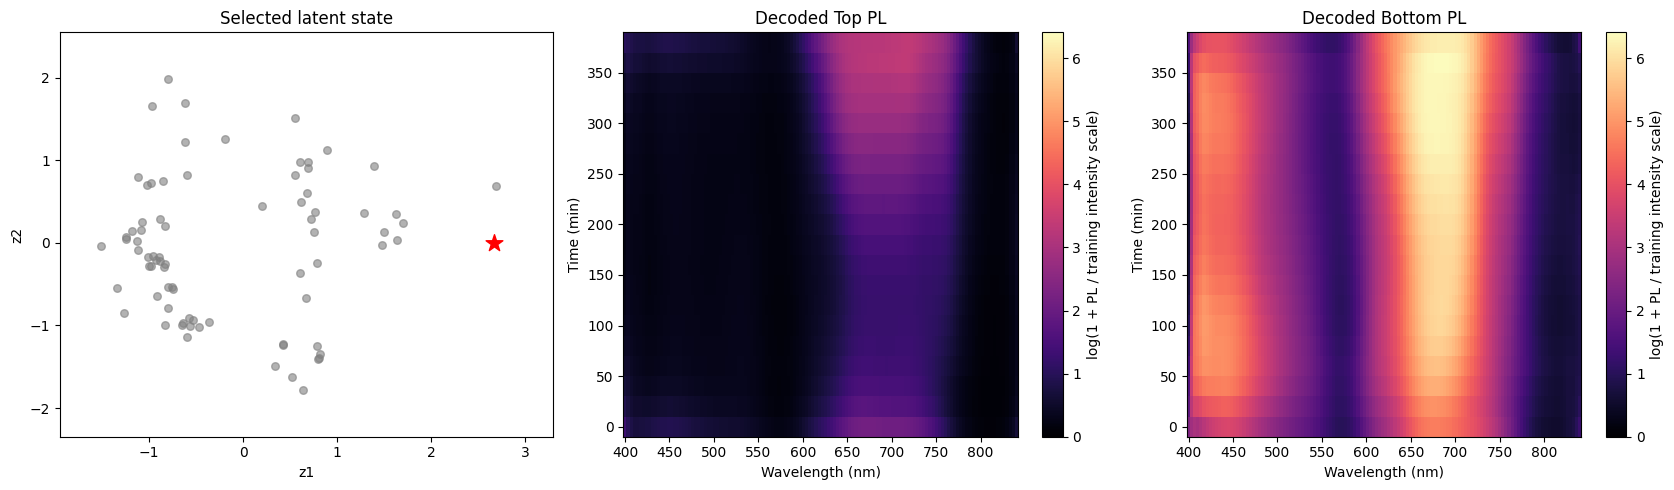

Regions far from encoded training wells are exploratory decoder outputs, not validated material predictions.


In [24]:
# ================================================================
# Problem 2 — paired time–wavelength surfaces -> 2D VAE latent space
#
# Existing variables:
#   rp_composition, rp_features, rp_spectra
#
# One sample = one complete well:
#   [Top surface, Bottom surface], each indexed by time and wavelength.
#
# Models:
#   observed surfaces -> encoder -> z1, z2 -> decoder -> surfaces
#   concentration -> Gaussian processes -> z1, z2 -> decoder
# ================================================================

import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel, RBF, WhiteKernel
)
import ipywidgets as widgets
from IPython.display import display, clear_output

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass

# ---------------------------- Controls -----------------------------
SEED = 42
SPECTRAL_PIXELS = 128
BATCH_SIZE = 16
MAX_EPOCHS = 1200
PATIENCE = 120
LEARNING_RATE = 1e-3
BETA_MAX = 0.002              # reconstruction/KL tradeoff; inspect latent activity
KL_WARMUP_EPOCHS = 150
MIN_VALID_FRACTION = 0.80
BASELINE_CORRECT = False     # preserve original intensities by default
GP_UNCERTAINTY_DRAWS = 100

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ================================================================
# 1. Assemble paired surfaces without downloading any data
# ================================================================

comp = rp_composition.copy().reset_index(drop=True)
meta = rp_features.copy()
comp["well"] = comp["well"].astype(str)
meta["well"] = meta["well"].astype(str)

if comp["well"].duplicated().any():
    raise ValueError("Expected one composition row per well.")

wl_columns = sorted(
    [c for c in rp_spectra.columns if c.startswith("wl_")],
    key=lambda c: float(c.split("_", 1)[1]),
)
native_wavelengths = np.asarray([
    float(c.split("_", 1)[1]) for c in wl_columns
])
wavelength_grid = np.linspace(
    native_wavelengths.min(), native_wavelengths.max(), SPECTRAL_PIXELS
)
times = np.sort(meta["time_min"].unique().astype(float))
geometries = ["Top PL", "Bottom PL"]
spectra_index = rp_spectra.set_index("spectrum_id")

well_names = comp["well"].to_numpy()
well_lookup = {w: i for i, w in enumerate(well_names)}
time_lookup = {float(t): j for j, t in enumerate(times)}

N, T, W = len(comp), len(times), SPECTRAL_PIXELS
raw_surfaces = np.full((N, 2, T, W), np.nan, dtype=np.float32)
seen = set()

for row in meta.itertuples(index=False):
    if row.well not in well_lookup or row.measure not in geometries:
        continue

    i = well_lookup[row.well]
    g = geometries.index(row.measure)
    j = time_lookup[float(row.time_min)]
    key = (i, g, j)
    if key in seen:
        raise ValueError(f"Duplicate record at {key}")
    seen.add(key)

    if row.qc_status != "valid":
        continue

    signal = spectra_index.loc[row.spectrum_id, wl_columns].to_numpy(float)
    if not np.isfinite(signal).all():
        continue

    if BASELINE_CORRECT:
        signal -= np.percentile(signal, 5)

    # Nonnegative PL representation.
    signal = np.maximum(signal, 0)
    raw_surfaces[i, g, j] = np.interp(
        wavelength_grid, native_wavelengths, signal
    )

valid_fraction = np.isfinite(raw_surfaces).mean(axis=(1, 2, 3))
keep = valid_fraction >= MIN_VALID_FRACTION

excluded_wells = well_names[~keep]
comp = comp.loc[keep].reset_index(drop=True)
raw_surfaces = raw_surfaces[keep]
well_names = comp["well"].to_numpy()
N = len(comp)
mask = np.isfinite(raw_surfaces)

if N < 20:
    raise ValueError("Too few sufficiently complete wells remain.")

concentration_columns = ["FAPbI3_host_fraction", "additive_percent"]
concentrations = comp[concentration_columns].to_numpy(float)
if not np.isfinite(concentrations).all():
    raise ValueError("Concentration values must be finite.")

groups = pd.factorize(
    pd.MultiIndex.from_frame(comp[concentration_columns].round(10))
)[0]

# Three disjoint composition groups: training, validation, test.
split = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
development, test_indices = next(split.split(concentrations, groups=groups))

split_val = GroupShuffleSplit(
    n_splits=1, test_size=0.20, random_state=SEED + 1
)
train_local, val_local = next(
    split_val.split(concentrations[development], groups=groups[development])
)
train_indices = development[train_local]
val_indices = development[val_local]

print(
    f"Included wells: {N}; excluded: {list(excluded_wells)}\n"
    f"Train / validation / test: "
    f"{len(train_indices)} / {len(val_indices)} / {len(test_indices)}"
)
print("One sample shape:", raw_surfaces.shape[1:])

# ================================================================
# 2. Training-only scaling that preserves intensity evolution
# ================================================================

positive_training = raw_surfaces[train_indices]
positive_training = positive_training[
    np.isfinite(positive_training) & (positive_training > 0)
]
if not len(positive_training):
    raise ValueError("No positive training signal.")

intensity_scale = float(np.median(positive_training))
log_surfaces = np.log1p(raw_surfaces / intensity_scale)

# One global scale; no per-spectrum or per-well normalization.
log_scale = max(
    float(np.nanpercentile(log_surfaces[train_indices], 99)), 1e-8
)
scaled_surfaces = log_surfaces / log_scale

# Missing observations are filled with the training pixel mean.
# The mask is supplied as additional encoder channels.
training_count = mask[train_indices].sum(axis=0)
training_sum = np.nansum(scaled_surfaces[train_indices], axis=0)
pixel_mean = np.divide(
    training_sum, training_count,
    out=np.zeros_like(training_sum), where=training_count > 0,
)
filled = np.where(mask, scaled_surfaces, pixel_mean[None])
filled = filled.astype(np.float32)
mask_float = mask.astype(np.float32)

X_tensor = torch.from_numpy(filled)
M_tensor = torch.from_numpy(mask_float)

train_loader = DataLoader(
    TensorDataset(X_tensor[train_indices], M_tensor[train_indices]),
    batch_size=BATCH_SIZE, shuffle=True,
)

def to_original_units(array):
    # Guard against numerical overflow in unsupported latent regions.
    return intensity_scale * np.expm1(
        np.clip(np.asarray(array) * log_scale, 0, 40)
    )

# ================================================================
# 3. Small convolutional VAE with exactly two latent coordinates
# ================================================================

class SurfaceVAE(nn.Module):
    def __init__(self, time_points, wavelength_points):
        super().__init__()
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(4, 8, 3, stride=2, padding=1),
            nn.SiLU(),
            nn.Conv2d(8, 16, 3, stride=2, padding=1),
            nn.SiLU(),
            nn.Conv2d(16, 16, 3, stride=2, padding=1),
            nn.SiLU(),
        )
        with torch.no_grad():
            example = self.encoder_conv(
                torch.zeros(1, 4, time_points, wavelength_points)
            )
        self.feature_shape = tuple(example.shape[1:])
        flat_size = int(np.prod(self.feature_shape))

        self.encoder_dense = nn.Sequential(
            nn.Flatten(), nn.Linear(flat_size, 32), nn.SiLU()
        )
        self.mu = nn.Linear(32, 2)
        self.logvar = nn.Linear(32, 2)

        self.decoder_dense = nn.Sequential(
            nn.Linear(2, 32), nn.SiLU(),
            nn.Linear(32, flat_size), nn.SiLU(),
        )
        self.decoder_conv = nn.Sequential(
            nn.Conv2d(16, 16, 3, padding=1), nn.SiLU(),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(16, 8, 3, padding=1), nn.SiLU(),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(8, 8, 3, padding=1), nn.SiLU(),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(8, 2, 3, padding=1),
        )
        self.output_size = (time_points, wavelength_points)

    def encode(self, x, m):
        features = self.encoder_dense(
            self.encoder_conv(torch.cat([x, m], dim=1))
        )
        return self.mu(features), self.logvar(features).clamp(-10, 6)

    def decode(self, z):
        features = self.decoder_dense(z).reshape(-1, *self.feature_shape)
        output = self.decoder_conv(features)
        output = nn.functional.interpolate(
            output, size=self.output_size,
            mode="bilinear", align_corners=False,
        )
        return nn.functional.softplus(output)

    def forward(self, x, m):
        mu, logvar = self.encode(x, m)
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return self.decode(z), mu, logvar

def reconstruction_loss(prediction, actual, observed):
    return (
        ((prediction - actual)**2 * observed).sum(dim=(1, 2, 3))
        / observed.sum(dim=(1, 2, 3)).clamp_min(1)
    ).mean()

def kl_loss(mu, logvar):
    return -0.5 * (
        1 + logvar - mu.square() - logvar.exp()
    ).sum(dim=1).mean()

vae = SurfaceVAE(T, W).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=LEARNING_RATE)
print("VAE parameters:", sum(p.numel() for p in vae.parameters()))

# ================================================================
# 4. Train with validation-based early stopping
# ================================================================

history = []
best_score = np.inf
best_state = None
best_epoch = None
stale = 0

x_val = X_tensor[val_indices].to(device)
m_val = M_tensor[val_indices].to(device)

for epoch in range(1, MAX_EPOCHS + 1):
    vae.train()
    beta = BETA_MAX * min(1.0, epoch / KL_WARMUP_EPOCHS)
    total_recon, total_kl, count = 0.0, 0.0, 0

    for x_batch, m_batch in train_loader:
        x_batch, m_batch = x_batch.to(device), m_batch.to(device)
        optimizer.zero_grad()
        prediction, mu, logvar = vae(x_batch, m_batch)
        recon = reconstruction_loss(prediction, x_batch, m_batch)
        kl = kl_loss(mu, logvar)
        loss = recon + beta * kl
        loss.backward()
        torch.nn.utils.clip_grad_norm_(vae.parameters(), 5)
        optimizer.step()

        batch_n = len(x_batch)
        total_recon += recon.item() * batch_n
        total_kl += kl.item() * batch_n
        count += batch_n

    vae.eval()
    with torch.no_grad():
        val_mu, val_logvar = vae.encode(x_val, m_val)
        val_recon = reconstruction_loss(
            vae.decode(val_mu), x_val, m_val
        ).item()
        val_kl = kl_loss(val_mu, val_logvar).item()

    # Fixed validation objective across epochs.
    val_score = val_recon + BETA_MAX * val_kl
    history.append({
        "epoch": epoch,
        "train_reconstruction": total_recon / count,
        "train_KL": total_kl / count,
        "validation_reconstruction": val_recon,
        "validation_objective": val_score,
    })

    # Start selecting checkpoints after KL warmup.
    if epoch >= KL_WARMUP_EPOCHS:
        if val_score < best_score - 1e-7:
            best_score = val_score
            best_state = copy.deepcopy(vae.state_dict())
            best_epoch = epoch
            stale = 0
        else:
            stale += 1

    if epoch == 1 or epoch % 100 == 0:
        print(
            f"Epoch {epoch:4d}: "
            f"train reconstruction={total_recon/count:.5f}; "
            f"validation={val_recon:.5f}; KL={val_kl:.3f}"
        )
    if stale >= PATIENCE:
        break

if best_state is None:
    best_state = copy.deepcopy(vae.state_dict())
    best_epoch = epoch
vae.load_state_dict(best_state)
vae.eval()
print("Selected epoch:", best_epoch)

with torch.no_grad():
    latent_mu_tensor, latent_logvar_tensor = vae.encode(
        X_tensor.to(device), M_tensor.to(device)
    )
    latent_coordinates = latent_mu_tensor.cpu().numpy()
    latent_sd = torch.exp(0.5 * latent_logvar_tensor).cpu().numpy()
    reconstructed_scaled = vae.decode(latent_mu_tensor).cpu().numpy()

reconstructed_surfaces = to_original_units(reconstructed_scaled)

# ================================================================
# 5. Concentration -> latent function -> decoded surface
# Fit only training wells.
# ================================================================

concentration_scaler = StandardScaler().fit(
    concentrations[train_indices]
)
concentrations_scaled = concentration_scaler.transform(concentrations)

latent_gps = []
concentration_latent_mean = np.zeros((N, 2))
concentration_latent_sd = np.zeros((N, 2))

for k in range(2):
    kernel = (
        ConstantKernel(1.0, (1e-3, 1e3))
        * RBF([1.0, 1.0], (0.05, 20.0))
        + WhiteKernel(0.05, (1e-5, 1.0))
    )
    gp = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        alpha=1e-6,
        n_restarts_optimizer=3,
        random_state=SEED + k,
    )
    gp.fit(
        concentrations_scaled[train_indices],
        latent_coordinates[train_indices, k],
    )
    mean, sd = gp.predict(concentrations_scaled, return_std=True)
    concentration_latent_mean[:, k] = mean
    concentration_latent_sd[:, k] = sd
    latent_gps.append(gp)

def decode_latents(z):
    z = np.asarray(z, dtype=np.float32).reshape(-1, 2)
    with torch.no_grad():
        scaled = vae.decode(torch.from_numpy(z).to(device)).cpu().numpy()
    return scaled, to_original_units(scaled)

concentration_predicted_scaled, concentration_predicted_surfaces = (
    decode_latents(concentration_latent_mean)
)

# ================================================================
# 6. Test-set metrics and a two-component PCA baseline
# ================================================================

pca = PCA(n_components=2).fit(
    filled[train_indices].reshape(len(train_indices), -1)
)
pca_scaled = pca.inverse_transform(
    pca.transform(filled.reshape(N, -1))
).reshape(N, 2, T, W)
pca_surfaces = to_original_units(pca_scaled)

training_mean_scaled = pixel_mean[None].repeat(N, axis=0)
training_mean_surfaces = to_original_units(training_mean_scaled)

def per_well_metrics(predicted_scaled, predicted_raw):
    records = []
    for i in test_indices:
        observed = mask[i]
        actual_log = filled[i][observed]
        predicted_log = predicted_scaled[i][observed]
        actual = raw_surfaces[i][observed]
        predicted = predicted_raw[i][observed]

        cosine = np.dot(actual, predicted) / max(
            np.linalg.norm(actual) * np.linalg.norm(predicted), 1e-15
        )
        records.append({
            "well": well_names[i],
            "scaled_log_RMSE":
                np.sqrt(np.mean((actual_log - predicted_log)**2)),
            "intensity_RMSE":
                np.sqrt(np.mean((actual - predicted)**2)),
            "relative_L2":
                np.linalg.norm(actual - predicted)
                / max(np.linalg.norm(actual), 1e-15),
            "surface_angle_deg":
                np.degrees(np.arccos(np.clip(cosine, -1, 1))),
        })
    return pd.DataFrame(records)

metric_tables = {
    "VAE: encode observed surface":
        per_well_metrics(reconstructed_scaled, reconstructed_surfaces),
    "PCA: encode observed surface":
        per_well_metrics(pca_scaled, pca_surfaces),
    "Concentration -> GP -> VAE":
        per_well_metrics(
            concentration_predicted_scaled, concentration_predicted_surfaces
        ),
    "Training mean":
        per_well_metrics(training_mean_scaled, training_mean_surfaces),
}

metric_summary = pd.DataFrame({
    name: table.drop(columns="well").mean()
    for name, table in metric_tables.items()
}).T

print("\nHELD-OUT-WELL METRICS")
display(metric_summary.round(5))
print(
    "VAE/PCA reconstruction uses the test well's measured surface. "
    "Concentration prediction uses only its concentration coordinates."
)

latent_test_error = (
    latent_coordinates[test_indices]
    - concentration_latent_mean[test_indices]
)
display(pd.DataFrame({
    "latent_coordinate": ["z1", "z2"],
    "GP_test_RMSE": np.sqrt(np.mean(latent_test_error**2, axis=0)),
    "training_encoded_variance":
        latent_coordinates[train_indices].var(axis=0),
    "mean_encoder_posterior_sd":
        latent_sd[train_indices].mean(axis=0),
}))

# Learning curves.
history_table = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(
    history_table["epoch"], history_table["train_reconstruction"],
    label="Training",
)
axes[0].plot(
    history_table["epoch"], history_table["validation_reconstruction"],
    label="Validation",
)
axes[0].set(
    xlabel="Epoch", ylabel="Masked scaled-log MSE",
    title="Surface reconstruction",
)
axes[0].legend()
axes[1].plot(history_table["epoch"], history_table["train_KL"])
axes[1].set(xlabel="Epoch", ylabel="KL", title="Latent regularization")
plt.tight_layout()
plt.show()

# ================================================================
# 7. Concentration map and learned 2D latent representation
# ================================================================

split_labels = np.full(N, "train", dtype=object)
split_labels[val_indices] = "validation"
split_labels[test_indices] = "test"

latent_table = comp[
    ["well", "FAPbI3_host_fraction", "additive_percent"]
].copy()
latent_table["split"] = split_labels
for k in range(2):
    latent_table[f"z{k+1}"] = latent_coordinates[:, k]
    latent_table[f"z{k+1}_GP"] = concentration_latent_mean[:, k]
    latent_table[f"z{k+1}_GP_sd"] = concentration_latent_sd[:, k]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for k in range(2):
    scatter = axes[k].scatter(
        concentrations[:, 0] * 100, concentrations[:, 1],
        c=latent_coordinates[:, k], cmap="coolwarm", s=100,
        edgecolors="black", linewidths=0.3,
    )
    axes[k].set(
        xlabel="FAPbI3 host (%)", ylabel="Nominal MACl level (%)",
        title=f"Observed surfaces encoded as z{k+1}",
    )
    fig.colorbar(scatter, ax=axes[k], label=f"z{k+1}")

for label, marker in [("train", "o"), ("validation", "^"), ("test", "s")]:
    selected = split_labels == label
    axes[2].scatter(
        latent_coordinates[selected, 0],
        latent_coordinates[selected, 1],
        label=label, marker=marker, s=60,
    )
axes[2].set(xlabel="z1", ylabel="z2", title="One point = one well's full evolution")
axes[2].legend()
plt.tight_layout()
plt.show()

# ================================================================
# 8. Two latent sliders: decode entire time–wavelength surfaces
# ================================================================

def latent_range(k):
    values = latent_coordinates[train_indices, k]
    lo, hi = values.min(), values.max()
    padding = max(0.15 * (hi-lo), 0.1)
    return float(lo-padding), float(hi+padding)

z1_range, z2_range = latent_range(0), latent_range(1)
z1_slider = widgets.FloatSlider(
    min=z1_range[0], max=z1_range[1],
    value=float(np.clip(0, *z1_range)),
    step=(z1_range[1]-z1_range[0])/100,
    description="z1:", continuous_update=False,
)
z2_slider = widgets.FloatSlider(
    min=z2_range[0], max=z2_range[1],
    value=float(np.clip(0, *z2_range)),
    step=(z2_range[1]-z2_range[0])/100,
    description="z2:", continuous_update=False,
)
latent_output = widgets.Output()

# Fixed transformed-intensity limits for all slider positions.
display_vmax = max(
    float(np.nanpercentile(log_surfaces[train_indices], 99.5)), 1e-8
)

def show_latent_surface(change=None):
    with latent_output:
        clear_output(wait=True)
        z = np.array([[z1_slider.value, z2_slider.value]], dtype=np.float32)
        scaled, decoded = decode_latents(z)

        fig, axes = plt.subplots(1, 3, figsize=(17, 5))
        axes[0].scatter(
            latent_coordinates[:, 0], latent_coordinates[:, 1],
            s=30, color="gray", alpha=0.6,
        )
        axes[0].scatter(z[0, 0], z[0, 1], s=160, marker="*", color="red")
        axes[0].set(
            xlabel="z1", ylabel="z2", title="Selected latent state",
            xlim=z1_range, ylim=z2_range,
        )

        for g, geometry in enumerate(geometries):
            image = axes[g+1].pcolormesh(
                wavelength_grid, times, scaled[0, g] * log_scale,
                shading="auto", cmap="magma",
                vmin=0, vmax=display_vmax,
            )
            axes[g+1].set(
                xlabel="Wavelength (nm)", ylabel="Time (min)",
                title=f"Decoded {geometry}",
            )
            fig.colorbar(
                image, ax=axes[g+1],
                label="log(1 + PL / training intensity scale)",
            )
        plt.tight_layout()
        plt.show()
        plt.close(fig)
        print(
            "Regions far from encoded training wells are exploratory "
            "decoder outputs, not validated material predictions."
        )

z1_slider.observe(show_latent_surface, names="value")
z2_slider.observe(show_latent_surface, names="value")
display(widgets.VBox([widgets.HBox([z1_slider, z2_slider]), latent_output]))
show_latent_surface()

# ================================================================
# 9. Selected well: observations, reconstruction, concentration prediction
# ================================================================

well_control = widgets.Dropdown(
    options=list(well_names),
    value="H7" if "H7" in well_names else well_names[0],
    description="Well:",
)
well_output = widgets.Output()
well_lookup = {w: i for i, w in enumerate(well_names)}

def show_well(change=None):
    with well_output:
        clear_output(wait=True)
        i = well_lookup[well_control.value]

        fig, axes = plt.subplots(2, 4, figsize=(19, 9))
        for g, geometry in enumerate(geometries):
            observations = np.where(mask[i, g], scaled_surfaces[i, g], np.nan)
            panels = [
                observations,
                reconstructed_scaled[i, g],
                concentration_predicted_scaled[i, g],
                np.where(
                    mask[i, g],
                    scaled_surfaces[i, g] - reconstructed_scaled[i, g],
                    np.nan,
                ),
            ]
            titles = [
                "Observed",
                "VAE reconstruction",
                "Concentration → GP → decoder",
                "Observed − VAE reconstruction",
            ]
            for p, panel in enumerate(panels):
                cmap = plt.get_cmap("RdBu_r" if p == 3 else "magma").copy()
                cmap.set_bad("#bdbdbd")
                values = panel * log_scale

                if p == 3:
                    bound = max(float(np.nanmax(np.abs(values))), 1e-8)
                    vmin, vmax = -bound, bound
                else:
                    vmin, vmax = 0, display_vmax

                image = axes[g, p].pcolormesh(
                    wavelength_grid, times,
                    np.ma.masked_invalid(values),
                    shading="auto", cmap=cmap, vmin=vmin, vmax=vmax,
                )
                axes[g, p].set(
                    xlabel="Wavelength (nm)", ylabel="Time (min)",
                    title=f"{geometry}\n{titles[p]}",
                )
                fig.colorbar(image, ax=axes[g, p], shrink=0.8)

        fig.suptitle(
            f"{well_names[i]} | {split_labels[i]} | "
            f"FAPbI3 host {100*concentrations[i,0]:.1f}% | "
            f"nominal MACl {concentrations[i,1]:g}%\n"
            "Colors: log(1 + PL / training intensity scale)",
            fontsize=13,
        )
        plt.tight_layout(rect=[0, 0, 1, 0.93])
        plt.show()
        plt.close(fig)

well_control.observe(show_well, names="value")
display(widgets.VBox([well_control, well_output]))
show_well()

# ================================================================
# 10. Concentration sliders: generate an entire evolution
# ================================================================

host_control = widgets.FloatSlider(
    min=float(concentrations[:, 0].min()),
    max=float(concentrations[:, 0].max()),
    value=float(np.median(concentrations[:, 0])),
    step=0.01, description="Host fraction:",
    continuous_update=False,
    style={"description_width": "initial"},
)
additive_control = widgets.FloatSlider(
    min=float(concentrations[:, 1].min()),
    max=float(concentrations[:, 1].max()),
    value=float(np.median(concentrations[:, 1])),
    step=0.1, description="MACl level:",
    continuous_update=False,
    style={"description_width": "initial"},
)
concentration_output = widgets.Output()

def show_concentration(change=None):
    with concentration_output:
        clear_output(wait=True)
        c = np.array([[host_control.value, additive_control.value]])
        c_scaled = concentration_scaler.transform(c)

        means, sds = [], []
        for gp in latent_gps:
            mean, sd = gp.predict(c_scaled, return_std=True)
            means.append(mean[0])
            sds.append(sd[0])
        means, sds = np.asarray(means), np.asarray(sds)

        scaled_center, _ = decode_latents(means)
        draws = np.random.default_rng(SEED).normal(
            means, sds, size=(GP_UNCERTAINTY_DRAWS, 2)
        )
        _, decoded_draws = decode_latents(draws)

        # Brightness evolution and uncertainty propagated from GP coordinates.
        integrated_draws = (
            np.trapezoid(decoded_draws, wavelength_grid, axis=-1)
            if hasattr(np, "trapezoid")
            else np.trapz(decoded_draws, wavelength_grid, axis=-1)
        )

        fig, axes = plt.subplots(1, 3, figsize=(17, 5))
        for g, geometry in enumerate(geometries):
            image = axes[g].pcolormesh(
                wavelength_grid, times, scaled_center[0, g] * log_scale,
                shading="auto", cmap="magma",
                vmin=0, vmax=display_vmax,
            )
            axes[g].set(
                xlabel="Wavelength (nm)", ylabel="Time (min)",
                title=f"Generated {geometry}",
            )
            fig.colorbar(image, ax=axes[g], label="Transformed PL")

            median = np.median(integrated_draws[:, g], axis=0)
            lower, upper = np.quantile(
                integrated_draws[:, g], [0.025, 0.975], axis=0
            )
            line, = axes[2].plot(times, median, label=geometry)
            axes[2].fill_between(
                times, lower, upper,
                color=line.get_color(), alpha=0.2,
            )

        axes[2].set(
            xlabel="Time (min)", ylabel="Integrated PL (instrument units × nm)",
            title="Brightness evolution: propagated GP uncertainty",
        )
        axes[2].legend()
        plt.tight_layout()
        plt.show()
        plt.close(fig)

        print(
            f"Predicted latent mean: ({means[0]:.3f}, {means[1]:.3f}); "
            f"SD: ({sds[0]:.3f}, {sds[1]:.3f})."
        )
        print(
            "Bands propagate the fitted latent-GP uncertainty only; "
            "they exclude decoder/model uncertainty. "
            "Independent GPs assume independent latent prediction errors."
        )

host_control.observe(show_concentration, names="value")
additive_control.observe(show_concentration, names="value")
display(widgets.VBox([
    widgets.HBox([host_control, additive_control]),
    concentration_output,
]))
show_concentration()

# Reusable results:
# vae, latent_gps, latent_table, metric_tables, metric_summary
# raw_surfaces, reconstructed_surfaces, concentration_predicted_surfaces
# wavelength_grid, times, train_indices, val_indices, test_indices

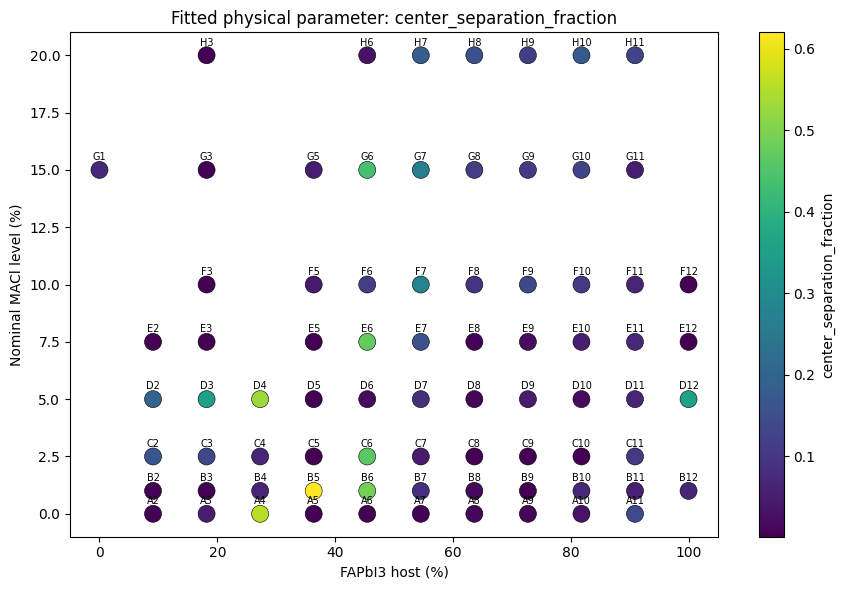

In [25]:
# ================================================================
# Physical decoder for complete Top/Bottom I(wavelength, time)
#
# Existing variables:
#   rp_composition, rp_features, rp_spectra
#
# Parameterized spectral kinetics -> complete surfaces
# Concentration -> parameter fields -> complete surfaces
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets

from scipy.optimize import least_squares
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel
from IPython.display import display, clear_output

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass

# ----------------------------- Controls ---------------------------
SEED = 42
WAVELENGTH_POINTS = 100
EARLY_CUTOFF_MIN = 240
TEST_FRACTION = 0.25
MIN_VALID_FRACTION = 0.80
N_STARTS = 3
MAX_FUNCTION_EVALUATIONS = 800
MIN_WIDTH_NM = 4.0
MAX_WIDTH_NM = 100.0

rng = np.random.default_rng(SEED)
integrate = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
geometries = ["Top PL", "Bottom PL"]

# ================================================================
# 1. Assemble surfaces; preserve intensity evolution
# ================================================================

comp = rp_composition.copy().reset_index(drop=True)
meta = rp_features.copy()
comp["well"] = comp["well"].astype(str)
meta["well"] = meta["well"].astype(str)

wl_columns = sorted(
    [c for c in rp_spectra if c.startswith("wl_")],
    key=lambda c: float(c.split("_", 1)[1]),
)
native_wavelengths = np.array([
    float(c.split("_", 1)[1]) for c in wl_columns
])
wl = np.linspace(
    native_wavelengths.min(), native_wavelengths.max(),
    WAVELENGTH_POINTS,
)
times = np.sort(meta["time_min"].unique().astype(float))
spectra_index = rp_spectra.set_index("spectrum_id")

well_lookup = {w: i for i, w in enumerate(comp["well"])}
time_lookup = {float(t): j for j, t in enumerate(times)}
Y = np.full((len(comp), 2, len(times), len(wl)), np.nan)
seen = set()

for row in meta.itertuples(index=False):
    if row.well not in well_lookup or row.measure not in geometries:
        continue
    i = well_lookup[row.well]
    g = geometries.index(row.measure)
    j = time_lookup[float(row.time_min)]

    if (i, g, j) in seen:
        raise ValueError("Duplicate well/time/geometry record.")
    seen.add((i, g, j))

    if row.qc_status != "valid":
        continue
    signal = spectra_index.loc[row.spectrum_id, wl_columns].to_numpy(float)
    if np.isfinite(signal).all():
        # Preserve signed background values; decoder fits a background.
        Y[i, g, j] = np.interp(wl, native_wavelengths, signal)

keep = np.isfinite(Y).mean(axis=(1, 2, 3)) >= MIN_VALID_FRACTION
print("Excluded wells:", list(comp.loc[~keep, "well"]))
comp = comp.loc[keep].reset_index(drop=True)
Y = Y[keep]
mask = np.isfinite(Y)
wells = comp["well"].to_numpy()
N = len(wells)

C = comp[["FAPbI3_host_fraction", "additive_percent"]].to_numpy(float)
groups = pd.factorize(pd.MultiIndex.from_frame(
    comp[["FAPbI3_host_fraction", "additive_percent"]].round(10)
))[0]

split = GroupShuffleSplit(
    n_splits=1, test_size=TEST_FRACTION, random_state=SEED
)
train_indices, test_indices = next(split.split(C, groups=groups))
early = times <= EARLY_CUTOFF_MIN

if early.sum() < 4 or (~early).sum() < 2:
    raise ValueError("Choose a cutoff with sufficient early and later times.")

# Training-only global scaling for numerical conditioning.
positive = Y[train_indices]
positive = positive[np.isfinite(positive) & (positive > 0)]
if not len(positive):
    raise ValueError("No positive training intensities.")
signal_scale = float(np.percentile(positive, 90))
Ys = Y / signal_scale
wl_span = wl[-1] - wl[0]

# ================================================================
# 2. Physical decoders
#
# All Gaussian profiles have unit area over the measured window.
# Amplitudes therefore represent integrated PL within that window,
# in units of signal_scale × nm.
#
# Top collection gain fixed to 1; Bottom gain fitted.
# Constant backgrounds fitted independently for each geometry.
# ================================================================

def band(center, width):
    profile = np.exp(-0.5 * ((wl - center) / width)**2)
    return profile / max(integrate(profile, wl), 1e-15)

MODEL_NAMES = ["shifting_band", "two_shared_tau", "two_independent_tau"]

def parameter_spec(model):
    # Stored coordinates use logs for positive parameters.
    # Two-band centers are ordered using a fractional separation.
    common = [
        ("log_bottom_gain", np.log(0.05), np.log(20.0)),
        ("background_top", -2.0, 2.0),
        ("background_bottom", -2.0, 2.0),
    ]
    amplitude = (np.log(1e-4), np.log(100 * wl_span))
    tau = (np.log(5.0), np.log(3000.0))
    width = (np.log(MIN_WIDTH_NM), np.log(MAX_WIDTH_NM))

    if model == "shifting_band":
        return [
            ("log_A_initial", *amplitude),
            ("log_A_final", *amplitude),
            ("log_tau_intensity", *tau),
            ("center_initial_nm", wl[0], wl[-1]),
            ("center_final_nm", wl[0], wl[-1]),
            ("log_tau_shift", *tau),
            ("log_width_nm", *width),
        ] + common

    core = [
        ("log_A1_initial", *amplitude),
        ("log_A2_initial", *amplitude),
        ("log_A2_added", *amplitude),
        ("log_tau_fade", *tau),
    ]
    if model == "two_independent_tau":
        core += [("log_tau_growth", *tau)]

    return core + [
        ("center1_nm", wl[0], wl[-1] - 2),
        ("center_separation_fraction", 0.001, 0.999),
        ("log_width1_nm", *width),
        ("log_width2_nm", *width),
    ] + common

def parameter_dict(theta, model):
    return dict(zip([s[0] for s in parameter_spec(model)], theta))

def decode(theta, model, time_grid=times):
    p = parameter_dict(theta, model)
    t = np.asarray(time_grid)[:, None]

    if model == "shifting_band":
        A0, Af = np.exp(p["log_A_initial"]), np.exp(p["log_A_final"])
        amplitude = Af + (A0 - Af) * np.exp(
            -t / np.exp(p["log_tau_intensity"])
        )
        centers = (
            p["center_final_nm"]
            + (p["center_initial_nm"] - p["center_final_nm"])
            * np.exp(-t[:, 0] / np.exp(p["log_tau_shift"]))
        )
        width = np.exp(p["log_width_nm"])
        profiles = np.stack([band(center, width) for center in centers])
        surface = amplitude * profiles

    else:
        tau_fade = np.exp(p["log_tau_fade"])
        tau_growth = (
            np.exp(p["log_tau_growth"])
            if model == "two_independent_tau" else tau_fade
        )
        A1 = np.exp(p["log_A1_initial"]) * np.exp(-t / tau_fade)
        A2 = (
            np.exp(p["log_A2_initial"])
            + np.exp(p["log_A2_added"]) * (1 - np.exp(-t / tau_growth))
        )
        center1 = p["center1_nm"]
        center2 = center1 + p["center_separation_fraction"] * (wl[-1] - center1)
        surface = (
            A1 * band(center1, np.exp(p["log_width1_nm"]))[None]
            + A2 * band(center2, np.exp(p["log_width2_nm"]))[None]
        )

    top = surface + p["background_top"]
    bottom = np.exp(p["log_bottom_gain"]) * surface + p["background_bottom"]
    return np.stack([top, bottom])

def initial_parameters(i, model):
    spec = parameter_spec(model)
    lower = np.array([s[1] for s in spec])
    upper = np.array([s[2] for s in spec])
    p = {name: (lo + hi)/2 for name, lo, hi in spec}

    # Initialization uses only early data, even for final fitting.
    early_surface = Ys[i, :, early, :]
    mean_spectrum = np.nanmean(
        early_surface.reshape(-1, len(wl)), axis=0
    )
    mean_spectrum = np.nan_to_num(mean_spectrum, nan=0)
    background = float(np.percentile(mean_spectrum, 10))
    positive_spectrum = np.maximum(mean_spectrum - background, 0)
    center = wl[np.argmax(positive_spectrum)]
    area = max(integrate(positive_spectrum, wl), 1e-3)

    for name in p:
        if name.startswith("log_A"):
            p[name] = np.log(area / 2)
        elif name.startswith("log_tau"):
            p[name] = np.log(150)
        elif name.startswith("log_width"):
            p[name] = np.log(20)

    p["log_bottom_gain"] = 0
    p["background_top"] = background
    p["background_bottom"] = background

    if model == "shifting_band":
        p["center_initial_nm"] = center
        p["center_final_nm"] = center
    else:
        p["center1_nm"] = center - 15
        p["center_separation_fraction"] = (
            30 / max(wl[-1] - (center - 15), 1)
        )

    theta = np.array([p[s[0]] for s in spec])
    return np.clip(theta, lower + 1e-7, upper - 1e-7), lower, upper

def fit_well(i, model, selected_times, warm_start=None):
    initial, lower, upper = initial_parameters(i, model)
    if warm_start is not None:
        initial = np.clip(warm_start, lower + 1e-7, upper - 1e-7)

    observed_mask = mask[i].copy()
    observed_mask[:, ~selected_times, :] = False
    if observed_mask.sum() < 10 * len(initial):
        raise ValueError(f"Insufficient observations for well {wells[i]}.")

    def residual(theta):
        return (decode(theta, model) - Ys[i])[observed_mask]

    best = None
    for start in range(N_STARTS):
        theta0 = initial.copy()
        if start:
            theta0 += rng.normal(0, 0.05, len(theta0)) * (upper - lower)
            theta0 = np.clip(theta0, lower + 1e-7, upper - 1e-7)

        result = least_squares(
            residual, theta0, bounds=(lower, upper),
            loss="soft_l1", f_scale=0.1,
            max_nfev=MAX_FUNCTION_EVALUATIONS,
            x_scale="jac",
        )
        if best is None or result.cost < best.cost:
            best = result

    return best

# ================================================================
# 3. Select decoder by predicting later times of training wells
# No held-out compositions used for model selection.
# ================================================================

early_fits = {}
selection_records = []

for model in MODEL_NAMES:
    squared_error_sum, observation_count = 0.0, 0
    converged = 0

    for position, i in enumerate(train_indices):
        fit = fit_well(i, model, early)
        early_fits[(model, i)] = fit.x
        prediction = decode(fit.x, model)

        late_mask = mask[i].copy()
        late_mask[:, early, :] = False
        residual = (prediction - Ys[i])[late_mask]

        squared_error_sum += np.sum(residual**2)
        observation_count += len(residual)
        converged += int(fit.success)

    selection_records.append({
        "model": model,
        "parameters_per_well": len(parameter_spec(model)),
        "late_time_RMSE_scaled":
            np.sqrt(squared_error_sum / max(observation_count, 1)),
        "converged_early_fits": converged,
    })
    print("Completed model:", model)

model_comparison = pd.DataFrame(selection_records).sort_values(
    "late_time_RMSE_scaled"
)
display(model_comparison)
selected_model = model_comparison.iloc[0]["model"]
print("Selected decoder:", selected_model)

# ================================================================
# 4. Fit selected model to complete measured surfaces
# Test-well fits are descriptive reconstruction, not prediction.
# ================================================================

theta_fits, fit_results = [], []
for i in range(N):
    warm = early_fits.get((selected_model, i))
    result = fit_well(
        i, selected_model, np.ones(len(times), dtype=bool), warm
    )
    theta_fits.append(result.x)
    fit_results.append(result)

theta_fits = np.asarray(theta_fits)
fitted_surfaces = np.stack([
    decode(theta, selected_model) for theta in theta_fits
]) * signal_scale

spec = parameter_spec(selected_model)
parameter_names = [s[0] for s in spec]
lower_bounds = np.array([s[1] for s in spec])
upper_bounds = np.array([s[2] for s in spec])

# Readable parameter table.
physical_parameters = pd.DataFrame({"well": wells})
for j, name in enumerate(parameter_names):
    if name.startswith("log_"):
        physical_parameters[name[4:]] = np.exp(theta_fits[:, j])
    else:
        physical_parameters[name] = theta_fits[:, j]

if selected_model != "shifting_band":
    p1 = physical_parameters["center1_nm"]
    fraction = physical_parameters["center_separation_fraction"]
    physical_parameters["center2_nm"] = p1 + fraction * (wl[-1] - p1)
    if selected_model == "two_shared_tau":
        physical_parameters["tau_growth"] = physical_parameters["tau_fade"]

physical_parameters["fit_converged"] = [r.success for r in fit_results]
physical_parameters["at_parameter_bound"] = np.any(
    np.isclose(theta_fits, lower_bounds, atol=1e-4)
    | np.isclose(theta_fits, upper_bounds, atol=1e-4),
    axis=1,
)
display(physical_parameters.head())

# ================================================================
# 5. Concentration -> decoder-parameter fields
# Log coordinates enforce positive parameters after decoding.
# ================================================================

concentration_scaler = StandardScaler().fit(C[train_indices])
C_scaled = concentration_scaler.transform(C)

parameter_gps = []
theta_predicted = np.empty_like(theta_fits)
theta_prediction_sd = np.empty_like(theta_fits)

for j, name in enumerate(parameter_names):
    gp = GaussianProcessRegressor(
        kernel=(
            ConstantKernel(1.0, (1e-3, 1e3))
            * RBF([1.0, 1.0], (0.05, 20))
            + WhiteKernel(0.05, (1e-5, 1))
        ),
        normalize_y=True,
        alpha=1e-6,
        n_restarts_optimizer=2,
        random_state=SEED + j,
    )
    gp.fit(C_scaled[train_indices], theta_fits[train_indices, j])
    mean, sd = gp.predict(C_scaled, return_std=True)
    theta_predicted[:, j] = mean
    theta_prediction_sd[:, j] = sd
    parameter_gps.append(gp)

# Respect decoder bounds for generated parameters.
theta_predicted = np.clip(theta_predicted, lower_bounds, upper_bounds)
concentration_surfaces = np.stack([
    decode(theta, selected_model) for theta in theta_predicted
]) * signal_scale

# ================================================================
# 6. Reconstruction and held-out concentration prediction metrics
# ================================================================

training_mean = np.nanmean(Y[train_indices], axis=0)
training_mean = np.nan_to_num(training_mean, nan=0)

def evaluate_surfaces(predictions, indices, label):
    records = []
    for i in indices:
        observed = mask[i]
        actual = Y[i][observed]
        predicted = predictions[i][observed]
        difference = actual - predicted
        records.append({
            "well": wells[i],
            "model": label,
            "RMSE": np.sqrt(np.mean(difference**2)),
            "relative_L2":
                np.linalg.norm(difference) / max(np.linalg.norm(actual), 1e-15),
            "MSE": np.mean(difference**2),
        })
    return pd.DataFrame(records)

baseline_surfaces = np.repeat(training_mean[None], N, axis=0)
metric_tables = [
    evaluate_surfaces(
        fitted_surfaces, test_indices, "Fit measured full surface"
    ),
    evaluate_surfaces(
        concentration_surfaces, test_indices, "Concentration -> physical decoder"
    ),
    evaluate_surfaces(
        baseline_surfaces, test_indices, "Training mean surface"
    ),
]
physical_model_metrics = pd.concat(metric_tables, ignore_index=True)
display(physical_model_metrics.groupby("model")[["RMSE", "relative_L2"]].mean())

prediction_mse = metric_tables[1]["MSE"].sum()
baseline_mse = metric_tables[2]["MSE"].sum()
print(
    "Held-out concentration prediction skill:",
    1 - prediction_mse / baseline_mse if baseline_mse > 0 else np.nan,
)
print(
    "Full-surface fits use the measured test surfaces; "
    "concentration predictions use concentration only."
)

# Diagnostics: numerical identifiability from the fitted Jacobian.
# Large condition numbers indicate poorly separated parameter effects.
conditioning = []
for i, result in enumerate(fit_results):
    singular_values = np.linalg.svd(result.jac, compute_uv=False)
    condition = singular_values[0] / max(singular_values[-1], 1e-15)
    conditioning.append({
        "well": wells[i],
        "Jacobian_condition_number": condition,
        "converged": result.success,
    })
identifiability_table = pd.DataFrame(conditioning)
display(identifiability_table.sort_values(
    "Jacobian_condition_number", ascending=False
).head(10))

# ================================================================
# 7. Parameter maps over original concentration coordinates
# ================================================================

parameter_control = widgets.Dropdown(
    options=list(physical_parameters.select_dtypes("number").columns),
    description="Parameter:",
    style={"description_width": "initial"},
)
map_output = widgets.Output()

def draw_parameter_map(change=None):
    with map_output:
        clear_output(wait=True)
        name = parameter_control.value
        values = physical_parameters[name].to_numpy()
        fig, ax = plt.subplots(figsize=(9, 6))
        points = ax.scatter(
            C[:, 0] * 100, C[:, 1],
            c=values, cmap="viridis", s=150,
            edgecolors="black", linewidths=0.4,
        )
        for i, well in enumerate(wells):
            ax.annotate(
                well, (C[i, 0]*100, C[i, 1]),
                xytext=(0, 7), textcoords="offset points",
                ha="center", fontsize=7,
            )
        ax.set(
            xlabel="FAPbI3 host (%)",
            ylabel="Nominal MACl level (%)",
            title=f"Fitted physical parameter: {name}",
        )
        fig.colorbar(points, ax=ax, label=name)
        plt.tight_layout()
        plt.show()
        plt.close(fig)

parameter_control.observe(draw_parameter_map, names="value")
display(widgets.VBox([parameter_control, map_output]))
draw_parameter_map()

# ================================================================
# 8. Selected well: observed, physical fit, concentration prediction
# ================================================================

well_control = widgets.Dropdown(
    options=list(wells),
    value="H7" if "H7" in wells else wells[0],
    description="Well:",
)
well_output = widgets.Output()
lookup = {w: i for i, w in enumerate(wells)}
global_limit = np.nanpercentile(Y[train_indices], 99)
global_lower = min(0, float(np.nanpercentile(Y[train_indices], 1)))

def draw_well(change=None):
    with well_output:
        clear_output(wait=True)
        i = lookup[well_control.value]
        fig, axes = plt.subplots(2, 4, figsize=(19, 9))

        for g, geometry in enumerate(geometries):
            panels = [
                Y[i, g],
                fitted_surfaces[i, g],
                concentration_surfaces[i, g],
                np.where(
                    mask[i, g], Y[i, g] - fitted_surfaces[i, g], np.nan
                ),
            ]
            titles = ["Observed", "Physical fit", "Concentration prediction", "Fit residual"]

            for p, panel in enumerate(panels):
                cmap = plt.get_cmap("RdBu_r" if p == 3 else "magma").copy()
                cmap.set_bad("#bdbdbd")

                if p == 3:
                    bound = max(float(np.nanmax(np.abs(panel))), 1e-12)
                    lo, hi = -bound, bound
                else:
                    lo, hi = global_lower, global_limit

                image = axes[g, p].pcolormesh(
                    wl, times, np.ma.masked_invalid(panel),
                    shading="auto", cmap=cmap, vmin=lo, vmax=hi,
                )
                axes[g, p].set(
                    xlabel="Wavelength (nm)", ylabel="Time (min)",
                    title=f"{geometry}\n{titles[p]}",
                )
                fig.colorbar(image, ax=axes[g, p], shrink=0.8)

        status = "held-out composition" if i in test_indices else "training composition"
        fig.suptitle(
            f"{wells[i]} | {status} | {selected_model}",
            fontsize=14,
        )
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()
        plt.close(fig)
        display(physical_parameters.iloc[[i]])

well_control.observe(draw_well, names="value")
display(widgets.VBox([well_control, well_output]))
draw_well()

# ================================================================
# 9. Concentration and physical-parameter controls
# Generate complete surfaces; optionally override one parameter.
# ================================================================

host_control = widgets.FloatSlider(
    min=float(C[:, 0].min()), max=float(C[:, 0].max()),
    value=float(np.median(C[:, 0])), step=0.01,
    description="Host fraction:", continuous_update=False,
    style={"description_width": "initial"},
)
additive_control = widgets.FloatSlider(
    min=float(C[:, 1].min()), max=float(C[:, 1].max()),
    value=float(np.median(C[:, 1])), step=0.1,
    description="MACl level:", continuous_update=False,
    style={"description_width": "initial"},
)
override_control = widgets.Dropdown(
    options=[("Use concentration prediction", None)] + [
        (name[4:] if name.startswith("log_") else name, j)
        for j, name in enumerate(parameter_names)
    ],
    description="Override:",
    style={"description_width": "initial"},
)
override_slider = widgets.FloatSlider(
    min=0, max=1, value=0.5, step=0.01,
    description="Value:", continuous_update=False,
    disabled=True,
    style={"description_width": "initial"},
)
generated_output = widgets.Output()

def configure_override(change=None):
    j = override_control.value
    override_slider.disabled = j is None
    if j is not None:
        name = parameter_names[j]
        values = theta_fits[train_indices, j]
        if name.startswith("log_"):
            values = np.exp(values)
        lo, hi = float(values.min()), float(values.max())
        if hi <= lo:
            hi = lo + max(abs(lo)*0.1, 0.01)
        # Temporarily broaden bounds to avoid widget assignment conflicts.
        override_slider.min = min(override_slider.min, lo)
        override_slider.max = max(override_slider.max, hi)
        override_slider.value = (lo + hi)/2
        override_slider.min, override_slider.max = lo, hi
        override_slider.step = (hi-lo)/100
        override_slider.description = (
            name[4:] if name.startswith("log_") else name
        ) + ":"
    draw_generated()

def draw_generated(change=None):
    with generated_output:
        clear_output(wait=True)
        concentration = np.array([[
            host_control.value, additive_control.value
        ]])
        standardized = concentration_scaler.transform(concentration)
        theta = np.array([
            gp.predict(standardized)[0] for gp in parameter_gps
        ])
        theta = np.clip(theta, lower_bounds, upper_bounds)

        j = override_control.value
        if j is not None:
            value = override_slider.value
            theta[j] = (
                np.log(value) if parameter_names[j].startswith("log_")
                else value
            )
            theta = np.clip(theta, lower_bounds, upper_bounds)

        surfaces = decode(theta, selected_model) * signal_scale
        fig, axes = plt.subplots(1, 3, figsize=(17, 5))

        for g, geometry in enumerate(geometries):
            image = axes[g].pcolormesh(
                wl, times, surfaces[g], shading="auto",
                cmap="magma", vmin=global_lower, vmax=global_limit,
            )
            axes[g].set(
                xlabel="Wavelength (nm)", ylabel="Time (min)",
                title=f"Generated {geometry}",
            )
            fig.colorbar(image, ax=axes[g], label="PL instrument units")

            p = parameter_dict(theta, selected_model)
            background = p[
                "background_top" if g == 0 else "background_bottom"
            ] * signal_scale
            integrated = integrate(
                surfaces[g] - background, wl, axis=-1
            )
            axes[2].plot(times, integrated, label=geometry)

        axes[2].set(
            xlabel="Time (min)",
            ylabel="Background-subtracted integrated PL",
            title="Generated brightness evolution",
        )
        axes[2].legend()
        plt.tight_layout()
        plt.show()
        plt.close(fig)

        print(
            "Parameter override explores the decoder directly; "
            "it need not correspond to an experimentally realized composition."
        )

host_control.observe(draw_generated, names="value")
additive_control.observe(draw_generated, names="value")
override_control.observe(configure_override, names="value")
override_slider.observe(draw_generated, names="value")

display(widgets.VBox([
    widgets.HBox([host_control, additive_control]),
    widgets.HBox([override_control, override_slider]),
    generated_output,
]))
draw_generated()

# Reusable results:
# selected_model, model_comparison, physical_parameters
# physical_model_metrics, identifiability_table
# theta_fits, parameter_gps, fitted_surfaces, concentration_surfaces

In [26]:
# ================================================================
# JOINT physical decoder + concentration-dependent GP fields
#
# Run after the previous physical-model cell.
#
# Uses:
# selected_model, parameter_spec, parameter_names
# lower_bounds, upper_bounds, theta_fits
# C, Y, Ys, mask, wl, times, signal_scale
# train_indices, test_indices, wells, concentration_scaler
#
# Independent fits are INITIALIZATION ONLY.
# Final fields are optimized against measured spectral surfaces.
# ================================================================

import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
import ipywidgets as widgets
from IPython.display import display, clear_output

# --------------------------- Controls -----------------------------
JOINT_STEPS = 2000
JOINT_LR = 0.02

# Length scales in standardized concentration coordinates.
# Increase to enforce smoother parameter fields.
HOST_LENGTH_SCALE = 0.8
ADDITIVE_LENGTH_SCALE = 0.8

STUDENT_DF = 4.0
# Adjacent spectral pixels are correlated. This controls the effective
# likelihood weight per observed spectrum rather than counting every
# interpolated wavelength as an independent measurement.
EFFECTIVE_PIXELS_PER_SPECTRUM = 10.0

DENSE_GRID_SIZE = 100
JOINT_SEED = 42

torch.manual_seed(JOINT_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float64

def tensor(value):
    return torch.as_tensor(value, dtype=dtype, device=device)

print("Joint-fit device:", device)

# ================================================================
# 1. GP covariance at TRAINING concentrations
# ================================================================

C_standardized = concentration_scaler.transform(C)
C_train = C_standardized[train_indices]

length_scales = np.array([
    HOST_LENGTH_SCALE, ADDITIVE_LENGTH_SCALE
])

def matern32(a, b):
    difference = (
        a[:, None, :] - b[None, :, :]
    ) / length_scales[None, None, :]
    distance = np.sqrt(np.sum(difference**2, axis=-1))
    root3_distance = np.sqrt(3.0) * distance
    return (1 + root3_distance) * np.exp(-root3_distance)

# Unit-amplitude fields in standardized, unconstrained coordinates.
# Jitter also accommodates duplicate concentration coordinates.
K_train = matern32(C_train, C_train)
K_train += 1e-5 * np.eye(len(C_train))
L_train = np.linalg.cholesky(K_train)
L_t = tensor(L_train)

# ================================================================
# 2. Bounded physical parameters from unconstrained GP fields
#
# theta = lower + (upper-lower) * sigmoid(u)
#
# theta retains the previous decoder coordinates:
# log amplitudes, log timescales, centers, widths, backgrounds, gain.
# ================================================================

parameter_span = upper_bounds - lower_bounds
initial_fraction = np.clip(
    (theta_fits[train_indices] - lower_bounds) / parameter_span,
    1e-3, 1-1e-3,
)
initial_u = np.log(initial_fraction / (1-initial_fraction))

# Fixed standardization derived from training initialization.
u_location = np.median(initial_u, axis=0)
u_scale = np.maximum(np.std(initial_u, axis=0), 0.5)
initial_standardized_u = (initial_u - u_location) / u_scale

# Whitened GP coordinates: field = mean + L @ v.
initial_mean = initial_standardized_u.mean(axis=0)
initial_v = np.linalg.solve(
    L_train, initial_standardized_u - initial_mean
)

lower_t = tensor(lower_bounds)
span_t = tensor(parameter_span)
location_t = tensor(u_location)
scale_t = tensor(u_scale)

class JointParameterFields(nn.Module):
    def __init__(self):
        super().__init__()
        self.field_mean = nn.Parameter(tensor(initial_mean))
        self.white_values = nn.Parameter(tensor(initial_v))

    def standardized_fields(self):
        return self.field_mean[None, :] + L_t @ self.white_values

    def physical_parameters(self):
        u = location_t + scale_t * self.standardized_fields()
        return lower_t + span_t * torch.sigmoid(u)

joint_fields = JointParameterFields().to(device)

# ================================================================
# 3. Differentiable physical decoder
# Identical spectral/kinetic structure to the previous decoder.
# ================================================================

wl_t = tensor(wl)
times_t = tensor(times)
parameter_index = {name: j for j, name in enumerate(parameter_names)}

def decode_torch(theta):
    # theta: number_of_wells × number_of_parameters
    def get(name):
        return theta[:, parameter_index[name]]

    def profile(center, width):
        # center/width: wells × times, or wells × 1
        values = torch.exp(
            -0.5 * (
                (wl_t[None, None, :] - center[:, :, None])
                / width[:, :, None]
            )**2
        )
        area = torch.trapezoid(values, wl_t, dim=-1).clamp_min(1e-12)
        return values / area[:, :, None]

    t = times_t[None, :]

    if selected_model == "shifting_band":
        a0 = torch.exp(get("log_A_initial"))[:, None]
        af = torch.exp(get("log_A_final"))[:, None]
        tau_a = torch.exp(get("log_tau_intensity"))[:, None]
        amplitude = af + (a0-af) * torch.exp(-t/tau_a)

        c0 = get("center_initial_nm")[:, None]
        cf = get("center_final_nm")[:, None]
        tau_c = torch.exp(get("log_tau_shift"))[:, None]
        centers = cf + (c0-cf) * torch.exp(-t/tau_c)
        widths = torch.exp(get("log_width_nm"))[:, None]
        surface = amplitude[:, :, None] * profile(centers, widths)

    else:
        tau_fade = torch.exp(get("log_tau_fade"))[:, None]
        tau_growth = (
            torch.exp(get("log_tau_growth"))[:, None]
            if selected_model == "two_independent_tau"
            else tau_fade
        )
        a1 = (
            torch.exp(get("log_A1_initial"))[:, None]
            * torch.exp(-t/tau_fade)
        )
        a2 = (
            torch.exp(get("log_A2_initial"))[:, None]
            + torch.exp(get("log_A2_added"))[:, None]
            * (1-torch.exp(-t/tau_growth))
        )

        c1 = get("center1_nm")[:, None]
        c2 = c1 + get("center_separation_fraction")[:, None] * (
            wl_t[-1] - c1
        )
        w1 = torch.exp(get("log_width1_nm"))[:, None]
        w2 = torch.exp(get("log_width2_nm"))[:, None]

        surface = (
            a1[:, :, None] * profile(c1, w1)
            + a2[:, :, None] * profile(c2, w2)
        )

    top = surface + get("background_top")[:, None, None]
    bottom = (
        torch.exp(get("log_bottom_gain"))[:, None, None] * surface
        + get("background_bottom")[:, None, None]
    )
    return torch.stack([top, bottom], dim=1)

# ================================================================
# 4. Robust joint spectral objective + GP prior
# ================================================================

training_data = tensor(np.nan_to_num(Ys[train_indices], nan=0))
training_mask = tensor(mask[train_indices].astype(float))
valid_pixel_count = training_mask.sum(dim=-1)
valid_spectra = valid_pixel_count > 0

# Fixed robust residual scales from TRAINING initialization only.
initial_predictions = np.stack([
    decode(theta_fits[i], selected_model) for i in train_indices
])
noise_scales = []
for g in range(2):
    residual = (
        initial_predictions[:, g] - Ys[train_indices, g]
    )[mask[train_indices, g]]
    median = np.median(residual)
    robust_sd = 1.4826 * np.median(np.abs(residual-median))
    noise_scales.append(max(float(robust_sd), 0.03))
noise_t = tensor(noise_scales)[None, :, None, None]

optimizer = torch.optim.Adam(
    joint_fields.parameters(), lr=JOINT_LR
)
joint_history = []
best_loss = np.inf
best_state = None

for step in range(1, JOINT_STEPS + 1):
    optimizer.zero_grad()
    theta = joint_fields.physical_parameters()
    prediction = decode_torch(theta)
    standardized_residual = (prediction-training_data) / noise_t

    # Student-t negative log likelihood, up to fixed constants.
    pixel_loss = 0.5 * (STUDENT_DF+1) * torch.log1p(
        standardized_residual.square() / STUDENT_DF
    )
    spectrum_loss = (
        (pixel_loss * training_mask).sum(dim=-1)
        / valid_pixel_count.clamp_min(1)
    )
    likelihood_loss = (
        EFFECTIVE_PIXELS_PER_SPECTRUM
        * spectrum_loss[valid_spectra].sum()
    )

    # Unit Gaussian prior on whitened GP values; broad mean prior.
    gp_prior = 0.5 * joint_fields.white_values.square().sum()
    mean_prior = 0.5 * (joint_fields.field_mean/3.0).square().sum()

    loss = likelihood_loss + gp_prior + mean_prior
    loss.backward()
    torch.nn.utils.clip_grad_norm_(joint_fields.parameters(), 100)
    optimizer.step()

    joint_history.append({
        "step": step,
        "objective": float(loss.detach()),
        "spectral_loss": float(likelihood_loss.detach()),
        "GP_penalty": float(gp_prior.detach()),
    })

    if float(loss.detach()) < best_loss:
        best_loss = float(loss.detach())
        # The recorded loss precedes optimizer.step; reevaluation below
        # provides the final result at the retained parameters.
        best_state = copy.deepcopy(joint_fields.state_dict())

    if step == 1 or step % 250 == 0:
        print(
            f"Step {step:4d}: objective={float(loss.detach()):.2f}, "
            f"spectral={float(likelihood_loss.detach()):.2f}, "
            f"GP penalty={float(gp_prior.detach()):.2f}"
        )

joint_fields.load_state_dict(best_state)
with torch.no_grad():
    joint_training_theta = (
        joint_fields.physical_parameters().cpu().numpy()
    )
    fitted_standardized_fields = (
        joint_fields.standardized_fields().cpu().numpy()
    )
    fitted_field_mean = joint_fields.field_mean.cpu().numpy()

# ================================================================
# 5. Predict GP fields at arbitrary concentration coordinates
#
# Conditional GP interpolation SD assumes fitted field values fixed.
# It omits uncertainty about those fitted values and hyperparameters.
# ================================================================

gp_alpha = np.linalg.solve(
    K_train,
    fitted_standardized_fields - fitted_field_mean[None, :]
)

def predict_joint_parameters(concentration_points):
    concentration_points = np.asarray(concentration_points).reshape(-1, 2)
    standardized = concentration_scaler.transform(concentration_points)
    cross_covariance = matern32(standardized, C_train)

    field_mean = (
        fitted_field_mean[None, :] + cross_covariance @ gp_alpha
    )
    solved = np.linalg.solve(L_train, cross_covariance.T)
    conditional_variance = np.maximum(
        1 - np.sum(solved**2, axis=0), 0
    )
    conditional_sd = np.sqrt(conditional_variance)[:, None]

    def transform(field):
        u = u_location + u_scale * field
        sigmoid = 1 / (1 + np.exp(-np.clip(u, -60, 60)))
        return lower_bounds + parameter_span * sigmoid

    theta_center = transform(field_mean)
    theta_lower = transform(field_mean - 1.96*conditional_sd)
    theta_upper = transform(field_mean + 1.96*conditional_sd)
    return theta_center, theta_lower, theta_upper

joint_theta_all, joint_theta_lower, joint_theta_upper = (
    predict_joint_parameters(C)
)
with torch.no_grad():
    joint_surface_predictions = (
        decode_torch(tensor(joint_theta_all)).cpu().numpy() * signal_scale
    )

# ================================================================
# 6. Held-out composition prediction metrics
# ================================================================

joint_test_metrics = evaluate_surfaces(
    joint_surface_predictions, test_indices,
    "Joint GP + physical decoder"
)
baseline_test_metrics = evaluate_surfaces(
    baseline_surfaces, test_indices, "Training mean"
)

display(pd.concat([
    joint_test_metrics, baseline_test_metrics
]).groupby("model")[["RMSE", "relative_L2"]].mean())

denominator = baseline_test_metrics["MSE"].sum()
print(
    "Joint model held-out prediction skill:",
    1-joint_test_metrics["MSE"].sum()/denominator
    if denominator > 0 else np.nan,
)
print(
    "Held-out compositions were excluded from joint fitting. "
    "Kernel lengths and other settings must not be selected using these metrics."
)

history_df = pd.DataFrame(joint_history)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_df["step"], history_df["objective"])
ax.set(
    xlabel="Optimization step", ylabel="Joint objective",
    title="Spectral evidence + GP smoothness",
)
plt.tight_layout()
plt.show()

# ================================================================
# 7. Dense concentration grid: JOINTLY FITTED parameter fields
# ================================================================

host_axis = np.linspace(C[:, 0].min(), C[:, 0].max(), DENSE_GRID_SIZE)
additive_axis = np.linspace(C[:, 1].min(), C[:, 1].max(), DENSE_GRID_SIZE)
HOST, ADDITIVE = np.meshgrid(host_axis, additive_axis)
dense_C = np.column_stack([HOST.ravel(), ADDITIVE.ravel()])

dense_theta, dense_lower, dense_upper = predict_joint_parameters(dense_C)

# Mask extrapolation outside the training concentration hull.
from scipy.spatial import Delaunay, QhullError
try:
    hull = Delaunay(np.unique(C[train_indices], axis=0))
    inside_hull = (
        hull.find_simplex(dense_C) >= 0
    ).reshape(HOST.shape)
except QhullError:
    inside_hull = np.ones(HOST.shape, dtype=bool)

def display_parameter(theta, j):
    values = theta[..., j]
    return np.exp(values) if parameter_names[j].startswith("log_") else values

dense_parameter_widget = widgets.Dropdown(
    options=[
        (name[4:] if name.startswith("log_") else name, j)
        for j, name in enumerate(parameter_names)
    ],
    description="Parameter:",
    style={"description_width": "initial"},
)
dense_output = widgets.Output()

def draw_joint_field(change=None):
    with dense_output:
        clear_output(wait=True)
        j = dense_parameter_widget.value
        name = parameter_names[j]
        label = name[4:] if name.startswith("log_") else name

        center = display_parameter(dense_theta, j).reshape(HOST.shape)
        low = display_parameter(dense_lower, j).reshape(HOST.shape)
        high = display_parameter(dense_upper, j).reshape(HOST.shape)
        center = np.where(inside_hull, center, np.nan)
        width = np.where(inside_hull, high-low, np.nan)

        joint_values = display_parameter(joint_theta_all, j)
        independent_values = display_parameter(theta_fits, j)

        fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
        image = axes[0].pcolormesh(
            HOST*100, ADDITIVE, np.ma.masked_invalid(center),
            shading="auto", cmap="viridis",
        )
        axes[0].scatter(
            C[train_indices, 0]*100, C[train_indices, 1],
            s=20, facecolors="none", edgecolors="white",
        )
        axes[0].scatter(
            C[test_indices, 0]*100, C[test_indices, 1],
            s=35, marker="x", color="red",
        )
        axes[0].set_title(f"Jointly fitted concentration field\n{label}")
        fig.colorbar(image, ax=axes[0], label=label)

        image = axes[1].pcolormesh(
            HOST*100, ADDITIVE, np.ma.masked_invalid(width),
            shading="auto", cmap="magma",
        )
        axes[1].set_title("Conditional GP interpolation interval width")
        fig.colorbar(image, ax=axes[1], label=label)

        axes[2].scatter(
            independent_values[train_indices],
            joint_values[train_indices],
            label="Training wells", alpha=0.8,
        )
        bounds = [
            min(independent_values[train_indices].min(),
                joint_values[train_indices].min()),
            max(independent_values[train_indices].max(),
                joint_values[train_indices].max()),
        ]
        axes[2].plot(bounds, bounds, "k--")
        axes[2].set(
            xlabel="Independent spectral fit",
            ylabel="Joint concentration-constrained fit",
            title="Effect of joint fitting",
        )
        axes[2].legend()

        for ax in axes[:2]:
            ax.set(
                xlabel="FAPbI3 host (%)",
                ylabel="Nominal MACl level (%)",
            )
        plt.tight_layout()
        plt.show()
        plt.close(fig)

        print(
            "Uncertainty panel conditions on optimized parameter-field values. "
            "It is not a full posterior credible interval. "
            "Red crosses mark held-out compositions."
        )

dense_parameter_widget.observe(draw_joint_field, names="value")
display(widgets.VBox([dense_parameter_widget, dense_output]))
draw_joint_field()

# ================================================================
# 8. Concentration controls -> joint fields -> physical surfaces
# ================================================================

joint_host_widget = widgets.FloatSlider(
    min=float(C[:, 0].min()), max=float(C[:, 0].max()),
    value=float(np.median(C[:, 0])), step=0.01,
    description="Host fraction:", continuous_update=False,
    style={"description_width": "initial"},
)
joint_additive_widget = widgets.FloatSlider(
    min=float(C[:, 1].min()), max=float(C[:, 1].max()),
    value=float(np.median(C[:, 1])), step=0.1,
    description="MACl level:", continuous_update=False,
    style={"description_width": "initial"},
)
joint_surface_output = widgets.Output()

def draw_joint_surface(change=None):
    with joint_surface_output:
        clear_output(wait=True)
        concentration = [[
            joint_host_widget.value, joint_additive_widget.value
        ]]
        theta, _, _ = predict_joint_parameters(concentration)
        with torch.no_grad():
            surface = (
                decode_torch(tensor(theta)).cpu().numpy()[0] * signal_scale
            )

        fig, axes = plt.subplots(1, 3, figsize=(17, 5))
        parameters = parameter_dict(theta[0], selected_model)

        for g, geometry in enumerate(["Top PL", "Bottom PL"]):
            image = axes[g].pcolormesh(
                wl, times, surface[g], shading="auto",
                cmap="magma", vmin=global_lower, vmax=global_limit,
            )
            axes[g].set(
                xlabel="Wavelength (nm)", ylabel="Time (min)",
                title=f"Joint-model {geometry}",
            )
            fig.colorbar(image, ax=axes[g], label="PL instrument units")

            background_name = (
                "background_top" if g == 0 else "background_bottom"
            )
            corrected = (
                surface[g] - parameters[background_name]*signal_scale
            )
            axes[2].plot(
                times, integrate(corrected, wl, axis=-1), label=geometry
            )

        axes[2].set(
            xlabel="Time (min)", ylabel="Integrated background-subtracted PL",
            title="Concentration-dependent evolution",
        )
        axes[2].legend()
        plt.tight_layout()
        plt.show()
        plt.close(fig)

        readable = {}
        for j, name in enumerate(parameter_names):
            readable[name[4:] if name.startswith("log_") else name] = (
                np.exp(theta[0, j]) if name.startswith("log_")
                else theta[0, j]
            )
        display(pd.Series(readable, name="Generated parameter").to_frame())

joint_host_widget.observe(draw_joint_surface, names="value")
joint_additive_widget.observe(draw_joint_surface, names="value")
display(widgets.VBox([
    widgets.HBox([joint_host_widget, joint_additive_widget]),
    joint_surface_output,
]))
draw_joint_surface()

# Available outputs:
# joint_fields, joint_training_theta, joint_theta_all
# joint_surface_predictions, joint_test_metrics
# dense_theta, dense_lower, dense_upper, HOST, ADDITIVE
# predict_joint_parameters(...)

ValueError: cannot reshape array of size 10000 into shape (80,80)

Step 1: objective=71876.62; spectral=71876.61; GP=0.01
Step 200: objective=38589.98; spectral=38343.25; GP=246.16
Step 400: objective=36383.82; spectral=36006.96; GP=376.20
Step 600: objective=35287.91; spectral=34830.51; GP=456.62
Step 800: objective=34982.44; spectral=34503.64; GP=477.93
Step 1000: objective=34917.39; spectral=34442.19; GP=474.27
Step 1200: objective=34873.27; spectral=34402.51; GP=469.80
Step 1400: objective=34848.14; spectral=34383.29; GP=463.84
Step 1600: objective=34829.45; spectral=34371.04; GP=457.36
Step 1800: objective=34811.47; spectral=34358.59; GP=451.79


,RMSE,relative_L2,MSE
mean,2049.991684,0.777752,6.487622e+06
50%,1773.972377,0.639096,3.153038e+06
max,6424.617986,3.428016,4.127572e+07


Held-out skill against training-mean surface: 0.20033536207018698
Maximum population-conservation error: 5.995204332975845e-15
Minimum inferred population: 0.0
Shared band centers (nm): [716.95335138 785.90820635]
Shared band widths, Gaussian sigma (nm): [26.92964011 25.5445821 ]
Bottom/Top gain: 4.364189942875613


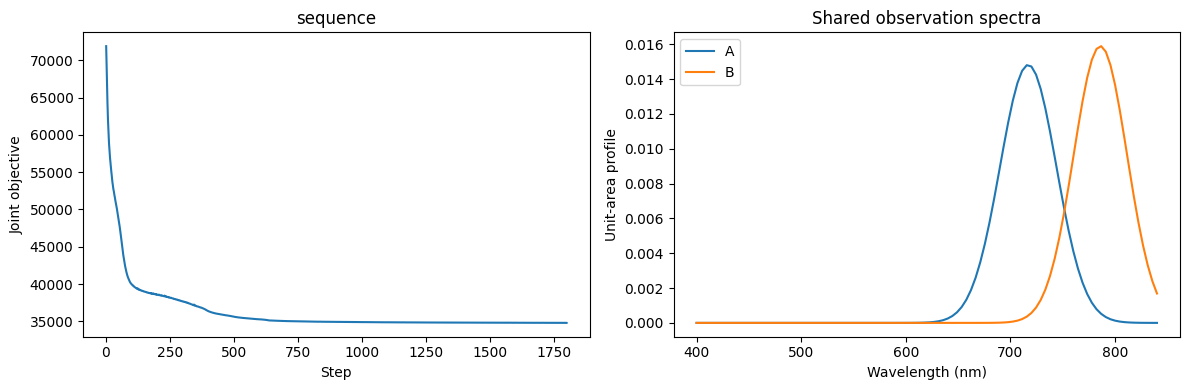

In [27]:
# ================================================================
# Reaction-network latent model + GP concentration fields
#
# Requires data prepared by the earlier physical-model cell:
#   C, Y, Ys, mask, wl, times, signal_scale, wells
#   train_indices, test_indices, concentration_scaler
#
# Latent dynamics:
#   dn/dt = M(k(c)) n
#
# Observation:
#   PL = brightness(c) * [nA * spectrumA + nB * spectrumB]
#
# Population normalization:
#   nA(0) + nB(0) = 1; nD(0) = 0.
#
# D is non-emitting. Spectral profiles are shared across concentration.
# ================================================================

import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
import ipywidgets as widgets
from IPython.display import display, clear_output
from scipy.spatial import Delaunay, QhullError

# ---------------------------- Controls -----------------------------
NETWORK = "sequence"
# "conversion":      A -> B
# "reversible":      A <-> B
# "sequence":        A -> B -> D
# "reversible_loss": A <-> B, A -> D, B -> D

STEPS = 1800
LEARNING_RATE = 0.02
HOST_LENGTH_SCALE = 0.8
ADDITIVE_LENGTH_SCALE = 0.8
DENSE_GRID_SIZE = 80
STUDENT_DF = 4.0
EFFECTIVE_PIXELS_PER_SPECTRUM = 10.0
NOISE_SCALE = 0.05          # in globally scaled intensity units
SEED = 42

# Equal intrinsic detected brightness per population is the default.
# Allowing a fitted B/A brightness ratio adds an identifiability tradeoff.
FIT_BRIGHTNESS_RATIO = False

network_rates = {
    "conversion": ["kAB"],
    "reversible": ["kAB", "kBA"],
    "sequence": ["kAB", "kBD"],
    "reversible_loss": ["kAB", "kBA", "kAD", "kBD"],
}
if NETWORK not in network_rates:
    raise ValueError("Unknown NETWORK.")

rate_names = network_rates[NETWORK]
field_names = rate_names + ["initial_A_fraction", "brightness"]
RATES = len(rate_names)
FIELDS = len(field_names)

torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float64

def tt(value):
    return torch.as_tensor(value, dtype=dtype, device=device)

N = len(C)
train_C = concentration_scaler.transform(C[train_indices])
all_C = concentration_scaler.transform(C)
length_scales = np.array([HOST_LENGTH_SCALE, ADDITIVE_LENGTH_SCALE])

# ================================================================
# 1. GP covariance and concentration field representation
# ================================================================

def kernel(a, b):
    delta = (a[:, None] - b[None]) / length_scales
    distance = np.sqrt(np.sum(delta**2, axis=-1))
    r = np.sqrt(3.0) * distance
    return (1+r) * np.exp(-r)

K = kernel(train_C, train_C) + 1e-5*np.eye(len(train_C))
L = np.linalg.cholesky(K)
L_t = tt(L)

wl_t = tt(wl)
elapsed_times = np.asarray(times) - times[0]
time_t = tt(elapsed_times)

training_mask = tt(mask[train_indices].astype(float))
training_data = tt(np.nan_to_num(Ys[train_indices], nan=0))
valid_counts = training_mask.sum(dim=-1)
valid_spectra = valid_counts > 0

# Brightness initialization: typical integrated training PL.
mean_training_spectrum = np.nanmean(
    Ys[train_indices].reshape(-1, len(wl)), axis=0
)
background_initial = float(np.nanpercentile(mean_training_spectrum, 10))
positive_spectrum = np.maximum(
    np.nan_to_num(mean_training_spectrum) - background_initial, 0
)
brightness_initial = max(
    np.trapezoid(positive_spectrum, wl)
    if hasattr(np, "trapezoid")
    else np.trapz(positive_spectrum, wl),
    1e-3,
)

# GP coordinates have a defined physical transformation.
# log rates = log(1/150 min) + field
# initial A fraction = sigmoid(logit(0.9) + field)
# log brightness = log(initial brightness) + field
base_coordinates = np.r_[
    np.full(RATES, np.log(1/150)),
    np.log(0.9/0.1),
    np.log(brightness_initial),
]
base_t = tt(base_coordinates)

# ================================================================
# 2. Shared emission spectra and reaction-network decoder
# ================================================================

def inverse_sigmoid(value):
    value = np.clip(value, 1e-4, 1-1e-4)
    return np.log(value/(1-value))

peak = wl[np.argmax(positive_spectrum)]
center_A_initial = np.clip(peak-15, wl[0]+5, wl[-1]-20)
center_B_initial = np.clip(peak+15, center_A_initial+5, wl[-1]-2)

class ReactionGP(nn.Module):
    def __init__(self):
        super().__init__()
        self.field_mean = nn.Parameter(tt(np.zeros(FIELDS)))
        self.white_fields = nn.Parameter(
            tt(np.random.default_rng(SEED).normal(
                0, 0.01, (len(train_indices), FIELDS)
            ))
        )

        self.center_A_raw = nn.Parameter(tt(inverse_sigmoid(
            (center_A_initial-wl[0])/(wl[-1]-wl[0])
        )))
        self.separation_raw = nn.Parameter(tt(inverse_sigmoid(
            (center_B_initial-center_A_initial)/(wl[-1]-center_A_initial)
        )))
        self.width_raw = nn.Parameter(tt(np.full(
            2, inverse_sigmoid((20-4)/(100-4))
        )))
        self.log_bottom_gain = nn.Parameter(tt(0.0))
        self.background = nn.Parameter(
            tt([background_initial, background_initial])
        )

        self.log_B_brightness_ratio = nn.Parameter(
            tt(0.0), requires_grad=FIT_BRIGHTNESS_RATIO
        )

    def training_fields(self):
        return self.field_mean[None] + L_t @ self.white_fields

    def spectral_profiles(self):
        center_A = wl_t[0] + (wl_t[-1]-wl_t[0]) * torch.sigmoid(
            self.center_A_raw
        )
        center_B = center_A + (wl_t[-1]-center_A) * torch.sigmoid(
            self.separation_raw
        )
        widths = 4 + 96*torch.sigmoid(self.width_raw)
        centers = torch.stack([center_A, center_B])

        profiles = torch.exp(
            -0.5*((wl_t[None]-centers[:, None])/widths[:, None])**2
        )
        profiles = profiles / torch.trapezoid(
            profiles, wl_t, dim=-1
        ).clamp_min(1e-12)[:, None]
        return profiles, centers, widths

    def physical_fields(self, fields):
        coordinates = base_t[None] + fields
        # Numerical guards; inspect if fitted values approach them.
        rates = torch.exp(coordinates[:, :RATES].clamp(-16, 0))
        fraction_A = torch.sigmoid(coordinates[:, RATES])
        brightness = torch.exp(coordinates[:, RATES+1].clamp(-15, 15))
        return rates, fraction_A, brightness

    def emit(self, fields):
        rates, fraction_A, brightness = self.physical_fields(fields)
        count = len(fields)
        zero = torch.zeros(count, dtype=dtype, device=device)

        rate_dict = {name: rates[:, j] for j, name in enumerate(rate_names)}
        kAB = rate_dict.get("kAB", zero)
        kBA = rate_dict.get("kBA", zero)
        kAD = rate_dict.get("kAD", zero)
        kBD = rate_dict.get("kBD", zero)

        # Column-state convention: dn/dt = M @ n.
        matrix = torch.stack([
            torch.stack([-(kAB+kAD), kBA, zero], dim=-1),
            torch.stack([kAB, -(kBA+kBD), zero], dim=-1),
            torch.stack([kAD, kBD, zero], dim=-1),
        ], dim=1)

        initial = torch.stack([
            fraction_A, 1-fraction_A, zero
        ], dim=-1)

        propagator = torch.matrix_exp(
            matrix[:, None] * time_t[None, :, None, None]
        )
        populations = (
            propagator @ initial[:, None, :, None]
        ).squeeze(-1)

        profiles, centers, widths = self.spectral_profiles()
        ratio_B = torch.exp(self.log_B_brightness_ratio.clamp(-5, 5))
        emission = (
            populations[:, :, 0, None] * profiles[0][None, None]
            + ratio_B * populations[:, :, 1, None] * profiles[1][None, None]
        ) * brightness[:, None, None]

        top = emission + self.background[0]
        bottom = (
            torch.exp(self.log_bottom_gain.clamp(-5, 5)) * emission
            + self.background[1]
        )
        return torch.stack([top, bottom], dim=1), populations

reaction_model = ReactionGP().to(device)

# ================================================================
# 3. Joint robust spectral fitting + GP regularization
# ================================================================

optimizer = torch.optim.Adam(
    reaction_model.parameters(), lr=LEARNING_RATE
)
fit_history = []
best_loss = np.inf
best_state = None

for step in range(1, STEPS+1):
    optimizer.zero_grad()
    prediction, populations = reaction_model.emit(
        reaction_model.training_fields()
    )
    residual = (prediction-training_data)/NOISE_SCALE

    pixel_loss = 0.5*(STUDENT_DF+1)*torch.log1p(
        residual.square()/STUDENT_DF
    )
    spectrum_loss = (
        (pixel_loss*training_mask).sum(dim=-1)
        / valid_counts.clamp_min(1)
    )
    spectral_loss = (
        EFFECTIVE_PIXELS_PER_SPECTRUM
        * spectrum_loss[valid_spectra].sum()
    )

    gp_penalty = 0.5*reaction_model.white_fields.square().sum()
    mean_penalty = 0.5*(reaction_model.field_mean/3).square().sum()
    observation_penalty = (
        0.5*(reaction_model.log_bottom_gain/2).square()
        + 0.5*(reaction_model.background/0.5).square().sum()
        + 0.5*reaction_model.log_B_brightness_ratio.square()
    )
    loss = spectral_loss + gp_penalty + mean_penalty + observation_penalty

    # Save parameters corresponding to the evaluated objective.
    if float(loss.detach()) < best_loss:
        best_loss = float(loss.detach())
        best_state = copy.deepcopy(reaction_model.state_dict())

    loss.backward()
    torch.nn.utils.clip_grad_norm_(reaction_model.parameters(), 100)
    optimizer.step()

    fit_history.append({
        "step": step,
        "objective": float(loss.detach()),
        "spectral_loss": float(spectral_loss.detach()),
        "GP_penalty": float(gp_penalty.detach()),
    })
    if step == 1 or step % 200 == 0:
        print(
            f"Step {step}: objective={float(loss.detach()):.2f}; "
            f"spectral={float(spectral_loss.detach()):.2f}; "
            f"GP={float(gp_penalty.detach()):.2f}"
        )

reaction_model.load_state_dict(best_state)
reaction_model.eval()

# ================================================================
# 4. Interpolate joint GP fields at new concentrations
# ================================================================

with torch.no_grad():
    learned_fields = reaction_model.training_fields().cpu().numpy()
    learned_mean = reaction_model.field_mean.cpu().numpy()

gp_alpha = np.linalg.solve(K, learned_fields-learned_mean)

def predict_reaction(concentration_points):
    points = np.asarray(concentration_points).reshape(-1, 2)
    standardized = concentration_scaler.transform(points)
    fields = learned_mean[None] + kernel(standardized, train_C) @ gp_alpha

    with torch.no_grad():
        fields_t = tt(fields)
        surfaces, populations = reaction_model.emit(fields_t)
        rates, initial_A, brightness = reaction_model.physical_fields(fields_t)

    return {
        "surfaces": surfaces.cpu().numpy()*signal_scale,
        "populations": populations.cpu().numpy(),
        "rates": rates.cpu().numpy(),
        "initial_A": initial_A.cpu().numpy(),
        "brightness": brightness.cpu().numpy()*signal_scale,
        "fields": fields,
    }

reaction_predictions = predict_reaction(C)

# ================================================================
# 5. Held-out concentration prediction metrics
# ================================================================

def reaction_metrics(indices):
    rows = []
    for i in indices:
        observed = mask[i]
        actual = Y[i][observed]
        predicted = reaction_predictions["surfaces"][i][observed]
        residual = actual-predicted
        rows.append({
            "well": wells[i],
            "RMSE": np.sqrt(np.mean(residual**2)),
            "relative_L2":
                np.linalg.norm(residual)/max(np.linalg.norm(actual), 1e-15),
            "MSE": np.mean(residual**2),
        })
    return pd.DataFrame(rows)

reaction_test_metrics = reaction_metrics(test_indices)
display(reaction_test_metrics.describe().loc[["mean", "50%", "max"]])

# Training-mean comparison.
training_mean_surface = np.nanmean(Y[train_indices], axis=0)
baseline_mse, model_mse = [], []
for i in test_indices:
    observed = mask[i] & np.isfinite(training_mean_surface)
    if observed.any():
        baseline_mse.append(np.mean(
            (Y[i][observed]-training_mean_surface[observed])**2
        ))
        model_mse.append(np.mean(
            (Y[i][observed]
             - reaction_predictions["surfaces"][i][observed])**2
        ))
print(
    "Held-out skill against training-mean surface:",
    1-np.sum(model_mse)/np.sum(baseline_mse)
    if np.sum(baseline_mse) > 0 else np.nan,
)

# Numerical conservation check.
population_sums = reaction_predictions["populations"].sum(axis=-1)
print("Maximum population-conservation error:",
      np.max(np.abs(population_sums-1)))
print("Minimum inferred population:",
      reaction_predictions["populations"].min())

with torch.no_grad():
    profiles, centers, widths = reaction_model.spectral_profiles()
    print("Shared band centers (nm):", centers.cpu().numpy())
    print("Shared band widths, Gaussian sigma (nm):", widths.cpu().numpy())
    print("Bottom/Top gain:",
          float(torch.exp(reaction_model.log_bottom_gain.clamp(-5, 5))))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history_df = pd.DataFrame(fit_history)
axes[0].plot(history_df["step"], history_df["objective"])
axes[0].set(xlabel="Step", ylabel="Joint objective", title=NETWORK)
for j, label in enumerate(["A", "B"]):
    axes[1].plot(wl, profiles[j].cpu().numpy(), label=label)
axes[1].set(xlabel="Wavelength (nm)", ylabel="Unit-area profile",
            title="Shared observation spectra")
axes[1].legend()
plt.tight_layout()
plt.show()

# ================================================================
# 6. Dense concentration maps of rates and initial conditions
# ================================================================

host_axis = np.linspace(C[:, 0].min(), C[:, 0].max(), DENSE_GRID_SIZE)
additive_axis = np.linspace(C[:, 1].min(), C[:, 1].max(), DENSE_GRID_SIZE)
HOST, ADDITIVE = np.meshgrid(host_axis, additive_axis)
dense_C = np.column_stack([HOST.ravel(), ADDITIVE.ravel()])

# Evaluate fields only; avoid generating every dense-grid surface.
dense_standardized = concentration_scaler.transform(dense_C)
dense_fields = learned_mean[None] + kernel(dense_standardized, train_C) @ gp_alpha
with torch.no_grad():
    dense_rates, dense_initial_A, dense_brightness = (
        reaction_model.physical_fields(tt(dense_fields))
    )

dense_maps = {
    name + " (min⁻¹)": dense_rates[:, j].cpu().numpy()
    for j, name in enumerate(rate_names)
}
dense_maps["Initial A fraction"] = dense_initial_A.cpu().numpy()
dense_maps["Detected brightness scale"] = (
    dense_brightness.cpu().numpy()*signal_scale
)
for j, name in enumerate(rate_names):
    dense_maps["1/" + name + " (min)"] = (
        1/dense_rates[:, j].cpu().numpy()
    )

try:
    hull = Delaunay(np.unique(C[train_indices], axis=0))
    support = hull.find_simplex(dense_C) >= 0
except QhullError:
    support = np.ones(len(dense_C), dtype=bool)

map_control = widgets.Dropdown(
    options=list(dense_maps), description="Field:",
    style={"description_width": "initial"},
)
map_output = widgets.Output()

def draw_rate_map(change=None):
    with map_output:
        clear_output(wait=True)
        name = map_control.value
        values = np.where(support, dense_maps[name], np.nan).reshape(HOST.shape)

        fig, ax = plt.subplots(figsize=(9, 6))
        image = ax.pcolormesh(
            HOST*100, ADDITIVE, np.ma.masked_invalid(values),
            shading="auto", cmap="viridis",
        )
        ax.scatter(
            C[train_indices, 0]*100, C[train_indices, 1],
            s=25, facecolors="none", edgecolors="white", label="Training",
        )
        ax.scatter(
            C[test_indices, 0]*100, C[test_indices, 1],
            s=40, marker="x", color="red", label="Held-out",
        )
        ax.set(
            xlabel="FAPbI3 host (%)", ylabel="Nominal MACl level (%)",
            title=f"{NETWORK}: jointly fitted {name}",
        )
        ax.legend()
        fig.colorbar(image, ax=ax, label=name)
        plt.tight_layout()
        plt.show()
        plt.close(fig)

map_control.observe(draw_rate_map, names="value")
display(widgets.VBox([map_control, map_output]))
draw_rate_map()

# ================================================================
# 7. Concentration controls: populations and emitted spectral surfaces
# ================================================================

host_control = widgets.FloatSlider(
    min=float(C[:, 0].min()), max=float(C[:, 0].max()),
    value=float(np.median(C[:, 0])), step=0.01,
    description="Host fraction:", continuous_update=False,
    style={"description_width": "initial"},
)
additive_control = widgets.FloatSlider(
    min=float(C[:, 1].min()), max=float(C[:, 1].max()),
    value=float(np.median(C[:, 1])), step=0.1,
    description="MACl level:", continuous_update=False,
    style={"description_width": "initial"},
)
surface_output = widgets.Output()
color_max = float(np.nanpercentile(Y[train_indices], 99))
color_min = min(0, float(np.nanpercentile(Y[train_indices], 1)))

def draw_reaction_surface(change=None):
    with surface_output:
        clear_output(wait=True)
        prediction = predict_reaction([[
            host_control.value, additive_control.value
        ]])
        fig, axes = plt.subplots(1, 3, figsize=(17, 5))

        for g, geometry in enumerate(["Top PL", "Bottom PL"]):
            image = axes[g].pcolormesh(
                wl, times, prediction["surfaces"][0, g],
                shading="auto", cmap="magma",
                vmin=color_min, vmax=color_max,
            )
            axes[g].set(
                xlabel="Wavelength (nm)", ylabel="Time (min)",
                title=geometry,
            )
            fig.colorbar(image, ax=axes[g], label="PL instrument units")

        for s, name in enumerate(["A", "B", "D"]):
            axes[2].plot(
                times, prediction["populations"][0, :, s], label=name
            )
        axes[2].set(
            xlabel="Time (min)", ylabel="Population fraction",
            ylim=(-0.02, 1.02), title="Latent reaction-network evolution",
        )
        axes[2].legend()
        plt.tight_layout()
        plt.show()
        plt.close(fig)

        display(pd.Series({
            **dict(zip(rate_names, prediction["rates"][0])),
            "initial_A_fraction": prediction["initial_A"][0],
            "brightness_scale": prediction["brightness"][0],
        }, name="Generated parameters").to_frame())

host_control.observe(draw_reaction_surface, names="value")
additive_control.observe(draw_reaction_surface, names="value")
display(widgets.VBox([
    widgets.HBox([host_control, additive_control]),
    surface_output,
]))
draw_reaction_surface()

# ================================================================
# 8. Measured well: observed surfaces, predictions, residuals
# ================================================================

well_control = widgets.Dropdown(
    options=list(wells),
    value="H7" if "H7" in wells else wells[0],
    description="Well:",
)
well_output = widgets.Output()
well_lookup = {w: i for i, w in enumerate(wells)}

def draw_measured_well(change=None):
    with well_output:
        clear_output(wait=True)
        i = well_lookup[well_control.value]
        fig, axes = plt.subplots(2, 3, figsize=(15, 9))

        for g, geometry in enumerate(["Top PL", "Bottom PL"]):
            predicted = reaction_predictions["surfaces"][i, g]
            residual = np.where(mask[i, g], Y[i, g]-predicted, np.nan)
            panels = [Y[i, g], predicted, residual]

            for p, panel in enumerate(panels):
                if p == 2:
                    bound = max(float(np.nanmax(np.abs(panel))), 1e-12)
                    lo, hi, cmap = -bound, bound, "RdBu_r"
                else:
                    lo, hi, cmap = color_min, color_max, "magma"

                colormap = plt.get_cmap(cmap).copy()
                colormap.set_bad("#bdbdbd")
                image = axes[g, p].pcolormesh(
                    wl, times, np.ma.masked_invalid(panel),
                    shading="auto", cmap=colormap, vmin=lo, vmax=hi,
                )
                axes[g, p].set(
                    xlabel="Wavelength (nm)", ylabel="Time (min)",
                    title=f"{geometry}: "
                          f"{['observed', 'network prediction', 'residual'][p]}",
                )
                fig.colorbar(image, ax=axes[g, p], shrink=0.8)

        status = "held-out" if i in test_indices else "training"
        fig.suptitle(f"{wells[i]} | {status} | {NETWORK}")
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()
        plt.close(fig)

well_control.observe(draw_measured_well, names="value")
display(widgets.VBox([well_control, well_output]))
draw_measured_well()

# Reusable outputs:
# reaction_model, reaction_predictions, reaction_test_metrics
# dense_maps, HOST, ADDITIVE, predict_reaction(...)

In [28]:
# ================================================================
# Composition-evolving solid-solution emission model
#
# Run after the reaction-network cell.
#
# Reuses prepared data and GP infrastructure:
# C, Y, Ys, mask, wl, times, signal_scale, wells
# train_indices, test_indices, concentration_scaler
# kernel, train_C, K, L_t, tt, device, dtype
# training_data, training_mask, valid_counts, valid_spectra
#
# Models ONE continuously shifting emission band.
# ================================================================

import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
import ipywidgets as widgets
from IPython.display import display, clear_output

# ---------------------------- Controls -----------------------------
SHIFT_STEPS = 1800
SHIFT_LR = 0.02
SHIFT_NOISE_SCALE = 0.05
SHIFT_EFFECTIVE_PIXELS = 10.0
SHIFT_STUDENT_DF = 4.0
SHIFT_GRID_SIZE = 80

HC_EV_NM = 1239.841984

# Enter independently calibrated endpoint emission energies if known.
# If None, data-derived endpoints define an EFFECTIVE optical coordinate.
ENDPOINT_A_EV = None
ENDPOINT_B_EV = None
BOWING_EV = 0.0              # fixed initially; avoid fitting with unknown endpoints

# ---------------------------------------------------------------
# 1. Establish the composition -> emission-energy relationship
# ---------------------------------------------------------------

training_spectra = Ys[train_indices].reshape(-1, len(wl))
complete = np.isfinite(training_spectra).all(axis=1)
training_spectra = training_spectra[complete]

if not len(training_spectra):
    raise ValueError("No complete training spectra.")

peak_wavelengths = wl[np.argmax(training_spectra, axis=1)]
peak_energies = HC_EV_NM / peak_wavelengths

energy_min = HC_EV_NM / wl[-1]
energy_max = HC_EV_NM / wl[0]

calibrated_endpoints = (
    ENDPOINT_A_EV is not None and ENDPOINT_B_EV is not None
)

if (ENDPOINT_A_EV is None) != (ENDPOINT_B_EV is None):
    raise ValueError("Provide both endpoint energies, or neither.")

if not calibrated_endpoints:
    low, high = np.percentile(peak_energies, [5, 95])
    padding = max(0.03, 0.2*(high-low))
    ENDPOINT_A_EV = max(energy_min + 1e-4, low-padding)
    ENDPOINT_B_EV = min(energy_max - 1e-4, high+padding)
    print(
        "Using data-derived energy endpoints. "
        "x is an effective optical coordinate, not measured composition."
    )

EA = float(ENDPOINT_A_EV)
EB = float(ENDPOINT_B_EV)
bowing = float(BOWING_EV)

if EB <= EA:
    raise ValueError(
        "This depletion/redshift model assumes ENDPOINT_B_EV > ENDPOINT_A_EV."
    )
if abs(bowing) >= EB-EA:
    raise ValueError(
        "Choose |BOWING_EV| < endpoint separation for a monotonic energy relation."
    )

print(f"Emission-energy endpoints: {EA:.4f}, {EB:.4f} eV")

# ---------------------------------------------------------------
# 2. Concentration-dependent GP fields
#
# Fields:
#   initial composition
#   retained fraction: x_inf / x0
#   composition-evolution rate
#   initial integrated brightness
#   final / initial brightness ratio
#   brightness-evolution rate
# ---------------------------------------------------------------

shift_field_names = [
    "initial_composition_logit",
    "retained_fraction_logit",
    "log_composition_rate",
    "log_initial_brightness",
    "log_final_initial_brightness_ratio",
    "log_brightness_rate",
]

mean_spectrum = np.mean(training_spectra, axis=0)
background0 = float(np.percentile(mean_spectrum, 10))
positive_mean = np.maximum(mean_spectrum-background0, 0)

brightness0 = max(
    np.trapezoid(positive_mean, wl)
    if hasattr(np, "trapezoid") else np.trapz(positive_mean, wl),
    1e-3,
)

base_values = np.array([
    np.log(0.8/0.2),        # x0 ≈ 0.8
    np.log(0.6/0.4),        # x_inf ≈ 0.6 x0
    np.log(1/150),         # composition rate, min^-1
    np.log(brightness0),
    0.0,                   # initial and final brightness equal initially
    np.log(1/150),
])
base_values_t = tt(base_values)
wl_shift_t = tt(wl)
time_shift_t = tt(np.asarray(times)-times[0])
energy_grid_t = HC_EV_NM / wl_shift_t
jacobian_t = HC_EV_NM / wl_shift_t.square()

class CompositionShiftGP(nn.Module):
    def __init__(self):
        super().__init__()
        self.field_mean = nn.Parameter(tt(np.zeros(6)))
        self.white_fields = nn.Parameter(tt(
            np.random.default_rng(42).normal(
                0, 0.01, (len(train_indices), 6)
            )
        ))
        # Shared energy width: bounded between 0.005 and 0.20 eV.
        width_fraction = (0.04-0.005)/(0.20-0.005)
        self.width_raw = nn.Parameter(tt(
            np.log(width_fraction/(1-width_fraction))
        ))
        self.log_bottom_gain = nn.Parameter(tt(0.0))
        self.background = nn.Parameter(tt([background0, background0]))

    def training_fields(self):
        return self.field_mean[None] + L_t @ self.white_fields

    def parameters_from_fields(self, fields):
        u = base_values_t[None] + fields
        x0 = torch.sigmoid(u[:, 0])
        retained = torch.sigmoid(u[:, 1])
        x_inf = x0 * retained
        k = torch.exp(u[:, 2].clamp(-16, 0))
        a0 = torch.exp(u[:, 3].clamp(-15, 15))
        a_inf = a0 * torch.exp(u[:, 4].clamp(-8, 8))
        k_brightness = torch.exp(u[:, 5].clamp(-16, 0))
        return x0, x_inf, k, a0, a_inf, k_brightness

    def emit(self, fields):
        x0, x_inf, k, a0, a_inf, kb = self.parameters_from_fields(fields)
        t = time_shift_t[None]

        x = (
            x_inf[:, None]
            + (x0-x_inf)[:, None] * torch.exp(-k[:, None]*t)
        )
        # Reservoir holds the depleted constituent, in normalized units.
        reservoir = x0[:, None]-x

        emission_energy = (
            (1-x)*EA + x*EB - bowing*x*(1-x)
        )
        amplitude = (
            a_inf[:, None]
            + (a0-a_inf)[:, None] * torch.exp(-kb[:, None]*t)
        )
        sigma_energy = (
            0.005 + (0.20-0.005)*torch.sigmoid(self.width_raw)
        )

        # Gaussian spectral density in energy.
        energy_profile = torch.exp(
            -0.5*(
                (energy_grid_t[None, None]-emission_energy[:, :, None])
                / sigma_energy
            )**2
        )

        # Convert density per eV to density per nm.
        wavelength_profile = energy_profile * jacobian_t[None, None]
        area = torch.trapezoid(
            wavelength_profile, wl_shift_t, dim=-1
        ).clamp_min(1e-12)
        wavelength_profile = wavelength_profile / area[:, :, None]

        surface = amplitude[:, :, None]*wavelength_profile
        top = surface+self.background[0]
        bottom = (
            torch.exp(self.log_bottom_gain.clamp(-5, 5))*surface
            + self.background[1]
        )
        return {
            "surfaces": torch.stack([top, bottom], dim=1),
            "composition": x,
            "reservoir": reservoir,
            "emission_energy": emission_energy,
            "amplitude": amplitude,
        }

shift_model = CompositionShiftGP().to(device)

# ---------------------------------------------------------------
# 3. Joint spectral fit with GP concentration regularization
# ---------------------------------------------------------------

optimizer = torch.optim.Adam(shift_model.parameters(), lr=SHIFT_LR)
best_loss = np.inf
best_state = None
shift_history = []

for step in range(1, SHIFT_STEPS+1):
    optimizer.zero_grad()
    output = shift_model.emit(shift_model.training_fields())
    residual = (
        output["surfaces"]-training_data
    ) / SHIFT_NOISE_SCALE

    pixel_loss = 0.5*(SHIFT_STUDENT_DF+1)*torch.log1p(
        residual.square()/SHIFT_STUDENT_DF
    )
    spectrum_loss = (
        (pixel_loss*training_mask).sum(dim=-1)
        / valid_counts.clamp_min(1)
    )
    spectral_loss = (
        SHIFT_EFFECTIVE_PIXELS*spectrum_loss[valid_spectra].sum()
    )
    gp_penalty = 0.5*shift_model.white_fields.square().sum()
    mean_penalty = 0.5*(shift_model.field_mean/3).square().sum()
    observation_penalty = (
        0.5*(shift_model.log_bottom_gain/2).square()
        + 0.5*(shift_model.background/0.5).square().sum()
    )

    loss = spectral_loss+gp_penalty+mean_penalty+observation_penalty

    if float(loss.detach()) < best_loss:
        best_loss = float(loss.detach())
        best_state = copy.deepcopy(shift_model.state_dict())

    loss.backward()
    torch.nn.utils.clip_grad_norm_(shift_model.parameters(), 100)
    optimizer.step()

    shift_history.append({
        "step": step,
        "objective": float(loss.detach()),
        "spectral_loss": float(spectral_loss.detach()),
        "GP_penalty": float(gp_penalty.detach()),
    })
    if step == 1 or step % 200 == 0:
        print(
            f"Step {step}: objective={float(loss.detach()):.2f}; "
            f"spectral={float(spectral_loss.detach()):.2f}"
        )

shift_model.load_state_dict(best_state)
shift_model.eval()

# ---------------------------------------------------------------
# 4. Predict fields, latent trajectories, and emitted surfaces
# ---------------------------------------------------------------

with torch.no_grad():
    fitted_fields = shift_model.training_fields().cpu().numpy()
    fitted_mean = shift_model.field_mean.cpu().numpy()

shift_gp_alpha = np.linalg.solve(K, fitted_fields-fitted_mean)

def predict_shift(concentration_points, emit_surfaces=True):
    points = np.asarray(concentration_points).reshape(-1, 2)
    standardized = concentration_scaler.transform(points)
    fields = (
        fitted_mean[None]
        + kernel(standardized, train_C) @ shift_gp_alpha
    )
    with torch.no_grad():
        fields_t = tt(fields)
        parameters = shift_model.parameters_from_fields(fields_t)
        result = {
            name: value.cpu().numpy()
            for name, value in zip(
                ["x0", "x_inf", "k", "A0", "A_inf", "k_brightness"],
                parameters,
            )
        }
        if emit_surfaces:
            output = shift_model.emit(fields_t)
            result.update({
                name: value.cpu().numpy()
                for name, value in output.items()
            })
            result["surfaces"] *= signal_scale
            result["amplitude"] *= signal_scale

    result["A0"] *= signal_scale
    result["A_inf"] *= signal_scale
    return result

shift_predictions = predict_shift(C)

# ---------------------------------------------------------------
# 5. Held-out spectral and peak prediction metrics
# ---------------------------------------------------------------

metric_rows = []
for i in test_indices:
    observed = mask[i]
    actual = Y[i][observed]
    predicted = shift_predictions["surfaces"][i][observed]

    peak_errors = []
    for g in range(2):
        for j in range(len(times)):
            if mask[i, g, j].all():
                actual_peak = wl[np.argmax(Y[i, g, j])]
                predicted_peak = wl[np.argmax(
                    shift_predictions["surfaces"][i, g, j]
                )]
                peak_errors.append(abs(actual_peak-predicted_peak))

    metric_rows.append({
        "well": wells[i],
        "RMSE": np.sqrt(np.mean((actual-predicted)**2)),
        "relative_L2":
            np.linalg.norm(actual-predicted)
            / max(np.linalg.norm(actual), 1e-15),
        "peak_MAE_nm": np.mean(peak_errors) if peak_errors else np.nan,
    })

shift_test_metrics = pd.DataFrame(metric_rows)
display(shift_test_metrics)
display(shift_test_metrics.drop(columns="well").mean().to_frame("mean"))

print(
    "Maximum normalized constituent-balance error:",
    np.max(np.abs(
        shift_predictions["composition"]
        + shift_predictions["reservoir"]
        - shift_predictions["x0"][:, None]
    )),
)

# ---------------------------------------------------------------
# 6. Dense concentration maps
# ---------------------------------------------------------------

host_axis = np.linspace(C[:, 0].min(), C[:, 0].max(), SHIFT_GRID_SIZE)
additive_axis = np.linspace(C[:, 1].min(), C[:, 1].max(), SHIFT_GRID_SIZE)
HOST_SHIFT, ADDITIVE_SHIFT = np.meshgrid(host_axis, additive_axis)
dense_C_shift = np.column_stack([
    HOST_SHIFT.ravel(), ADDITIVE_SHIFT.ravel()
])
dense_parameters = predict_shift(dense_C_shift, emit_surfaces=False)

shift_maps = {
    "Initial internal composition x0": dense_parameters["x0"],
    "Long-time internal composition x_inf": dense_parameters["x_inf"],
    "Depletion extent x0 - x_inf":
        dense_parameters["x0"]-dense_parameters["x_inf"],
    "Composition-evolution rate (min⁻¹)": dense_parameters["k"],
    "Composition-evolution timescale (min)": 1/dense_parameters["k"],
    "Initial integrated brightness": dense_parameters["A0"],
    "Final integrated brightness": dense_parameters["A_inf"],
}

try:
    hull = Delaunay(np.unique(C[train_indices], axis=0))
    support = hull.find_simplex(dense_C_shift) >= 0
except QhullError:
    support = np.ones(len(dense_C_shift), dtype=bool)

map_control = widgets.Dropdown(
    options=list(shift_maps), description="Field:",
    style={"description_width": "initial"},
)
map_output = widgets.Output()

def draw_shift_map(change=None):
    with map_output:
        clear_output(wait=True)
        name = map_control.value
        values = np.where(
            support, shift_maps[name], np.nan
        ).reshape(HOST_SHIFT.shape)

        fig, ax = plt.subplots(figsize=(9, 6))
        image = ax.pcolormesh(
            HOST_SHIFT*100, ADDITIVE_SHIFT,
            np.ma.masked_invalid(values),
            shading="auto", cmap="viridis",
        )
        ax.scatter(
            C[train_indices, 0]*100, C[train_indices, 1],
            facecolors="none", edgecolors="white", s=25,
        )
        ax.scatter(
            C[test_indices, 0]*100, C[test_indices, 1],
            marker="x", color="red", s=35,
        )
        ax.set(
            xlabel="FAPbI3 host (%)", ylabel="Nominal MACl level (%)",
            title=name,
        )
        fig.colorbar(image, ax=ax, label=name)
        plt.tight_layout()
        plt.show()
        plt.close(fig)

map_control.observe(draw_shift_map, names="value")
display(widgets.VBox([map_control, map_output]))
draw_shift_map()

# ---------------------------------------------------------------
# 7. Concentration controls: generated spectra and latent evolution
# ---------------------------------------------------------------

host_control = widgets.FloatSlider(
    min=float(C[:, 0].min()), max=float(C[:, 0].max()),
    value=float(np.median(C[:, 0])), step=0.01,
    description="Host fraction:", continuous_update=False,
    style={"description_width": "initial"},
)
additive_control = widgets.FloatSlider(
    min=float(C[:, 1].min()), max=float(C[:, 1].max()),
    value=float(np.median(C[:, 1])), step=0.1,
    description="MACl level:", continuous_update=False,
    style={"description_width": "initial"},
)
surface_output = widgets.Output()
fixed_max = float(np.nanpercentile(Y[train_indices], 99))
fixed_min = min(0, float(np.nanpercentile(Y[train_indices], 1)))

def draw_shift_surface(change=None):
    with surface_output:
        clear_output(wait=True)
        prediction = predict_shift([[
            host_control.value, additive_control.value
        ]])
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        for g, geometry in enumerate(["Top PL", "Bottom PL"]):
            image = axes[0, g].pcolormesh(
                wl, times, prediction["surfaces"][0, g],
                shading="auto", cmap="magma",
                vmin=fixed_min, vmax=fixed_max,
            )
            axes[0, g].set(
                xlabel="Wavelength (nm)", ylabel="Time (min)",
                title=f"Generated {geometry}",
            )
            fig.colorbar(image, ax=axes[0, g], label="PL instrument units")

        axes[1, 0].plot(
            times, prediction["composition"][0],
            label="Emitting-solid coordinate x(t)",
        )
        axes[1, 0].plot(
            times, prediction["reservoir"][0],
            label="Transferred constituent",
        )
        axes[1, 0].set(
            xlabel="Time (min)", ylabel="Normalized constituent amount",
            title="Composition evolution and balance",
        )
        axes[1, 0].legend()

        # Energy center is not exactly the wavelength-density peak
        # after applying the energy-to-wavelength Jacobian.
        center_wavelength = (
            HC_EV_NM/prediction["emission_energy"][0]
        )
        surface_peak = wl[np.argmax(
            prediction["surfaces"][0, 0], axis=-1
        )]
        axes[1, 1].plot(
            times, center_wavelength,
            label="Wavelength corresponding to energy center",
        )
        axes[1, 1].plot(
            times, surface_peak, "--", label="Decoded wavelength peak",
        )
        axes[1, 1].set(
            xlabel="Time (min)", ylabel="Wavelength (nm)",
            title="Generated peak shift",
        )
        axes[1, 1].legend(fontsize=8)

        plt.tight_layout()
        plt.show()
        plt.close(fig)

        display(pd.Series({
            "x0": prediction["x0"][0],
            "x_inf": prediction["x_inf"][0],
            "composition_rate_min^-1": prediction["k"][0],
            "composition_timescale_min": 1/prediction["k"][0],
        }, name="Generated parameters").to_frame())

host_control.observe(draw_shift_surface, names="value")
additive_control.observe(draw_shift_surface, names="value")
display(widgets.VBox([
    widgets.HBox([host_control, additive_control]), surface_output
]))
draw_shift_surface()

# ---------------------------------------------------------------
# 8. Selected measured well: prediction and residual evidence
# ---------------------------------------------------------------

well_control = widgets.Dropdown(
    options=list(wells),
    value="H7" if "H7" in wells else wells[0],
    description="Well:",
)
well_output = widgets.Output()
lookup = {w: i for i, w in enumerate(wells)}

def draw_shift_well(change=None):
    with well_output:
        clear_output(wait=True)
        i = lookup[well_control.value]
        fig, axes = plt.subplots(2, 3, figsize=(15, 9))

        for g, geometry in enumerate(["Top PL", "Bottom PL"]):
            predicted = shift_predictions["surfaces"][i, g]
            residual = np.where(mask[i, g], Y[i, g]-predicted, np.nan)
            for p, panel in enumerate([Y[i, g], predicted, residual]):
                if p == 2:
                    bound = max(float(np.nanmax(np.abs(panel))), 1e-12)
                    lo, hi, cmap_name = -bound, bound, "RdBu_r"
                else:
                    lo, hi, cmap_name = fixed_min, fixed_max, "magma"

                cmap = plt.get_cmap(cmap_name).copy()
                cmap.set_bad("#bdbdbd")
                image = axes[g, p].pcolormesh(
                    wl, times, np.ma.masked_invalid(panel),
                    shading="auto", cmap=cmap, vmin=lo, vmax=hi,
                )
                axes[g, p].set(
                    xlabel="Wavelength (nm)", ylabel="Time (min)",
                    title=f"{geometry}: "
                          f"{['observed', 'shift-model prediction', 'residual'][p]}",
                )
                fig.colorbar(image, ax=axes[g, p], shrink=0.8)

        status = "held-out" if i in test_indices else "training"
        fig.suptitle(f"{wells[i]} | {status} | composition-evolving band")
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()
        plt.close(fig)

well_control.observe(draw_shift_well, names="value")
display(widgets.VBox([well_control, well_output]))
draw_shift_well()

# Outputs:
# shift_model, shift_predictions, shift_test_metrics
# shift_maps, predict_shift(...)

Using data-derived energy endpoints. x is an effective optical coordinate, not measured composition.
Emission-energy endpoints: 1.4761, 3.0995 eV
Step 1: objective=95354.42; spectral=95354.41
Step 200: objective=57452.28; spectral=57382.96
Step 400: objective=57401.51; spectral=57345.62
Step 600: objective=57409.35; spectral=57361.93
Step 800: objective=57372.15; spectral=57330.00
Step 1000: objective=57365.21; spectral=57328.98
Step 1200: objective=57066.31; spectral=57023.05
Step 1400: objective=56833.96; spectral=56779.09
Step 1600: objective=56790.71; spectral=56729.42
Step 1800: objective=56776.69; spectral=56714.74


,well,RMSE,relative_L2,peak_MAE_nm
0,A2,240.970620,0.894111,273.666667
1,A6,3613.311798,0.991627,348.222222
2,A7,6103.168981,0.995403,363.222222
3,A11,965.122549,0.971634,370.222222
4,B2,3064.031527,0.989897,299.888889
5,B4,94.160758,0.699898,193.873874
6,B10,2330.607006,0.988165,374.666667
7,C3,2375.682783,0.987509,276.777778
8,C9,3355.051676,0.990749,362.777778
9,D4,179.663582,0.856895,174.379085


,mean
RMSE,3248.523754
relative_L2,0.964034
peak_MAE_nm,321.553958


Maximum normalized constituent-balance error: 0.0


## Final Discussion

Be ready to answer:

1. What became easier to see?
2. Which dimensions are directly shown, encoded, selected, or omitted?
3. What could the design cause someone to assume incorrectly?
4. Does the conclusion still hold when the full spectra are inspected?
5. What would you change with another hour?

---

## <font color="green">Takeaway</font>

A useful higher-dimensional visualization does not merely make the plot look compact.
It preserves the scientific variables, exposes comparison choices, distinguishes bad
signal from measured zero, and keeps the underlying spectra inspectable.


## Optional Appendix — Data Provenance and Limits

**Quaternary System:** 96 static wells; one Top PL, Bottom PL, and absorbance read per well.
Nominal composition fractions assume equal-molar stocks. Stock concentrations and
solvents are not included.

**RP-Additive System:** 96 wells × 20 times × two geometries = 3,840 PL spectra. The MACl
percentage is a nominal design label with undocumented denominator. The dispense table
was reconstructed from project plate-layout code and cross-checked against all 96
metadata labels; it was not parsed from the plate-reader workbook.

Each downloaded challenge folder includes `README_DATA.md` and `SHA256SUMS.txt` for a
fuller field description and file-integrity record.
